# Kwant — Quantum Transport from Theory to Code

**A complete, self-contained course in one notebook: the physics, the numerics, and the API.**

Kwant is a Python package for numerical quantum transport calculations on tight-binding
models. It targets systems of any dimensionality and geometry, and exposes the natural
concepts of quantum transport theory — lattices, symmetries, electrodes, orbital/spin/
electron–hole degrees of freedom — so that *defining a simulation looks like writing down
the model*.

This notebook is built against **Kwant 1.5** and is organised as alternating
**theory** and **runnable code**:

| § | Topic | Theory | API |
|---|---|---|---|
| 1 | Discretising the Schrödinger equation | tight-binding limit | — |
| 2 | The object model | graphs, sites, symmetry | `Builder`, `lattice`, `HoppingKind` |
| 3 | First transport calculation | conductance quantisation | `smatrix`, `attach_lead` |
| 4 | Scattering theory | Landauer–Büttiker, Fisher–Lee | `SMatrix` |
| 5 | Shapes, potentials, parameters | — | `shape`, `params` |
| 6 | Spin | Rashba SOC, Zeeman | `norbs`, matrix values |
| 7 | Bands & closed systems | Bloch theorem, Fock–Darwin | `physics.Bands`, `hamiltonian_submatrix` |
| 8 | Non-square lattices | graphene, Dirac cones | `lattice.general`, sublattices |
| 9 | Superconductivity | BdG, Andreev reflection, BTK | `conservation_law`, `particle_hole` |
| 10 | Local observables | density & current operators | `operator.Density`, `operator.Current` |
| 11 | Visualisation | — | `plotter` |
| 12 | Spectral density | Chebyshev/KPM, stochastic trace | `kwant.kpm` |
| 13 | Symbolic → lattice | continuum discretisation, BHZ | `kwant.continuum` |
| 14 | Magnetic fields | Peierls substitution, Landau levels | `discretize_landau` |
| 15 | Solvers & performance | sparse LU, MUMPS | `solvers` |
| 16 | Pitfalls | — | FAQ digest |

---

### How to run this

Kwant has compiled extensions and wants the MUMPS sparse solver, so **pip is a poor route
on Windows**. conda-forge publishes `win-64` builds of Kwant 1.5.0 and of `python-mumps`,
so conda is the supported path on every platform.

**Automated (Windows).** Run the installer shipped next to this notebook — it installs
Miniforge if needed, builds the environment, registers the Jupyter kernel, wires up
PowerShell and `cmd.exe`, and verifies the result with a real transport calculation:

```powershell
powershell -ExecutionPolicy Bypass -File .\install_kwant_windows.ps1
```

or just double-click `install_kwant_windows.bat`.

**Manual (any platform).**

```bash
conda create -n kwant -c conda-forge python=3.13 kwant numpy scipy matplotlib \
                                     python-mumps sympy qsymm plotly \
                                     jupyterlab ipykernel
conda activate kwant
python -m ipykernel install --user --name kwant --display-name "Python (kwant)"
```

`python-mumps` is optional but is the single biggest performance factor; `sympy` is
**required** for § 13–14 (`kwant.continuum`), and `qsymm` for `kwant.qsymm`.

**Selecting the kernel.**

- *VS Code* — install the Microsoft **Python** and **Jupyter** extensions, open this file,
  click **Select Kernel** (top right) → **Python Environments** → **Python (kwant)**.
- *JupyterLab* — `conda activate kwant && jupyter lab`, then Kernel → Change Kernel.

Verify anything at any time with `python verify_kwant.py`, which checks conductance
quantisation, S-matrix unitarity and the sum rule rather than merely importing the package.

Then: `Kernel → Restart & Run All`. The § 15 scaling cell takes a minute or two; everything
else is fast.

### Conventions used throughout

- Energies are in units of the hopping $t$; lengths in units of the lattice constant $a$.
- Conductance is in units of $e^2/h$ (Kwant returns dimensionless transmission).
- `syst` is always a `Builder`; `fsyst` a finalised system.

In [1]:
# --- Environment check -------------------------------------------------------
import kwant
import numpy as np
import scipy
import tinyarray as ta
import matplotlib
from matplotlib import pyplot

print("kwant      ", kwant.__version__)
print("numpy      ", np.__version__)
print("scipy      ", scipy.__version__)
print("matplotlib ", matplotlib.__version__)

# Which sparse solver is active? MUMPS is much faster than SciPy's SuperLU.
import kwant.solvers.default
print("default solver:", kwant.solvers.default.__name__)
try:
    import kwant.solvers.mumps          # noqa: F401
    print("MUMPS available: yes")
except ImportError:
    print("MUMPS available: no  (falling back to scipy sparse -> slower)")

matplotlib.rcParams['figure.figsize'] = (7, 5)

# Mute three library warnings that are not ours to fix and would otherwise be
# printed under some figures.  This is done by wrapping warnings.showwarning
# rather than with warnings.filterwarnings(), because kwant.plotter calls
# warnings.resetwarnings() on every 3D plot, which silently deletes all user
# filters (reported upstream).  Only these three messages are muted; anything
# else still shows.
#  * kwant 1.5.0's 3D plotter calls a matplotlib function deprecated in 3.10
#    (fixed on Kwant's main branch, unreleased);
#  * mpmath (via sympy) uses a deprecated bitcount helper;
#  * kwant.plotter.map notes that a few density values exceed the colour range,
#    which is expected for the delta-like densities in sections 6 and 12.
import warnings
_MUTED = ('proj_transform_clip', 'bitcount function is deprecated', 'overflowing upper limit')
_showwarning = warnings.showwarning

def _quiet_showwarning(message, category, filename, lineno, file=None, line=None):
    if not any(k in str(message) for k in _MUTED):
        _showwarning(message, category, filename, lineno, file, line)

warnings.showwarning = _quiet_showwarning

kwant       1.5.0
numpy       2.5.1
scipy       1.18.0
matplotlib  3.10.7
default solver: kwant.solvers.default
MUMPS available: yes


In [2]:
# --- Figure helper ------------------------------------------------------------
# Every figure in this notebook ends with show_fig("..."), which stamps an
# auto-numbered italic caption under the figure and then shows it.  The
# counter is global, so numbering is sequential under "Run All" (re-running a
# single cell out of order will advance it - harmless, but numbers shift).
from matplotlib import pyplot

_FIG_NO = [0]

def show_fig(caption=None):
    if caption:
        _FIG_NO[0] += 1
        fig = pyplot.gcf()
        fig.text(0.5, -0.02, f"Figure {_FIG_NO[0]}: {caption}",
                 ha='center', va='top', fontsize=9, style='italic',
                 wrap=True, transform=fig.transFigure)
    pyplot.show()

---
## 1. Theory — From the Schrödinger equation to a tight-binding lattice

Kwant solves **tight-binding** models. Most continuum problems become tight-binding models
by discretisation, so this is the natural starting point.

Take the 2D single-particle Schrödinger Hamiltonian with a confining potential:

$$H = \frac{-\hbar^2}{2m}\left(\partial_x^2 + \partial_y^2\right) + V(x,y)$$

Put it on a square grid of spacing $a$, so that lattice indices $(i,j)$ map to real space
as $(x,y) = (ai, aj)$. Writing $\lvert i,j\rangle \equiv \lvert ai, aj\rangle$, the
second derivative becomes the standard three-point stencil

$$\partial_x^2 \;\to\; \frac{1}{a^2}\sum_{i,j}\Big(
\lvert i{+}1,j\rangle\langle i,j\rvert
+ \lvert i,j\rangle\langle i{+}1,j\rvert
- 2\lvert i,j\rangle\langle i,j\rvert \Big)$$

and likewise for $\partial_y^2$. Substituting gives

$$H = \sum_{i,j}\Big[\big(V(ai,aj) + 4t\big)\lvert i,j\rangle\langle i,j\rvert
- t\big(\lvert i{+}1,j\rangle\langle i,j\rvert + \mathrm{h.c.}
+ \lvert i,j{+}1\rangle\langle i,j\rvert + \mathrm{h.c.}\big)\Big]$$

with the **hopping integral**

$$t = \frac{\hbar^2}{2ma^2}.$$

### Reading the result

Two structural facts do all the work in Kwant:

1. **On-site energy** $= V + 4t$ in 2D (in $d$ dimensions, $V + 2dt$). The $2dt$ offset is
   the diagonal part of the stencil; it shifts the band bottom to $E=0$.
2. **Hopping** $= -t$ between nearest neighbours. Everything else is zero.

The dispersion of the infinite clean lattice is
$$E(\mathbf{k}) = 4t - 2t\cos(k_x a) - 2t\cos(k_y a) \;\xrightarrow{\;ka\ll 1\;}\; t a^2 k^2 = \frac{\hbar^2k^2}{2m},$$
which recovers the continuum parabola. **This is the accuracy criterion**: the discretisation
is faithful for states whose wavelength is much longer than $a$, i.e. only near the band
bottom. Push to high energy and you are simulating a lattice, not the continuum.

**Hard walls are free**: simply do not create sites beyond the boundary. This is why Kwant
systems are defined by *shape functions* rather than by boundary conditions.

Kwant is agnostic about where the model came from — you can equally hand it a genuine
atomistic tight-binding model (graphene, § 8) or a $k\cdot p$ model discretised
symbolically (§ 13).

**How good is the discretisation?**  Finite differences replace $-\partial_x^2$
by a hopping matrix whose dispersion is $\frac{2}{a^2}(1-\cos ka) = k^2 -
\frac{a^2k^4}{12}+\dots$ — the lattice is a faithful continuum only for
$ka \ll 1$, i.e. for energies well below the band edge $4t$ per direction.
Everything downstream (band structures, conductances, invariants) silently
carries this $\mathcal{O}(a^2k^4)$ error, which is why several later sections
end with an explicit lattice-vs-continuum comparison.  *Further reading:*
LeVeque, *Finite Difference Methods for ODEs and PDEs* (SIAM, 2007);
the Kwant paper, Groth *et al.*, New J. Phys. **16**, 063065 (2014).


---
## 2. The object model

Kwant separates **construction** from **computation**.

```
Builder  ──.finalized()──▶  FiniteSystem / InfiniteSystem  ──▶  solvers
(mutable, dict-like)         (immutable, array-based)
```

### The vocabulary

| Concept | What it is |
|---|---|
| **Site** | A degree of freedom's location. A `Site` = a `SiteFamily` + an integer `tag`. |
| **SiteFamily** | A class of sites, e.g. one sublattice of a lattice. Carries `norbs`. |
| **Monatomic** | A Bravais lattice: one site per unit cell. `lat(i, j)` → `Site`. |
| **Polyatomic** | A lattice with several sublattices, e.g. honeycomb. Has `.sublattices`. |
| **Builder** | A dict-like container mapping sites → on-site values and pairs → hoppings. |
| **HoppingKind** | A *pattern*: "all hoppings displaced by this lattice vector, from family A to family B". |
| **TranslationalSymmetry** | Makes a `Builder` infinite and periodic — this is what a lead is. |
| **Lead** | A semi-infinite, translationally invariant `Builder` attached to the system. |

### The two indexing rules

```python
syst[site]              = value   # on-site  ⟨site|H|site⟩
syst[site_a, site_b]    = value   # hopping  ⟨site_a|H|site_b⟩
```

Kwant **automatically adds the Hermitian conjugate**, so you specify each hopping once.
Values may be numbers, matrices, *or functions* — functions are evaluated lazily at solve
time and receive the site(s) plus user parameters (§ 5).

Bulk assignment works with generators, lists and `HoppingKind`s:

```python
syst[(lat(x, y) for x in range(L) for y in range(W))] = 4 * t   # generator, not tuple!
syst[lat.neighbors()]                                  = -t     # all nearest neighbours
syst[kwant.builder.HoppingKind((1, 0), lat)]           = -t     # one specific direction
```

> **Trap.** `syst[a, b]` is Python for `syst[(a, b)]`, so a *tuple* of two sites always
> means a hopping. That is why you cannot add several sites as a tuple — use a generator or
> a list. `del syst[...]` removes sites/hoppings with the same patterns.

### `norbs` matters

`norbs` declares how many orbitals live on each site (1 for spinless, 2 for spin or for
electron–hole, 4 for BHZ). Kwant needs it for `kwant.operator` and for symmetry checking,
and warns if it is missing. **Always set it.**

### Finalisation

`.finalized()` freezes the graph, orders the sites, and builds the sparse matrix machinery.
The `Builder` can then be garbage-collected, which matters for large systems. Finalised
systems are what solvers accept; they cannot be modified.

In [3]:
# --- The object model, concretely -------------------------------------------
import kwant

lat = kwant.lattice.square(a=1, norbs=1)     # a Monatomic site family

site = lat(2, 3)
print("site       :", site)
print("  family   :", site.family)
print("  tag      :", site.tag)              # integer lattice coordinates
print("  pos      :", site.pos)              # real-space position

syst = kwant.Builder()
syst[lat(0, 0)] = 4.0
syst[lat(1, 0)] = 4.0
syst[lat(0, 0), lat(1, 0)] = -1.0            # h.c. added automatically

print("\nnumber of sites   :", len(list(syst.sites())))
print("value at (0,0)    :", syst[lat(0, 0)])
print("hopping (0,0)-(1,0):", syst[lat(0, 0), lat(1, 0)])
print("reversed hopping   :", syst[lat(1, 0), lat(0, 0)])   # conjugate, free of charge

site       : <Site [2 3] of <unnamed Monatomic lattice, vectors [1.0 0.0], [0.0 1.0], origin [0.0 0.0], with 1 orbitals>>
  family   : <unnamed Monatomic lattice, vectors [1.0 0.0], [0.0 1.0], origin [0.0 0.0], with 1 orbitals>
  tag      : [2 3]
  pos      : [2.0 3.0]

number of sites   : 2
value at (0,0)    : 4.0
hopping (0,0)-(1,0): -1.0
reversed hopping   : -1.0


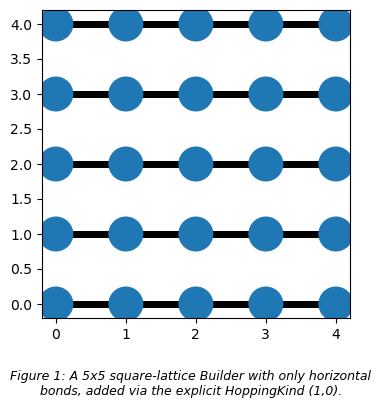

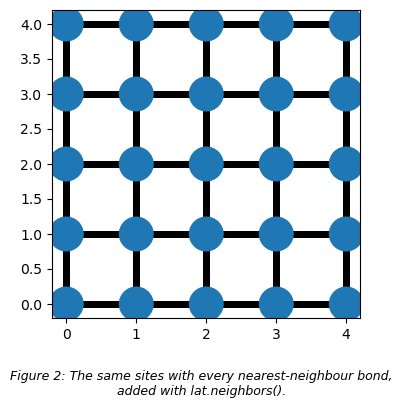

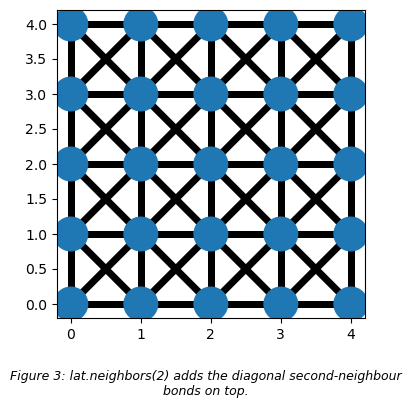

In [4]:
# --- HoppingKind vs lat.neighbors() -----------------------------------------
import kwant
from matplotlib import pyplot

lat = kwant.lattice.square(norbs=1)

syst = kwant.Builder()
syst[(lat(i, j) for i in range(5) for j in range(5))] = 4

# (a) only horizontal bonds, via an explicit HoppingKind pattern
syst[kwant.builder.HoppingKind((1, 0), lat)] = -1
kwant.plot(syst, fig_size=(4, 4), show=False)
show_fig(r'A 5x5 square-lattice Builder with only horizontal bonds, added via the explicit HoppingKind (1,0).')

# (b) wipe them and use all nearest neighbours instead
del syst[kwant.builder.HoppingKind((1, 0), lat)]
syst[lat.neighbors()] = -1          # == lat.neighbors(1)
kwant.plot(syst, fig_size=(4, 4), show=False)
show_fig(r'The same sites with every nearest-neighbour bond, added with lat.neighbors().')

# (c) second-nearest neighbours too
syst[lat.neighbors(2)] = -0.2
kwant.plot(syst, fig_size=(4, 4), show=False)
show_fig(r'lat.neighbors(2) adds the diagonal second-neighbour bonds on top.')

---
## 3. First transport calculation — a quantum wire

We build the discretised wire of § 1: a rectangle of $L\times W$ sites, with two
semi-infinite leads attached left and right.

A **lead** is a `Builder` carrying a `TranslationalSymmetry`. You supply *one unit cell*
plus the hoppings to the next cell; the symmetry generates the rest to infinity.

> **Direction matters.** The symmetry vector must point **away from the scattering region,
> into the lead**. `(-a, 0)` therefore gives the *left* lead. `lead.reversed()` returns a
> copy pointing the other way — that is the idiomatic way to make the right lead.
>
> **Position does not matter.** You do *not* need to offset the right lead by `L` sites;
> `attach_lead` works out where the interface is.

Leads are numbered from 0 in attachment order, and those numbers are what
`transmission(to, from)` refers to.

**Why steps, physically.**  Each transverse subband is an independent 1D
channel; a clean channel has transmission exactly 1, and the group-velocity
and density-of-states factors cancel in 1D — that cancellation is the whole
magic of the Landauer formula, $G = (e^2/h)\sum_n T_n$.  In experiments the
staircase appears in quantum point contacts, where a smooth (adiabatic)
constriction connects the channels to the reservoirs without mixing them.
*Experiments:* van Wees *et al.*, PRL **60**, 848 (1988); Wharam *et al.*,
J. Phys. C **21**, L209 (1988).  A famous anomaly not captured by this
single-particle picture: the interaction-driven "0.7 structure"
[Thomas *et al.*, PRL **77**, 135 (1996)].


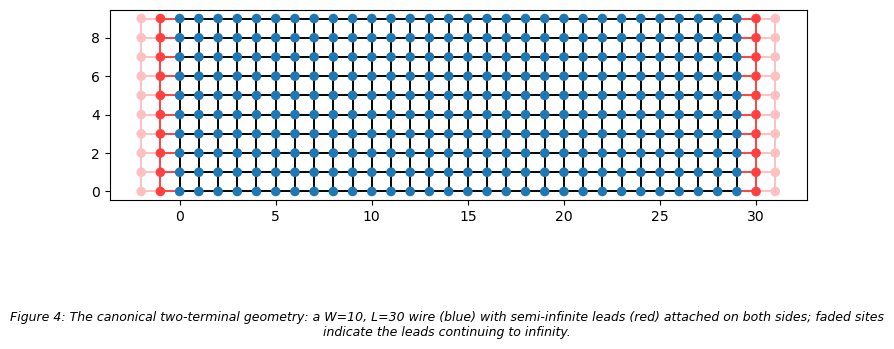

sites in scattering region: 300
leads: 2


In [5]:
# --- The canonical Kwant example: conductance of a quantum wire ---------------
import kwant
import numpy as np
from matplotlib import pyplot

a, t, W, L = 1, 1.0, 10, 30
lat = kwant.lattice.square(a, norbs=1)

def make_wire(W=10, L=30, t=1.0):
    syst = kwant.Builder()

    # Scattering region: on-site 4t, nearest-neighbour hopping -t
    syst[(lat(x, y) for x in range(L) for y in range(W))] = 4 * t
    syst[lat.neighbors()] = -t

    # A lead: one unit cell + translational symmetry pointing left, away from syst
    lead = kwant.Builder(kwant.TranslationalSymmetry((-a, 0)))
    lead[(lat(0, j) for j in range(W))] = 4 * t
    lead[lat.neighbors()] = -t

    syst.attach_lead(lead)               # becomes lead 0 (left)
    syst.attach_lead(lead.reversed())    # becomes lead 1 (right)
    return syst

syst = make_wire()
kwant.plot(syst, fig_size=(9, 4), show=False)
show_fig(r'The canonical two-terminal geometry: a W=10, L=30 wire (blue) with semi-infinite leads (red) attached on both sides; faded sites indicate the leads continuing to infinity.')

fsyst = syst.finalized()
print("sites in scattering region:", len(fsyst.sites))
print("leads:", len(fsyst.leads))

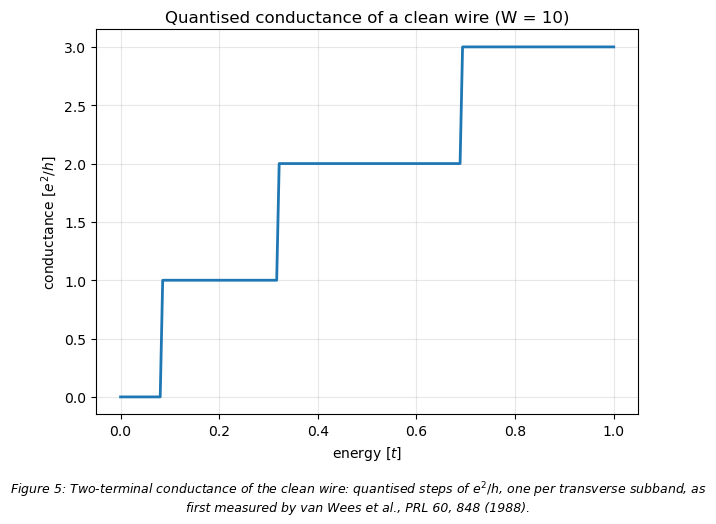

In [6]:
# --- Conductance vs energy: the quantisation staircase -----------------------
energies = np.linspace(0.0, 1.0, 200)

data = []
for energy in energies:
    smatrix = kwant.smatrix(fsyst, energy)
    data.append(smatrix.transmission(1, 0))     # from lead 0 into lead 1

pyplot.figure()
pyplot.plot(energies, data, lw=2)
pyplot.xlabel("energy $[t]$")
pyplot.ylabel(r"conductance $[e^2/h]$")
pyplot.title("Quantised conductance of a clean wire (W = 10)")
pyplot.grid(alpha=.3)
show_fig(r'Two-terminal conductance of the clean wire: quantised steps of $e^2/h$, one per transverse subband, as first measured by van Wees et al., PRL 60, 848 (1988).')

### What you should see

A **staircase**: $G$ rises in integer steps of $e^2/h$. Each step is one transverse subband
(one propagating mode) opening up as the energy is raised. For a hard-wall wire of width
$W$ the transverse modes are $\sin(n\pi y / W)$ with energies

$$E_n = 4t - 2t\cos\!\left(\frac{n\pi}{W+1}\right) - 2t\cos(k_x a),$$

so the $n$-th step occurs when the bottom of subband $n$ crosses $E$. In a *clean* wire
every open mode transmits perfectly, $T = N_{\text{open}}$ — the steps are flat and integer.
Add disorder (try it!) and they degrade.

This single plot is the "hello world" of mesoscopic physics: it is the Landauer result,
and its experimental observation in quantum point contacts is what the theory was built to
explain.

---
## 4. Theory — Scattering theory: Landauer–Büttiker and Fisher–Lee

### The Landauer picture

A mesoscopic conductor is not described by a local conductivity. It is a **scatterer**
connected to reservoirs by ballistic leads. Electrons enter from a lead in one of its
propagating modes, scatter, and leave into some mode of some lead. All transport
information is in the **scattering matrix** $S$, which relates outgoing to incoming mode
amplitudes:

$$\begin{pmatrix}b_1\\ b_2\\ \vdots\end{pmatrix}
= S \begin{pmatrix}a_1\\ a_2\\ \vdots\end{pmatrix},
\qquad
S = \begin{pmatrix} r & t' \\ t & r' \end{pmatrix}.$$

$S$ is **unitary** ($S^\dagger S = 1$) — that is current conservation, and it is the single
most useful numerical check you have.

The **Landauer formula** for a two-terminal conductor at zero temperature:

$$G = \frac{e^2}{h}\,T, \qquad T = \operatorname{Tr}\big(t^\dagger t\big) = \sum_{mn}|t_{nm}|^2.$$

(The spin degeneracy factor of 2 is *not* included — if your model is spinless and you want
to compare to experiment, put it in by hand.)

The **Büttiker generalisation** to many terminals, which is what Kwant actually implements:

$$I_i = \frac{e^2}{h}\sum_{j} \left(T_{ij}V_j - T_{ji}V_i\right),
\qquad T_{ij} = \operatorname{Tr}\big(t_{ij}^\dagger t_{ij}\big).$$

Büttiker's insight: **a voltage probe is just another lead**, and treating it as such
automatically produces the right multi-terminal relations. Sum rules
$\sum_j T_{ij} = \sum_j T_{ji} = N_i$ follow from unitarity.

### Fisher–Lee: from Green's functions to $S$

Kwant does not compute $S$ from a wave-function ansatz alone; it uses the relation between
the scattering matrix and the retarded Green's function of the system,

$$S_{ij} = -\delta_{ij} + i\,\Gamma_i^{1/2}\,G^{r}\,\Gamma_j^{1/2},
\qquad G^{r} = \left(E - H - \sum_i \Sigma_i\right)^{-1},$$

where the **self-energy** $\Sigma_i$ encodes the semi-infinite lead $i$ exactly, and
$\Gamma_i = i(\Sigma_i - \Sigma_i^\dagger)$ is the corresponding level-broadening.
This is the Fisher–Lee relation.

The crucial practical point: **the infinite leads are eliminated exactly**, not truncated.
$\Sigma_i$ is obtained from the lead's mode structure — a self-consistent surface Green's
function / generalised eigenvalue problem over one unit cell. So the numerical problem is
finite (the scattering region) even though the physical system is infinite.

### What Kwant actually solves

Rather than inverting for $G^r$ (dense, expensive), Kwant sets up a **sparse linear system**
whose solution is the scattering wave function, and solves it with a sparse LU
factorisation (MUMPS when available). This is the "wave-function method" and it is why
Kwant scales to large systems.

Two entry points, and the difference matters:

| Function | Returns | Use when |
|---|---|---|
| `kwant.smatrix(fsyst, E, params=...)` | `SMatrix` — transmission, reflection, blocks | you want conductance / $S$ |
| `kwant.wave_function(fsyst, E, params=...)` | callable → array of scattering states | you want densities, currents, maps |

Also available: `kwant.greens_function` (the full $G^r$ between leads) and
`kwant.ldos` (local density of states).

*Further reading:* R. Landauer, IBM J. Res. Dev. **1**, 223 (1957);
M. Büttiker, PRL **57**, 1761 (1986); S. Datta, *Electronic Transport in
Mesoscopic Systems* (Cambridge, 1995); C. W. J. Beenakker & H. van Houten,
Solid State Physics **44**, 1 (1991).  The algorithms behind `kwant.smatrix`
are described in the Kwant paper: C. W. Groth *et al.*, New J. Phys. **16**,
063065 (2014).


In [7]:
# --- Anatomy of the scattering matrix, and unitarity as a sanity check --------
smatrix = kwant.smatrix(fsyst, energy=0.6)

print("num propagating modes in lead 0:", smatrix.num_propagating(0))
print("num propagating modes in lead 1:", smatrix.num_propagating(1))

t10 = smatrix.submatrix(1, 0)      # transmission block  lead 0 -> lead 1
r00 = smatrix.submatrix(0, 0)      # reflection block    lead 0 -> lead 0
print("\nshape of t_10:", t10.shape)

T = smatrix.transmission(1, 0)
R = smatrix.transmission(0, 0)
N = smatrix.num_propagating(0)
print("\nT      = %.10f" % T)
print("R      = %.10f" % R)
print("T + R  = %.10f   (should equal N = %d)" % (T + R, N))

# Unitarity of the full S matrix -- the strongest correctness check available
S = smatrix.data
err = np.max(np.abs(S.conj().T @ S - np.eye(S.shape[0])))
print("\nmax |S^dag S - 1| = %.2e" % err)

num propagating modes in lead 0: 2
num propagating modes in lead 1: 2

shape of t_10: (2, 2)

T      = 2.0000000000
R      = 0.0000000000
T + R  = 2.0000000000   (should equal N = 2)

max |S^dag S - 1| = 2.48e-14


states incoming from lead 0: (2, 300)


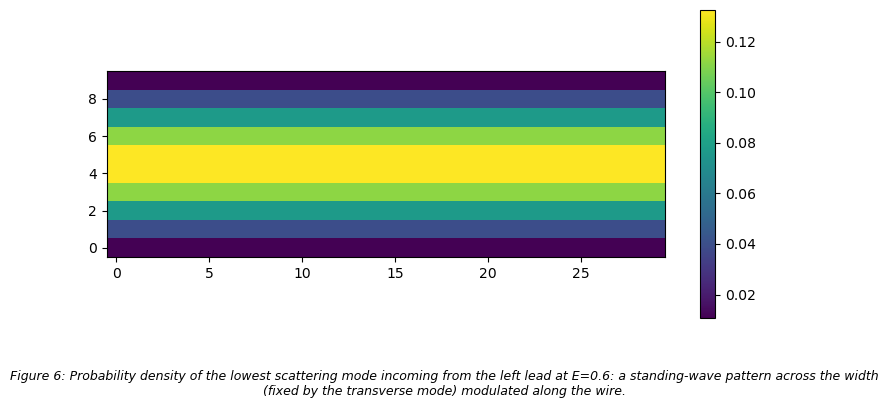

In [8]:
# --- Scattering wave functions, and where they live --------------------------
wf = kwant.wave_function(fsyst, energy=0.6)

psi_from_left = wf(0)            # shape: (n_modes, n_orbitals_in_scattering_region)
print("states incoming from lead 0:", psi_from_left.shape)

# Probability density of the lowest incoming mode, mapped onto the lattice
kwant.plotter.map(fsyst, np.abs(psi_from_left[0])**2,
                  fig_size=(9, 4), cmap='viridis', show=False)
show_fig(r'Probability density of the lowest scattering mode incoming from the left lead at E=0.6: a standing-wave pattern across the width (fixed by the transverse mode) modulated along the wire.')

---
## 5. Shapes, spatially varying values, and runtime parameters

Two features turn the toy wire into real physics.

**Shape functions.** `lat.shape(fn, start)` fills a region by flood-fill: `fn(pos)` returns
`True` inside, and `start` is a seed point known to be inside. This is how you make discs,
stadiums, rings, constrictions — anything.

```python
def circle(pos):
    x, y = pos
    return x**2 + y**2 < r**2

syst[lat.shape(circle, (0, 0))] = 4 * t
```

**Values as functions.** Instead of a number, assign a callable:

```python
def onsite(site, pot):          # first arg: the site;   rest: user parameters
    x, y = site.pos
    return 4 * t + pot * (x > 0)

def hopping(site_a, site_b, B): # first two args: the two sites
    ...
```

Kwant calls these at solve time with the values you pass in `params`:

```python
kwant.smatrix(fsyst, energy, params=dict(pot=-0.3, B=0.01))
```

This is the right way to sweep a parameter: **build the system once**, then re-solve. Never
rebuild inside a loop — construction is the slow part.

> **Signature rule.** On-site functions take `(site, *args)`; hopping functions take
> `(to_site, from_site, *args)`. The parameter *names* are what `params` keys must match.

**Resonances are poles.**  A quasi-bound state at energy $E_0$ with escape
rate $\Gamma/\hbar$ shows up in transmission as a Breit-Wigner peak,
$T(E)\approx \Gamma^2/[(E-E_0)^2+\Gamma^2]$ — transport spectroscopy of the
closed system's levels.  Stadium-shaped dots like the one above are the
workhorse of *quantum chaos*: their classical dynamics is ergodic, their
spectra follow random-matrix statistics, and some eigenstates cling to
unstable periodic orbits ("scars"; see the new figure below).  *Further
reading:* Beenakker, RMP **69**, 731 (1997) (random-matrix transport);
Heller, PRL **53**, 1515 (1984) (scars).


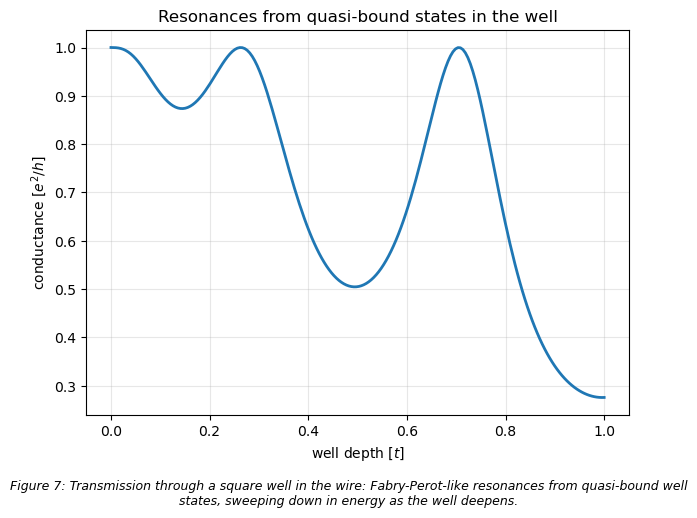

In [9]:
# --- A quantum well in a wire, swept over well depth -------------------------
import kwant, numpy as np
from matplotlib import pyplot

a, t, W, L = 1, 1.0, 10, 30
L_well = 10
lat = kwant.lattice.square(a, norbs=1)

def onsite(site, pot):
    (x, y) = site.pos
    # the well occupies the middle third of the wire
    inside = (L - L_well) // 2 <= x < (L + L_well) // 2
    return 4 * t + (pot if inside else 0)

syst = kwant.Builder()
syst[(lat(x, y) for x in range(L) for y in range(W))] = onsite
syst[lat.neighbors()] = -t

lead = kwant.Builder(kwant.TranslationalSymmetry((-a, 0)))
lead[(lat(0, j) for j in range(W))] = 4 * t
lead[lat.neighbors()] = -t
syst.attach_lead(lead)
syst.attach_lead(lead.reversed())

fsyst_well = syst.finalized()

welldepths = np.linspace(0, 1.0, 200)
data = [kwant.smatrix(fsyst_well, 0.2, params=dict(pot=-wd)).transmission(1, 0)
        for wd in welldepths]

pyplot.plot(welldepths, data, lw=2)
pyplot.xlabel("well depth $[t]$")
pyplot.ylabel(r"conductance $[e^2/h]$")
pyplot.title("Resonances from quasi-bound states in the well")
pyplot.grid(alpha=.3); show_fig(r'Transmission through a square well in the wire: Fabry-Perot-like resonances from quasi-bound well states, sweeping down in energy as the well deepens.')

sites: 1857


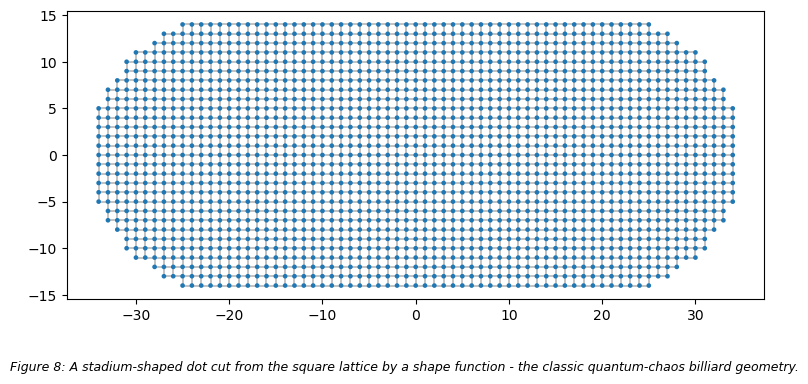

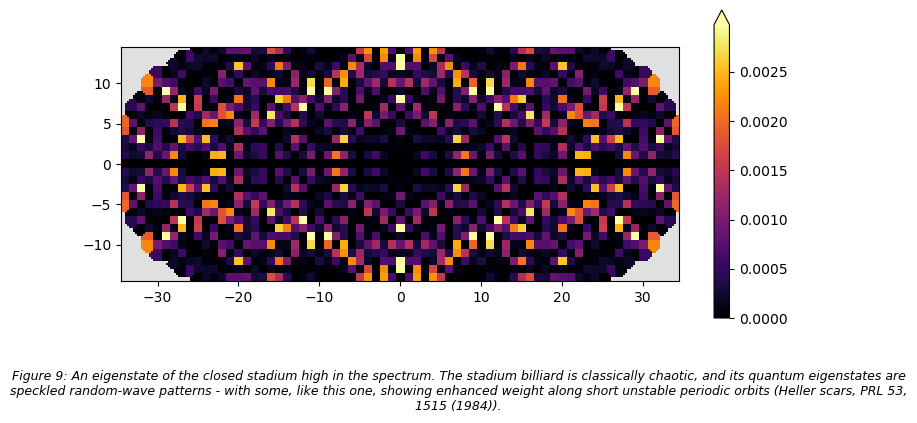

In [10]:
# --- Shape functions: a stadium-shaped quantum dot ---------------------------
import kwant
lat = kwant.lattice.square(norbs=1)

def stadium(pos):
    x, y = pos
    x = max(abs(x) - 20, 0)          # two half-discs joined by a straight section
    return x**2 + y**2 < 15**2

dot = kwant.Builder()
dot[lat.shape(stadium, (0, 0))] = 4.0
dot[lat.neighbors()] = -1.0

print("sites:", len(list(dot.sites())))
kwant.plot(dot, fig_size=(9, 4), site_size=0.25, hop_lw=0.05, show=False)
show_fig(r'A stadium-shaped dot cut from the square lattice by a shape function - the classic quantum-chaos billiard geometry.')

# an eigenstate of the closed stadium, high in the spectrum: quantum chaos
import numpy as np
import scipy.sparse.linalg as sla

fdot = dot.finalized()
ham = fdot.hamiltonian_submatrix(sparse=True)
ev_s, vec_s = sla.eigsh(ham.tocsc(), k=1, sigma=2.4)
kwant.plotter.map(fdot, np.abs(vec_s[:, 0]) ** 2, oversampling=4,
                  cmap='inferno', fig_size=(9, 4), show=False)
show_fig(r'An eigenstate of the closed stadium high in the spectrum. The stadium billiard is classically chaotic, and its quantum eigenstates are speckled random-wave patterns - with some, like this one, showing enhanced weight along short unstable periodic orbits (Heller scars, PRL 53, 1515 (1984)).')

---
## 6. Spin — matrix-valued on-site and hopping terms

To give each site internal structure (spin, orbitals, electron/hole), assign **matrices**
instead of numbers and declare `norbs` accordingly.

### The physics: Rashba spin–orbit coupling + Zeeman

$$H = \frac{p^2}{2m} + \frac{\alpha}{\hbar}\left(\sigma_x p_y - \sigma_y p_x\right)
+ \frac{E_Z}{2}\,\sigma_z$$

Discretising: the Rashba term is *first order* in momentum, so it becomes an **imaginary,
spin-flipping hopping**; the Zeeman term is diagonal and on-site.

$$H_{\text{onsite}} = (4t + E_Z\sigma_z),\qquad
H_{x\text{-hop}} = -t\sigma_0 + \frac{i\alpha}{2}\sigma_y,\qquad
H_{y\text{-hop}} = -t\sigma_0 - \frac{i\alpha}{2}\sigma_x .$$

Note the pattern: $\partial_x \to$ hopping along $x$ times $i$, and the Pauli matrix
attached is the *other* one, with a sign set by the cross product in the Rashba term.

Together, Rashba + Zeeman opens a **helical gap** at $k=0$: the two spin-split parabolas
anticross, leaving a window where only one pair of counter-propagating, spin-locked modes
exists. This is the ingredient that, combined with superconductivity, produces Majorana
bound states (§ 9).

> Use `tinyarray` for these small fixed matrices — it is dramatically faster than NumPy for
> 2×2 and 4×4 objects, which Kwant manipulates millions of times.

**Where Rashba coupling comes from.**  In a 2D electron gas the confining
potential breaks inversion along $\hat z$; relativistic corrections then read
$H_R = \alpha(\sigma_x k_y - \sigma_y k_x)$, with $\alpha$ tunable by a gate
— the basis of the Datta-Das spin-transistor proposal [APL **56**, 665
(1990)].  Combined with a Zeeman field it opens the *helical gap* probed
above: inside it, spin and direction of motion are locked, a 1D cousin of
the topological-insulator edge and the starting point of the Majorana wire
of §19.  *Further reading:* Winkler, *Spin-Orbit Coupling Effects in 2D
Electron and Hole Systems* (Springer, 2003); Manchon *et al.*, Nat. Mater.
**14**, 871 (2015).


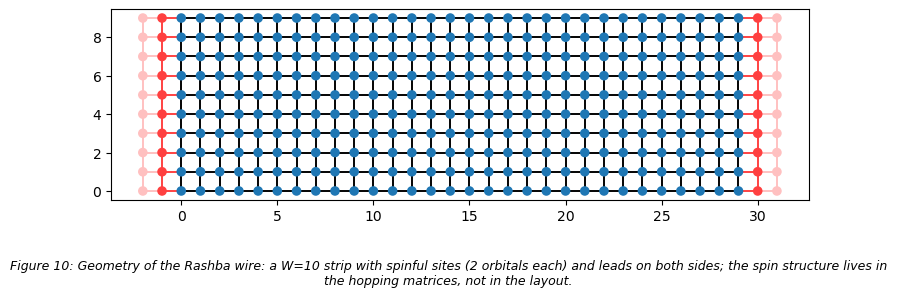

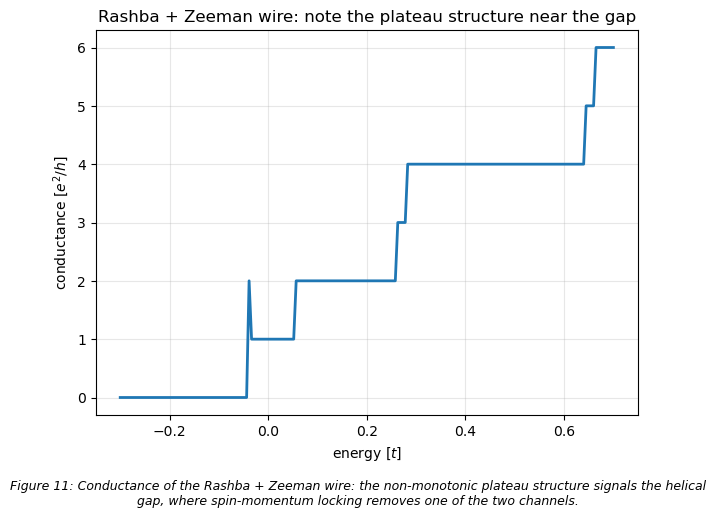

In [11]:
# --- Rashba wire: helical gap -------------------------------------------------
import kwant, numpy as np, tinyarray as ta
from matplotlib import pyplot

sigma_0 = ta.array([[1, 0], [0, 1]])
sigma_x = ta.array([[0, 1], [1, 0]])
sigma_y = ta.array([[0, -1j], [1j, 0]])
sigma_z = ta.array([[1, 0], [0, -1]])

t, alpha, e_z = 1.0, 0.5, 0.08
W, L = 10, 30
lat = kwant.lattice.square(norbs=2)          # 2 orbitals = spin up/down

def make_rashba(W=10, L=30):
    syst = kwant.Builder()
    syst[(lat(x, y) for x in range(L) for y in range(W))] = \
        4 * t * sigma_0 + e_z * sigma_z
    syst[kwant.builder.HoppingKind((1, 0), lat, lat)] = \
        -t * sigma_0 + 1j * alpha * sigma_y / 2
    syst[kwant.builder.HoppingKind((0, 1), lat, lat)] = \
        -t * sigma_0 - 1j * alpha * sigma_x / 2

    lead = kwant.Builder(kwant.TranslationalSymmetry((-1, 0)))
    lead[(lat(0, j) for j in range(W))] = 4 * t * sigma_0 + e_z * sigma_z
    lead[kwant.builder.HoppingKind((1, 0), lat, lat)] = \
        -t * sigma_0 + 1j * alpha * sigma_y / 2
    lead[kwant.builder.HoppingKind((0, 1), lat, lat)] = \
        -t * sigma_0 - 1j * alpha * sigma_x / 2

    syst.attach_lead(lead)
    syst.attach_lead(lead.reversed())
    return syst

kwant.plot(make_rashba(), fig_size=(9, 3), show=False)
show_fig(r'Geometry of the Rashba wire: a W=10 strip with spinful sites (2 orbitals each) and leads on both sides; the spin structure lives in the hopping matrices, not in the layout.')

fsyst_r = make_rashba().finalized()

energies = np.linspace(-0.3, 0.7, 200)
data = [kwant.smatrix(fsyst_r, e).transmission(1, 0) for e in energies]

pyplot.plot(energies, data, lw=2)
pyplot.xlabel("energy $[t]$"); pyplot.ylabel(r"conductance $[e^2/h]$")
pyplot.title("Rashba + Zeeman wire: note the plateau structure near the gap")
pyplot.grid(alpha=.3); show_fig(r'Conductance of the Rashba + Zeeman wire: the non-monotonic plateau structure signals the helical gap, where spin-momentum locking removes one of the two channels.')

---
## 7. Band structure and closed systems

Not every calculation is a transport calculation. Kwant gives you the Hamiltonian itself.

### Lead band structure

A lead is periodic, so Bloch's theorem applies: $H(k) = H_{\text{cell}} + H_{\text{hop}}e^{ik} + H_{\text{hop}}^\dagger e^{-ik}$,
and diagonalising $H(k)$ gives the subbands. This is exactly what tells you **how many
modes are open** at a given energy — the step positions in § 3.

```python
bands = kwant.physics.Bands(flead)     # flead = lead.finalized()
energies = [bands(k) for k in momenta]
kwant.plotter.bands(flead)             # convenience wrapper
```

### Closed systems

Drop the leads and you have a finite Hermitian matrix. `hamiltonian_submatrix` hands it to
you and you use SciPy:

```python
ham = fsyst.hamiltonian_submatrix(params=..., sparse=True)
evals = scipy.sparse.linalg.eigsh(ham.tocsc(), k=15, sigma=0, return_eigenvectors=False)
```

> Use `sigma=0` with `eigsh` for **shift-invert** around zero energy. Asking for `which='SM'`
> without shift-invert converges painfully slowly. This is the single most common
> performance mistake in closed-system Kwant code.

### The Fock–Darwin spectrum

A 2D parabolic dot in a perpendicular field $B$ has levels
$$E_{n,\ell} = (2n + |\ell| + 1)\hbar\Omega - \tfrac{1}{2}\ell\hbar\omega_c,
\qquad \Omega = \sqrt{\omega_0^2 + \omega_c^2/4}.$$
At small $B$ the degeneracies split linearly (orbital Zeeman); at large $B$ the levels
bunch into **Landau levels**. A hard-wall disc shows the same qualitative flow, which is
what the next cell computes.

**Reading a lead's band structure.**  `kwant.physics.Bands` diagonalises the
lead's translation cell at fixed Bloch momentum — the 1D band structure
$E_n(k)$ whose minima open conductance channels and whose slopes are the
mode velocities that normalise the scattering matrix.  Everything transport
in this notebook is controlled by these curves; when in doubt about a
feature in $G(E)$, plot the bands first.  *Further reading:* Ashcroft &
Mermin ch. 8 for Bloch theory; Datta ch. 3 for modes-as-channels.


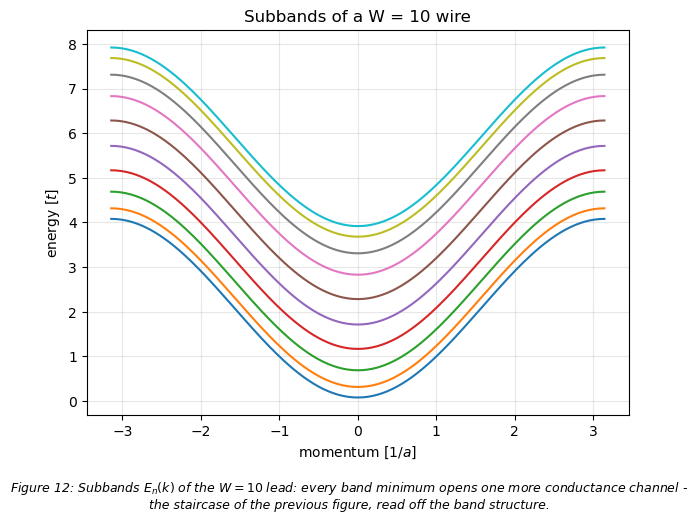

energies at k = 0: [0.081  0.3175 0.6903 1.1692 1.7154 2.2846 2.8308 3.3097 3.6825 3.919 ]


In [12]:
# --- Band structure of a lead ------------------------------------------------
import kwant, numpy as np
from matplotlib import pyplot

lat = kwant.lattice.square(norbs=1)
t, W = 1.0, 10

lead = kwant.Builder(kwant.TranslationalSymmetry((-1, 0)))
lead[(lat(0, j) for j in range(W))] = 4 * t
lead[lat.neighbors()] = -t
flead = lead.finalized()

# convenience plot
kwant.plotter.bands(flead, momenta=np.linspace(-np.pi, np.pi, 201), show=False)
pyplot.xlabel("momentum $[1/a]$"); pyplot.ylabel("energy $[t]$")
pyplot.title("Subbands of a W = 10 wire"); pyplot.grid(alpha=.3); show_fig(r'Subbands $E_n(k)$ of the $W=10$ lead: every band minimum opens one more conductance channel - the staircase of the previous figure, read off the band structure.')

# ... and the underlying object, if you want the numbers
bands = kwant.physics.Bands(flead)
print("energies at k = 0:", np.round(bands(0.0), 4))

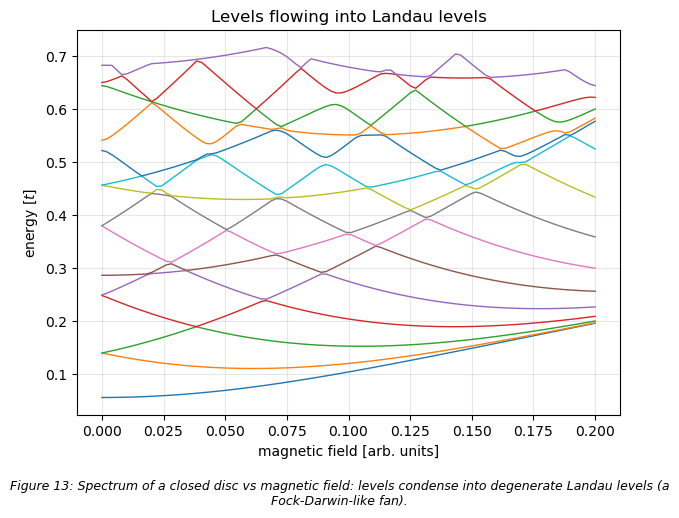

In [13]:
# --- Closed system: spectrum of a disc vs magnetic field (Fock-Darwin-like) ---
import kwant, numpy as np
import scipy.sparse.linalg as sla
from cmath import exp
from matplotlib import pyplot

lat = kwant.lattice.square(norbs=1)
t, r = 1.0, 10

def circle(pos):
    x, y = pos
    return x**2 + y**2 < r**2

def hopx(site1, site2, B):
    # Peierls phase for a uniform field in the Landau gauge A = (-By, 0, 0)
    y = site1.pos[1]
    return -t * exp(-1j * B * y)

dot = kwant.Builder()
dot[lat.shape(circle, (0, 0))] = 4 * t
dot[kwant.builder.HoppingKind((1, 0), lat, lat)] = hopx
dot[kwant.builder.HoppingKind((0, 1), lat, lat)] = -t
fdot = dot.finalized()

Bfields = np.linspace(0, 0.2, 100)
energies = []
for B in Bfields:
    ham = fdot.hamiltonian_submatrix(params=dict(B=B), sparse=True)
    ev = sla.eigsh(ham.tocsc(), k=15, sigma=0, return_eigenvectors=False)
    energies.append(np.sort(ev))

pyplot.plot(Bfields, energies, lw=1)
pyplot.xlabel("magnetic field [arb. units]"); pyplot.ylabel("energy $[t]$")
pyplot.title("Levels flowing into Landau levels"); pyplot.grid(alpha=.3); show_fig(r'Spectrum of a closed disc vs magnetic field: levels condense into degenerate Landau levels (a Fock-Darwin-like fan).')

---
## 8. Beyond square lattices — graphene

Nothing in Kwant assumes a square lattice. `kwant.lattice.general(prim_vecs, basis)` builds
any Bravais lattice with any basis; the result is a `Polyatomic` lattice whose
`.sublattices` are ordinary site families.

### Graphene

Primitive vectors $\mathbf{a}_1 = (1,0)$, $\mathbf{a}_2 = (\tfrac12, \tfrac{\sqrt3}{2})$,
with a two-atom basis at $(0,0)$ and $(0, 1/\sqrt3)$ — the A and B sublattices. Only A–B
bonds exist at nearest-neighbour level, which is what makes graphene bipartite and gives it
a **chiral (sublattice) symmetry**.

The nearest-neighbour tight-binding Hamiltonian yields
$$E(\mathbf{k}) = \pm t\left|1 + e^{i\mathbf{k}\cdot\mathbf{a}_1} + e^{i\mathbf{k}\cdot\mathbf{a}_2}\right|,$$
which vanishes at the two inequivalent corners $K$, $K'$ of the Brillouin zone. Expanding
around them gives the massless **Dirac cone** $E = \pm\hbar v_F |q|$, $v_F = 3ta/2\hbar$.

The three A→B bonds are, as `HoppingKind` patterns,
`((0,0), a, b)`, `((0,1), a, b)`, `((-1,1), a, b)`.

> `syst.eradicate_dangling()` removes sites with fewer than two neighbours. On a honeycomb
> lattice cut to a shape this is essential — dangling atoms create spurious zero-energy
> states that swamp the spectrum.

Kwant also ships `kwant.lattice.honeycomb()`, `.kagome()`, `.triangular()`, `.cubic()`,
`.chain()`.

**Dirac physics in one line.**  Two sites per cell make the Bloch
Hamiltonian a $2\times2$ matrix $h(\mathbf k) = d(\mathbf k)\cdot\sigma$;
at the two BZ corners $d$ vanishes linearly, giving massless Dirac cones
with pseudospin (sublattice) locked to momentum.  Backscattering within one
valley requires flipping the pseudospin — the root of Klein tunnelling
through the p-n junction above [Katsnelson, Novoselov & Geim, Nat. Phys.
**2**, 620 (2006)].  Zigzag edges bind the famous flat-band edge states;
armchair edges do not — compare with the ribbon bands plotted here.
*Further reading:* Castro Neto *et al.*, RMP **81**, 109 (2009); Beenakker,
RMP **80**, 1337 (2008) (graphene Andreev physics).


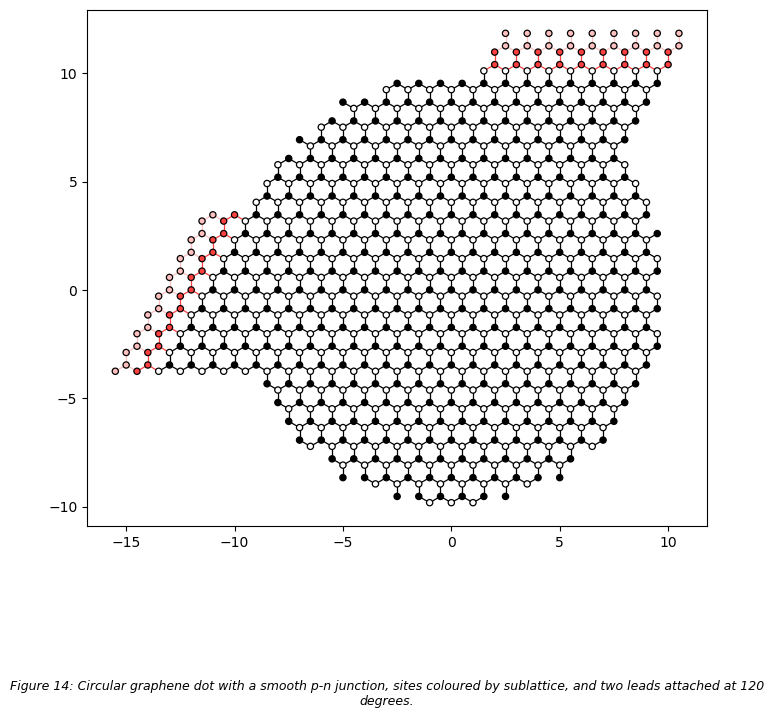

In [14]:
# --- Graphene quantum dot with a p-n junction and two leads ------------------
import kwant, numpy as np
from math import pi, sqrt, tanh
from matplotlib import pyplot

sin_30, cos_30 = 1/2, sqrt(3)/2

graphene = kwant.lattice.general([(1, 0), (sin_30, cos_30)],
                                 [(0, 0), (0, 1/sqrt(3))],
                                 norbs=1)
a_sub, b_sub = graphene.sublattices

r, w, pot = 10, 2.0, 0.1

def circle(pos):
    x, y = pos
    return x**2 + y**2 < r**2

def potential(site):
    x, y = site.pos
    d = y * cos_30 + x * sin_30
    return pot * tanh(d / w)          # smooth p-n junction across the dot

syst = kwant.Builder()
syst[graphene.shape(circle, (0, 0))] = potential

hoppings = (((0, 0), a_sub, b_sub),
            ((0, 1), a_sub, b_sub),
            ((-1, 1), a_sub, b_sub))
syst[[kwant.builder.HoppingKind(*h) for h in hoppings]] = -1

# two leads: one to the left, one to the top right
sym0 = kwant.TranslationalSymmetry(graphene.vec((-1, 0)))
def lead0_shape(pos):
    x, y = pos
    return -0.4 * r < y < 0.4 * r
lead0 = kwant.Builder(sym0)
lead0[graphene.shape(lead0_shape, (0, 0))] = -pot
lead0[[kwant.builder.HoppingKind(*h) for h in hoppings]] = -1

sym1 = kwant.TranslationalSymmetry(graphene.vec((0, 1)))
def lead1_shape(pos):
    v = pos[1] * sin_30 - pos[0] * cos_30
    return -0.4 * r < v < 0.4 * r
lead1 = kwant.Builder(sym1)
lead1[graphene.shape(lead1_shape, (0, 0))] = pot
lead1[[kwant.builder.HoppingKind(*h) for h in hoppings]] = -1

syst.attach_lead(lead0)
syst.attach_lead(lead1)

def family_colors(site):
    return 0 if site.family == a_sub else 1

kwant.plot(syst, site_color=family_colors, site_lw=0.1,
           colorbar=False, fig_size=(8, 8), show=False)
show_fig(r'Circular graphene dot with a smooth p-n junction, sites coloured by sublattice, and two leads attached at 120 degrees.')

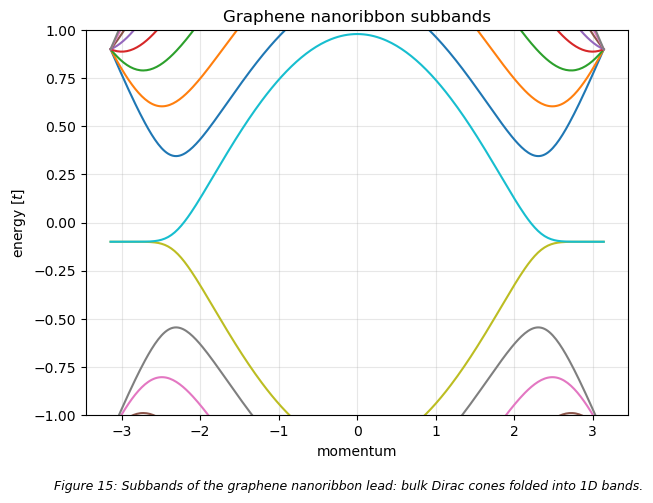

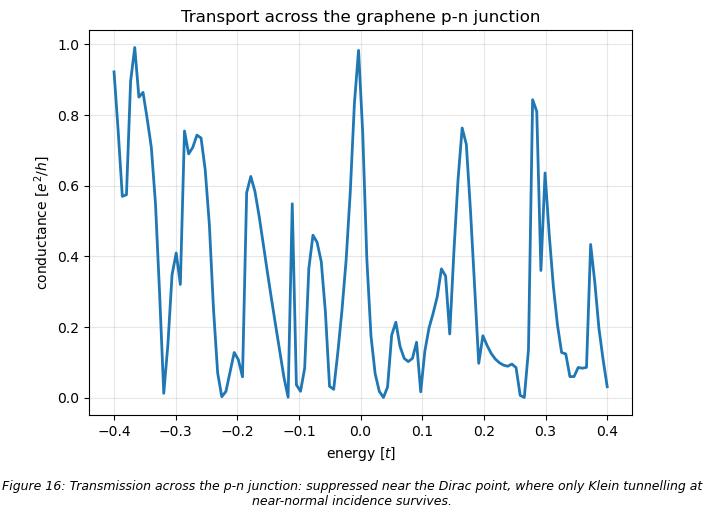

In [15]:
# --- Dirac cone in the lead band structure -----------------------------------
fgr = syst.finalized()

kwant.plotter.bands(fgr.leads[0], momenta=np.linspace(-pi, pi, 301), show=False)
pyplot.xlabel("momentum"); pyplot.ylabel("energy $[t]$")
pyplot.ylim(-1, 1); pyplot.title("Graphene nanoribbon subbands")
pyplot.grid(alpha=.3); show_fig(r'Subbands of the graphene nanoribbon lead: bulk Dirac cones folded into 1D bands.')

energies = np.linspace(-0.4, 0.4, 120)
G = [kwant.smatrix(fgr, e).transmission(0, 1) for e in energies]
pyplot.plot(energies, G, lw=2)
pyplot.xlabel("energy $[t]$"); pyplot.ylabel(r"conductance $[e^2/h]$")
pyplot.title("Transport across the graphene p-n junction")
pyplot.grid(alpha=.3); show_fig(r'Transmission across the p-n junction: suppressed near the Dirac point, where only Klein tunnelling at near-normal incidence survives.')

---
## 9. Superconductivity — BdG, Andreev reflection, and discrete symmetries

### The Bogoliubov–de Gennes construction

Superconductivity is not a single-particle problem, but mean-field BCS theory can be written
as one by **doubling the Hilbert space** into electron and hole components. In the
Nambu basis $\Psi = (\psi_\uparrow, \psi_\downarrow^\dagger)^T$,

$$H_{\text{BdG}} = \begin{pmatrix} H_0 - \mu & \Delta \\ \Delta^* & -(H_0 - \mu)^* \end{pmatrix}
= (H_0-\mu)\,\tau_z + \Delta\,\tau_x,$$

where $\tau_i$ are Pauli matrices **in electron–hole (Nambu) space**. So:

- `norbs=2` again — but now the two "orbitals" are electron and hole, not spin.
- On-site: $(4t - \mu)\tau_z + \Delta\tau_x$. Hopping: $-t\,\tau_z$ (holes hop with opposite sign).

The price of doubling is a **redundancy**: every eigenstate at $E$ has a partner at $-E$.
That is **particle–hole symmetry**, $\mathcal{P} H \mathcal{P}^{-1} = -H$ with
$\mathcal{P} = \tau_y \mathcal{K}$ in this basis. It is a *constraint*, not a symmetry that
labels states.

### Andreev reflection and the BTK conductance

At an N–S interface, an electron below the gap cannot enter the superconductor as a
quasiparticle. Instead it is retro-reflected as a **hole**, injecting a Cooper pair — this
is **Andreev reflection**. Because it converts an incoming electron into an outgoing hole,
it carries charge $2e$, and the conductance formula changes:

$$G = \frac{e^2}{h}\left(N - R_{ee} + R_{he}\right)$$

with $N$ the number of modes, $R_{ee}$ normal reflection and $R_{he}$ Andreev reflection.
For a **transparent** interface, $R_{he} \to N$ and $R_{ee}\to 0$ below the gap, so
$G \to 2Ne^2/h$ — **doubled** conductance. For a **tunnel barrier**, Andreev reflection is
suppressed as the square of the transparency, so $G \to 0$ below the gap and the curve maps
out the density of states. This crossover is the Blonder–Tinkham–Klapwijk result.

### Telling Kwant about the structure

```python
lead = kwant.Builder(sym, conservation_law=-tau_z, particle_hole=tau_y)
```

- `conservation_law=-tau_z` — electron and hole blocks do not mix *in the normal lead*
  (where $\Delta=0$). Kwant then **labels modes by block**, so you can ask for
  `transmission((0, 1), (0, 0))`: "from lead 0 block 0 to lead 0 block 1", i.e. exactly
  $R_{he}$. Blocks are ordered by ascending eigenvalue of the conservation law, so with
  `-tau_z` block 0 = electrons, block 1 = holes.
- `particle_hole=tau_y` — declares the antiunitary PHS, which lets Kwant relate scattering
  states at $\pm E$ and check consistency.

> Only impose `conservation_law` where it actually holds. In the superconducting lead
> $\Delta \ne 0$ mixes the blocks, so it must not be declared there.

*Further reading:* the barrier-strength crossover computed below is the
classic result of Blonder, Tinkham & Klapwijk, PRB **25**, 4515 (1982); the
scattering (Bogoliubov-de Gennes) formulation of superconducting transport is
reviewed in C. W. J. Beenakker, RMP **69**, 731 (1997), and pedagogically in
Nazarov & Blanter, *Quantum Transport* (Cambridge, 2009).


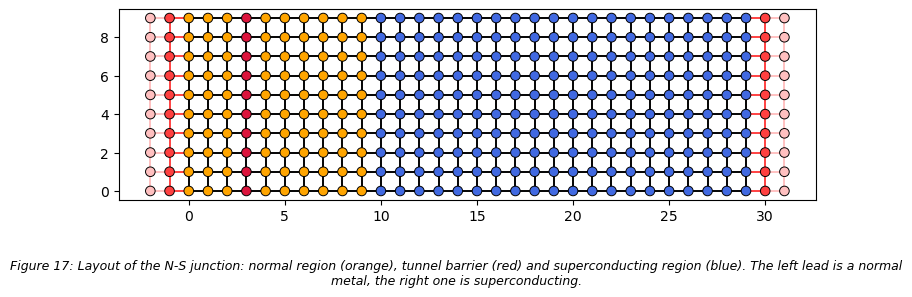

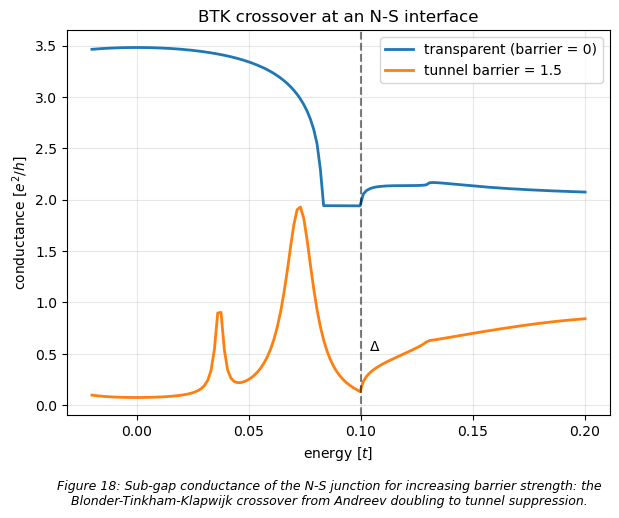

In [16]:
# --- N-S junction: Andreev reflection and the BTK crossover ------------------
import kwant, numpy as np, tinyarray
from matplotlib import pyplot

tau_x = tinyarray.array([[0, 1], [1, 0]])
tau_y = tinyarray.array([[0, -1j], [1j, 0]])
tau_z = tinyarray.array([[1, 0], [0, -1]])

a, t, W, L = 1, 1.0, 10, 30
mu, Delta, Deltapos = 0.4, 0.1, 10
lat = kwant.lattice.square(a, norbs=2)      # 2 orbitals = electron, hole

def make_ns(barrier=1.5, barrierpos=(3, 4)):
    syst = kwant.Builder()

    # normal part
    syst[(lat(x, y) for x in range(Deltapos) for y in range(W))] = \
        (4 * t - mu) * tau_z
    # superconducting part: pairing enters as an on-site tau_x term
    syst[(lat(x, y) for x in range(Deltapos, L) for y in range(W))] = \
        (4 * t - mu) * tau_z + Delta * tau_x
    # tunnel barrier controls the interface transparency
    syst[(lat(x, y) for x in range(*barrierpos) for y in range(W))] = \
        (4 * t + barrier - mu) * tau_z

    syst[lat.neighbors()] = -t * tau_z

    # left lead: NORMAL -> electrons and holes decouple, so declare it
    lead0 = kwant.Builder(kwant.TranslationalSymmetry((-a, 0)),
                          conservation_law=-tau_z, particle_hole=tau_y)
    lead0[(lat(0, j) for j in range(W))] = (4 * t - mu) * tau_z
    lead0[lat.neighbors()] = -t * tau_z

    # right lead: SUPERCONDUCTING -> no conservation law here
    lead1 = kwant.Builder(kwant.TranslationalSymmetry((a, 0)))
    lead1[(lat(0, j) for j in range(W))] = (4 * t - mu) * tau_z + Delta * tau_x
    lead1[lat.neighbors()] = -t * tau_z

    syst.attach_lead(lead0)
    syst.attach_lead(lead1)
    return syst.finalized()

fns_plot = make_ns()
def ns_region_color(i):
    # NB: for a *finalized* system the callable receives the site index
    x = fns_plot.sites[i].pos[0]
    if 3 <= x < 4:
        return 'crimson'                    # tunnel barrier
    return 'orange' if x < Deltapos else 'royalblue'

kwant.plot(fns_plot, site_color=ns_region_color, site_lw=0.05,
           colorbar=False, fig_size=(9, 3), show=False)
show_fig(r'Layout of the N-S junction: normal region (orange), tunnel barrier (red) and superconducting region (blue). The left lead is a normal metal, the right one is superconducting.')

def andreev_conductance(fsyst, energies):
    G = []
    for e in energies:
        s = kwant.smatrix(fsyst, e)
        N    = s.submatrix((0, 0), (0, 0)).shape[0]   # number of electron modes
        R_ee = s.transmission((0, 0), (0, 0))         # normal reflection
        R_he = s.transmission((0, 1), (0, 0))         # ANDREEV reflection
        G.append(N - R_ee + R_he)
    return np.array(G)

energies = np.linspace(-0.02, 0.2, 150)

pyplot.figure()
for barrier, label in [(0.0, "transparent (barrier = 0)"),
                       (1.5, "tunnel barrier = 1.5")]:
    fsyst_ns = make_ns(barrier=barrier)
    pyplot.plot(energies, andreev_conductance(fsyst_ns, energies),
                lw=2, label=label)

pyplot.axvline(Delta, ls='--', c='k', alpha=.5)
pyplot.text(Delta, 0.5, r"  $\Delta$", va='bottom')
pyplot.xlabel("energy $[t]$"); pyplot.ylabel(r"conductance $[e^2/h]$")
pyplot.title("BTK crossover at an N-S interface")
pyplot.legend(); pyplot.grid(alpha=.3); show_fig(r'Sub-gap conductance of the N-S junction for increasing barrier strength: the Blonder-Tinkham-Klapwijk crossover from Andreev doubling to tunnel suppression.')

In [17]:
# --- Verifying particle-hole symmetry of the scattering matrix ---------------
fsyst_ns = make_ns(barrier=0.0)

s = kwant.smatrix(fsyst_ns, energy=0)
s_ee = s.submatrix((0, 0), (0, 0))     # electron -> electron
s_hh = s.submatrix((0, 1), (0, 1))     # hole -> hole

print("s_ee =\n", np.round(s_ee, 4))
print("\ns_hh =\n", np.round(s_hh, 4))
print("\nPHS at E=0 requires  s_ee = conj(s_hh):")
print("max deviation = %.2e" % np.max(np.abs(s_ee - s_hh.conj())))

s_ee =
 [[-0.1639+0.0281j -0.    -0.j    ]
 [ 0.    -0.j     -0.4545-0.1581j]]

s_hh =
 [[-0.4545+0.1581j  0.    -0.j    ]
 [ 0.    -0.j     -0.1639-0.0281j]]

PHS at E=0 requires  s_ee = conj(s_hh):
max deviation = 3.45e-01


---
## 10. Local observables — density and current operators

Transmission is a *global* number. To see **where** things happen you need local
quantities, and `kwant.operator` provides them with the correct lattice definitions.

### Density

For an operator $M$ acting in orbital space, the local density on site $i$ is

$$\rho_i^{M}[\psi] = \psi_i^\dagger M \psi_i .$$

With $M = \mathbb{1}$ this is the probability density; with $M = \sigma_z$ the
$z$-spin density; with $M = \tau_z$ the charge density in Nambu space.

### Current

The current is subtler: on a lattice it lives on **bonds**, not sites, and follows from the
continuity equation $\partial_t \rho + \nabla\!\cdot\! J = 0$. Kwant implements

$$J_{ij}^{M}[\psi] = i\left(\psi_i^\dagger H_{ij} M \psi_j
- \psi_j^\dagger M H_{ij}^\dagger \psi_i\right),$$

the current flowing from site $j$ to site $i$. Choosing $M$ gives charge current
($M=\mathbb{1}$), spin current ($M=\sigma_z$), etc.

> **Spin current caveat.** With spin–orbit coupling, spin is not conserved, so the "spin
> current" defined this way does not satisfy a continuity equation. It is still a
> well-defined observable — just do not over-interpret it.

### Usage

```python
rho   = kwant.operator.Density(fsyst)             # M = identity
rho_z = kwant.operator.Density(fsyst, sigma_z)
J     = kwant.operator.Current(fsyst)
J_z   = kwant.operator.Current(fsyst, sigma_z)

psi = kwant.wave_function(fsyst, energy, params=...)(0)[0]
density = rho(psi)        # one number per site
current = J(psi)          # one number per hopping
```

Operators accept `where=` to restrict evaluation to a region (e.g. a cross-section, to get
a total current through it) and `sum=True` to return the total directly. `M` may also be a
*function* of the site, for position-dependent observables such as a spin texture.

Plot with `kwant.plotter.density(...)` / `kwant.plotter.map(...)` for densities and
`kwant.plotter.current(...)` for currents — the latter does the streamline interpolation
for you.

> `norbs` **must** be set on your lattices for `kwant.operator` to work.

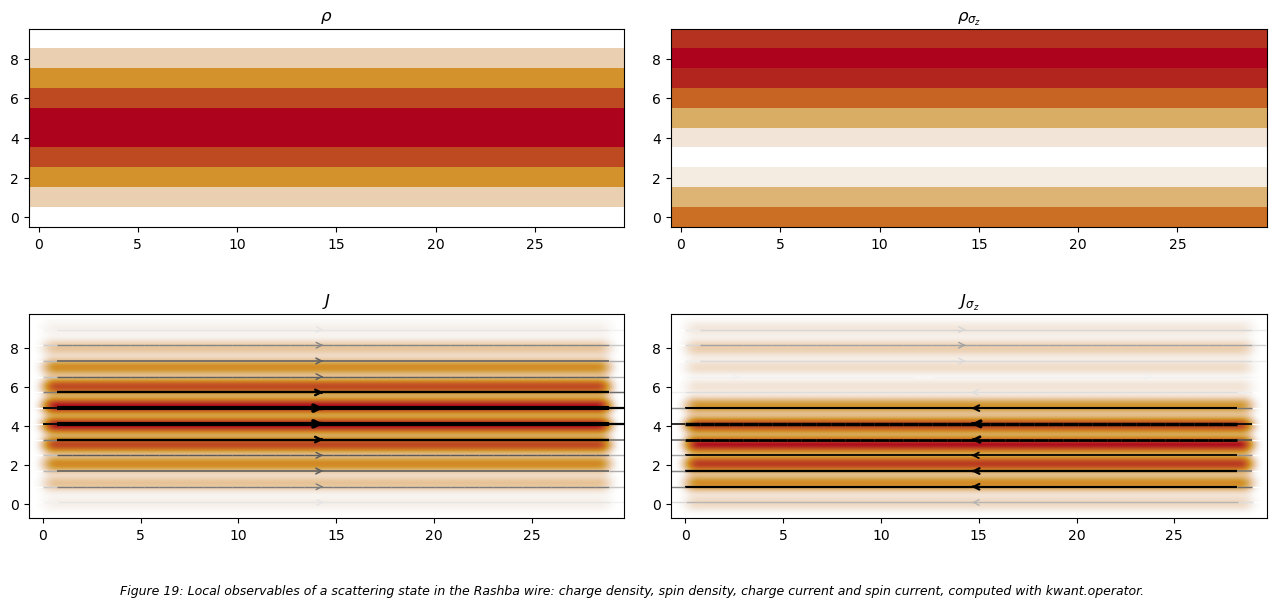

In [18]:
# --- Density and current maps in the Rashba wire -----------------------------
import kwant, numpy as np, tinyarray as ta
from matplotlib import pyplot

sigma_0 = ta.array([[1, 0], [0, 1]])
sigma_y = ta.array([[0, -1j], [1j, 0]])
sigma_z = ta.array([[1, 0], [0, -1]])

# reuse the Rashba system from section 6
psi = kwant.wave_function(fsyst_r, energy=0.4)(0)[0]

rho    = kwant.operator.Density(fsyst_r)
rho_sz = kwant.operator.Density(fsyst_r, sigma_z)
J      = kwant.operator.Current(fsyst_r)
J_sz   = kwant.operator.Current(fsyst_r, sigma_z)

density   = rho(psi)
spin_z    = rho_sz(psi)
current   = J(psi)
spin_curr = J_sz(psi)

fig, axes = pyplot.subplots(2, 2, figsize=(13, 6))
kwant.plotter.map(fsyst_r, density, ax=axes[0, 0]); axes[0, 0].set_title(r"$\rho$")
kwant.plotter.map(fsyst_r, spin_z,  ax=axes[0, 1]); axes[0, 1].set_title(r"$\rho_{\sigma_z}$")
kwant.plotter.current(fsyst_r, current,   ax=axes[1, 0], colorbar=False)
axes[1, 0].set_title(r"$J$")
kwant.plotter.current(fsyst_r, spin_curr, ax=axes[1, 1], colorbar=False)
axes[1, 1].set_title(r"$J_{\sigma_z}$")
pyplot.tight_layout(); show_fig(r'Local observables of a scattering state in the Rashba wire: charge density, spin density, charge current and spin current, computed with kwant.operator.')

In [19]:
# --- Total current through a cross-section, and current conservation ---------
# 'where' restricts the operator to a set of hoppings; 'sum' returns the total.
lat_r = kwant.lattice.square(norbs=2)

def cut(site_to, site_from):
    # hoppings crossing the plane x = 15, pointing in +x
    return site_from.pos[0] == 15 and site_to.pos[0] == 16

J_cut = kwant.operator.Current(fsyst_r, where=cut, sum=True)

wf = kwant.wave_function(fsyst_r, energy=0.4)
total = sum(J_cut(p) for p in wf(0))
print("total current through x = 15.5 :", total)

# Compare with the transmission -- they must agree (up to the flux normalisation
# Kwant uses, in which each scattering state carries unit flux).
print("transmission T(1<-0)           :", kwant.smatrix(fsyst_r, 0.4).transmission(1, 0))

total current through x = 15.5 : 4.000000000000001
transmission T(1<-0)           : 3.9999999999999973


---
## 11. Visualisation

| Function | Draws |
|---|---|
| `kwant.plot(syst)` | the lattice: sites and bonds (works on `Builder` *or* finalised) |
| `kwant.plotter.map(fsyst, values)` | a per-site scalar, interpolated onto a raster |
| `kwant.plotter.density(fsyst, values)` | a per-site scalar, smoothed (nicer for LDOS) |
| `kwant.plotter.current(fsyst, values)` | a per-hopping vector field, as streamlines |
| `kwant.plotter.bands(flead)` | lead dispersion |
| `kwant.plotter.spectrum(fsyst, (name, vals))` | eigenvalues vs a parameter |
| `kwant.plotter.sys_leads_sites` etc. | low-level helpers |

Every visual property accepts a **callable of the site (or hopping)**, which is how you
colour sublattices, size sites by wave-function weight, or vary bond thickness:

```python
kwant.plot(syst,
           site_color=lambda s: 'black' if s.family == a else 'white',
           site_size=lambda i: 3 * wf[i] / wf.max(),
           hop_lw=lambda s1, s2: 0.04 if s1.family == s2.family else 0.1)
```

Note the inconsistency to watch for: on a **`Builder`** the callbacks receive `Site`
objects; on a **finalised** system they receive integer site *indices*. 3-D systems plot
too — `kwant.plot` handles them with the same call.

Kwant 1.5 added **Plotly** as an alternative backend: `kwant.plotter.set_engine('plotly')`,
with `kwant.plotter.get_engine()` to query it. It covers every plotting function
**except streamplots** (so `plotter.current` stays on matplotlib), and gives interactive,
rotatable 3-D plots.

> Kwant's plotting fixes matplotlib's backend on first use. If you want a specific backend,
> select it *before* calling any Kwant plotting function.

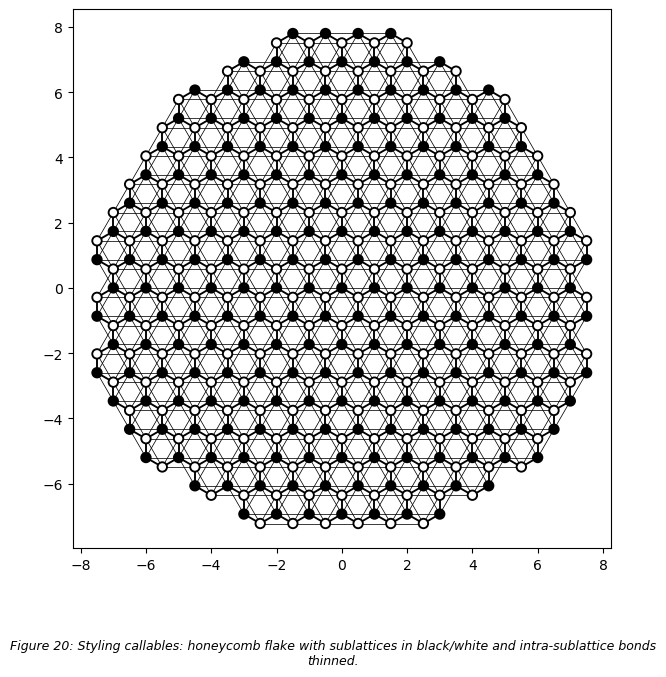

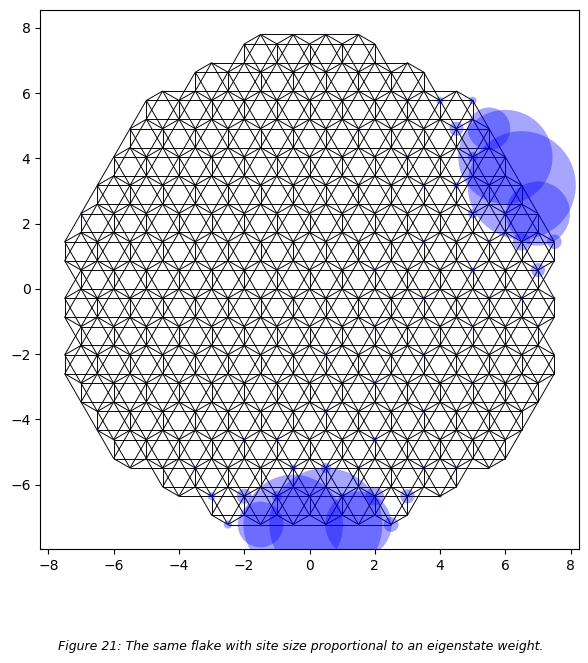

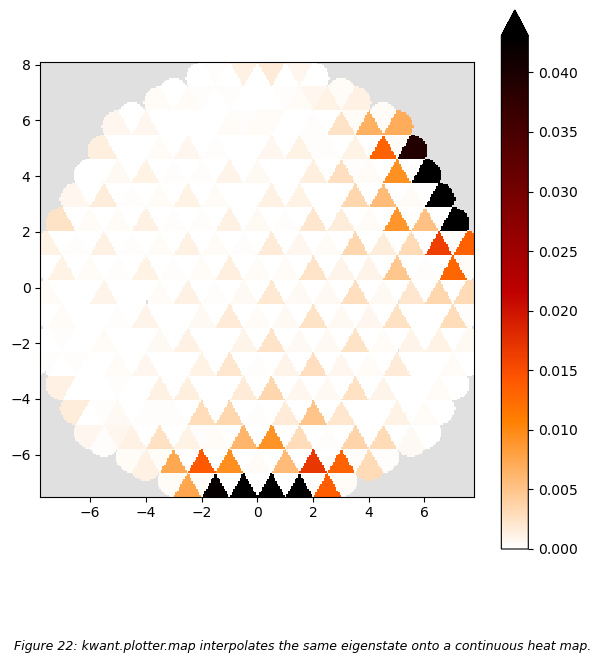

In [20]:
# --- Styling: sublattices, wave-function weight, 3D --------------------------
import kwant, numpy as np
import scipy.linalg as la
from matplotlib import pyplot

lat = kwant.lattice.honeycomb(norbs=1)
a_sub, b_sub = lat.sublattices

def circle(pos):
    x, y = pos
    return x**2 + y**2 < 8**2

flake = kwant.Builder()
flake[lat.shape(circle, (0, 0))] = 0
flake[lat.neighbors()] = -1
flake.eradicate_dangling()             # kill spurious dangling-atom states
flake[lat.neighbors(2)] = -0.1         # next-nearest neighbours

# colour by sublattice, thin the intra-sublattice bonds
kwant.plot(flake,
           site_color=lambda s: 'black' if s.family == a_sub else 'white',
           hop_lw=lambda s1, s2: 0.04 if s1.family == s2.family else 0.1,
           site_lw=0.1, fig_size=(7, 7), show=False)
show_fig(r'Styling callables: honeycomb flake with sublattices in black/white and intra-sublattice bonds thinned.')

# size the sites by an eigenstate's weight
fflake = flake.finalized()
evecs = la.eigh(fflake.hamiltonian_submatrix())[1]
wf = np.abs(evecs[:, len(evecs) // 2])**2

kwant.plot(fflake, site_size=lambda i: 3 * wf[i] / wf.max(),
           site_color=(0, 0, 1, 0.35), hop_lw=0.05, fig_size=(7, 7), show=False)
show_fig(r'The same flake with site size proportional to an eigenstate weight.')

kwant.plotter.map(fflake, wf, oversampling=10, cmap='gist_heat_r', fig_size=(7, 7), show=False)
show_fig(r'kwant.plotter.map interpolates the same eigenstate onto a continuous heat map.')

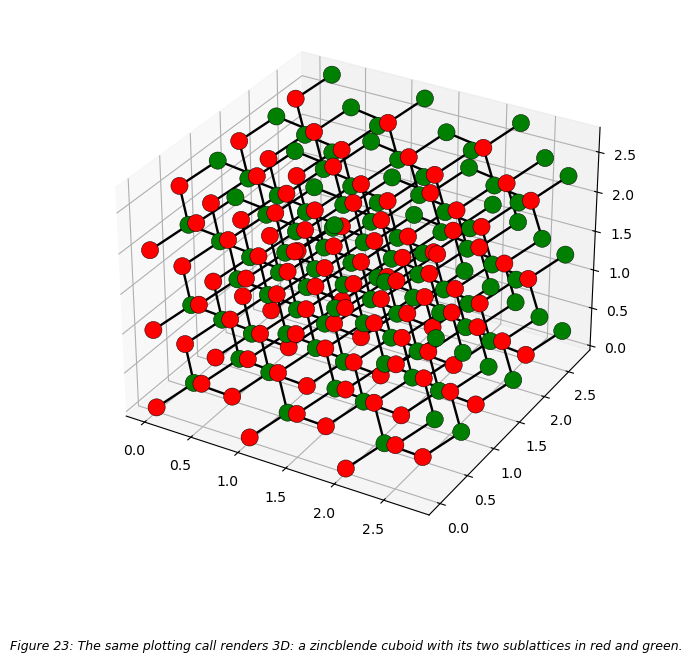

In [21]:
# --- A 3D system plots with the same call ------------------------------------
import kwant

lat3 = kwant.lattice.general([(0, 0.5, 0.5), (0.5, 0, 0.5), (0.5, 0.5, 0)],
                             [(0, 0, 0), (0.25, 0.25, 0.25)], norbs=1)
a3, b3 = lat3.sublattices

def cuboid_shape(pos):
    x, y, z = pos
    return 0 <= x < 3 and 0 <= y < 3 and 0 <= z < 3

cube = kwant.Builder()
cube[lat3.shape(cuboid_shape, (0, 0, 0))] = 0
cube[lat3.neighbors()] = -1

kwant.plot(cube, site_size=0.18, site_lw=0.01, hop_lw=0.05,
           site_color=lambda s: 'r' if s.family == a3 else 'g',
           fig_size=(7, 7), show=False)
show_fig(r'The same plotting call renders 3D: a zincblende cuboid with its two sublattices in red and green.')

---
## 12. The Kernel Polynomial Method — spectral densities without diagonalisation

### Why

Diagonalising a sparse $N\times N$ Hamiltonian costs $O(N^3)$ in the worst case. But often
you do not want eigenvectors — you want the **density of states**, a local DOS, or a
conductivity. KPM gets those in $O(N)$ per moment, for systems with millions of sites.

### How

**Step 1 — rescale.** Chebyshev polynomials $T_n(x) = \cos(n \arccos x)$ live on
$[-1,1]$, so rescale $H \to \tilde H = (H - b)/a$ with the spectrum inside $(-1,1)$.

**Step 2 — expand.** Any spectral function is expanded as
$$\rho(E) = \frac{1}{\pi\sqrt{1-E^2}}\left(\mu_0 + 2\sum_{n=1}^{N-1} \mu_n T_n(E)\right),
\qquad \mu_n = \operatorname{Tr}\big[T_n(\tilde H)\big].$$

**Step 3 — iterate.** The Chebyshev recurrence
$$T_{n+1}(\tilde H)\lvert v\rangle = 2\tilde H\,T_n(\tilde H)\lvert v\rangle - T_{n-1}(\tilde H)\lvert v\rangle$$
means each moment costs **one sparse matrix–vector product**. No factorisation, no storage
beyond two vectors.

**Step 4 — stochastic trace.** The trace is estimated with random vectors $\lvert r\rangle$
with random phases: $\operatorname{Tr}A \approx \frac{1}{R}\sum_r \langle r\rvert A \lvert r\rangle$,
with relative error $\sim 1/\sqrt{RN}$. Large systems need *fewer* random vectors — the
self-averaging is the point.

**Step 5 — kernel.** Truncating the series at $N$ moments causes Gibbs oscillations.
Multiplying $\mu_n$ by a **kernel** $g_n$ (Jackson by default) suppresses them, at the cost
of broadening features to resolution $\sim a\pi/N$. **More moments = finer energy
resolution**; more random vectors = less statistical noise. They are separate knobs.

### API

```python
spectrum = kwant.kpm.SpectralDensity(fsyst, num_moments=..., num_vectors=...)
energies, densities = spectrum()          # the DOS
spectrum.add_moments(100)                 # refine resolution, reuses work
spectrum.add_vectors(5)                   # reduce noise
spectrum.integrate(distribution_function=fermi)   # e.g. total particle number
```

For **local** DOS, replace the random vectors with vectors localised on the sites of
interest via `vector_factory=kwant.kpm.LocalVectors(fsyst, where)` and `mean=False`.

**Why Chebyshev.**  KPM expands $\delta(E-H)$ in Chebyshev polynomials
$T_n(H)$, evaluated by sparse matrix-vector products only — $\mathcal{O}(N)$
per moment, no diagonalisation.  Truncating the series produces Gibbs
oscillations; multiplying the moments by the *Jackson kernel* damps them at
the cost of an energy resolution $\sim \Delta E/N_{\rm moments}$ (exercise
1.9).  The stochastic trace over random vectors converges as
$1/\sqrt{N_{\rm vec} N}$ — huge systems are actually *easier*.  *Further
reading:* Weisse, Wellein, Alvermann & Fehske, RMP **78**, 275 (2006).


sites: 6493


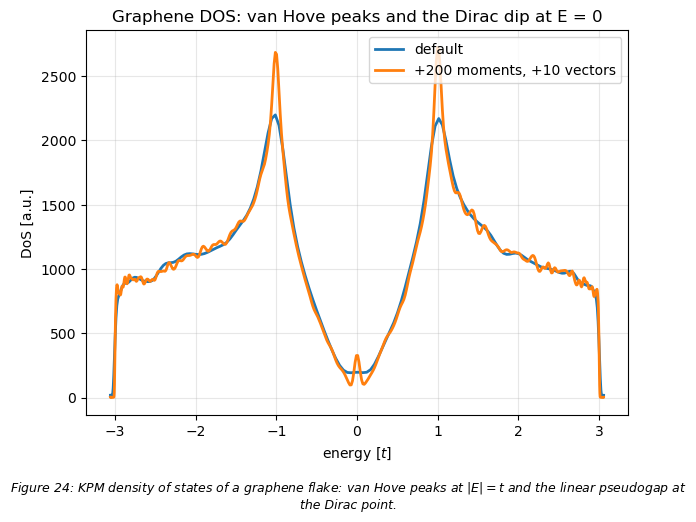

In [22]:
# --- DOS of a graphene flake by KPM ------------------------------------------
import kwant, kwant.kpm, numpy as np
from matplotlib import pyplot

def make_flake(r=30, t=-1, a=1, m=0.0):
    syst = kwant.Builder()
    lat = kwant.lattice.honeycomb(a, norbs=1)
    def circle(pos):
        x, y = pos
        return x**2 + y**2 < r**2
    syst[lat.a.shape(circle, (0, 0))] =  m      # staggered on-site (m != 0 opens a gap)
    syst[lat.b.shape(circle, (0, 0))] = -m
    syst[lat.neighbors()] = t
    syst.eradicate_dangling()
    return syst

fsyst_kpm = make_flake().finalized()
print("sites:", len(fsyst_kpm.sites))

spectrum = kwant.kpm.SpectralDensity(fsyst_kpm)
energies, densities = spectrum()

pyplot.plot(energies, densities.real, lw=2, label="default")

spectrum.add_moments(200)          # sharper energy resolution
spectrum.add_vectors(10)           # less stochastic noise
e2, d2 = spectrum()
pyplot.plot(e2, d2.real, lw=2, label="+200 moments, +10 vectors")

pyplot.xlabel("energy $[t]$"); pyplot.ylabel("DoS [a.u.]")
pyplot.title("Graphene DOS: van Hove peaks and the Dirac dip at E = 0")
pyplot.legend(); pyplot.grid(alpha=.3); show_fig(r'KPM density of states of a graphene flake: van Hove peaks at $|E|=t$ and the linear pseudogap at the Dirac point.')

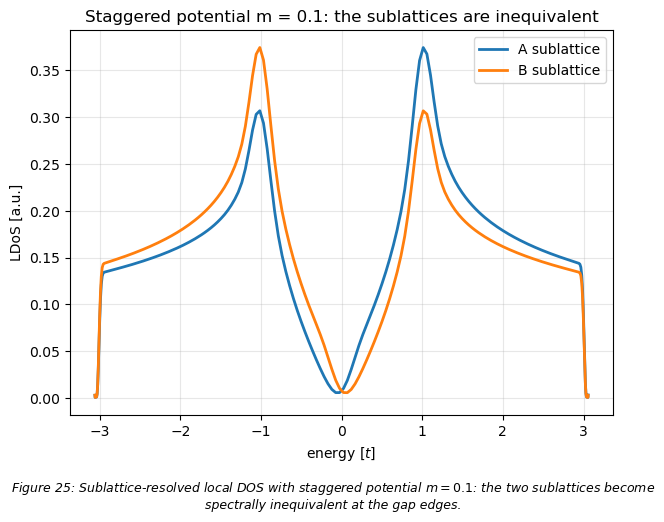

In [23]:
# --- Sublattice-resolved LOCAL density of states with LocalVectors -----------
import kwant.kpm, numpy as np
from matplotlib import pyplot

fsyst_stag = make_flake(m=0.1).finalized()

center_tag = np.array([0, 0])
where = lambda s: s.tag == center_tag           # the two atoms of the central cell

vector_factory = kwant.kpm.LocalVectors(fsyst_stag, where)
local_dos = kwant.kpm.SpectralDensity(fsyst_stag, num_vectors=None,
                                      vector_factory=vector_factory,
                                      mean=False)
energies, densities = local_dos()

pyplot.plot(energies, densities[:, 0].real, lw=2, label="A sublattice")
pyplot.plot(energies, densities[:, 1].real, lw=2, label="B sublattice")
pyplot.xlabel("energy $[t]$"); pyplot.ylabel("LDoS [a.u.]")
pyplot.title("Staggered potential m = 0.1: the sublattices are inequivalent")
pyplot.legend(); pyplot.grid(alpha=.3); show_fig(r'Sublattice-resolved local DOS with staggered potential $m=0.1$: the two sublattices become spectrally inequivalent at the gap edges.')

---
## 13. `kwant.continuum` — symbolic Hamiltonians, discretised automatically

Hand-discretising a $k\cdot p$ model is error-prone: sign conventions, symmetrisation of
terms like $k_x A(x) k_x$, and the factors of $i$ all bite. `kwant.continuum` does it
symbolically with SymPy.

```python
template = kwant.continuum.discretize('k_x**2 + k_y**2 + V(x, y)')
```

The result is a `Builder` **template** with translational symmetry in every direction — a
recipe, not a system. You then stamp it onto a shape:

```python
syst = kwant.Builder()
syst.fill(template, shape_function, start_point)
```

`fill` copies the template's on-site and hopping values onto every site of the region.
Leads are built the same way from the same template, which guarantees they match.

### What the discretiser knows

- $k_i \to$ symmetric finite differences; **$k_x A(x) k_x$ is discretised correctly**, not
  as $A k_x^2$.
- `identity(n)`, `kron(...)`, `sigma_0/x/y/z` are recognised, so multi-band models are natural.
- Coordinates `x, y, z` and arbitrary functions `V(x, y)` become Kwant parameters.
- `grid=a` sets the lattice constant.

### Worked example: the BHZ model

The Bernevig–Hughes–Zhang model of a HgTe quantum well is the canonical 2D topological
insulator:

$$H = C + M\sigma_0\tau_z - (B)(k_x^2+k_y^2)\sigma_0\tau_z - D(k_x^2+k_y^2)\sigma_0\tau_0
+ A k_x \sigma_z\tau_x - A k_y \sigma_0\tau_y$$

The sign of $M/B$ decides the phase. **Inverted** band ordering ($M/B > 0$) gives the
quantum spin Hall insulator: a bulk gap crossed by a pair of **helical edge states**,
counter-propagating and opposite-spin, protected by time reversal. That crossing is what
you will see in the band structure below, and the spin density map shows the two edges
carrying opposite spin.

`kwant.continuum.lambdify` gives you the *continuum* Hamiltonian as a callable, which is how
you check that the lattice model reproduces the continuum near $k=0$ — always do this.

**Where such Hamiltonians come from.**  Models like BHZ are $k\cdot p$
theory: an expansion of the band structure around a high-symmetry point in
a small set of bands, with symmetry dictating which terms may appear and
experiment (or ab initio) fixing the coefficients.  The discretiser then
turns the polynomial in $k$ into hoppings — the reverse of the
$\tan$-expansion of §1, sharing its accuracy limits.  *Further reading:*
Winkler (2003) for $k\cdot p$; Voon & Willatzen, *The k·p Method*
(Springer, 2009); BHZ, Science **314**, 1757 (2006).


In [24]:
# --- BHZ: symbolic model -> lattice system -> helical edge states ------------
import kwant, kwant.continuum, numpy as np
from matplotlib import pyplot

hamiltonian = """
   + C * identity(4) + M * kron(sigma_0, sigma_z)
   - B * (k_x**2 + k_y**2) * kron(sigma_0, sigma_z)
   - D * (k_x**2 + k_y**2) * kron(sigma_0, sigma_0)
   + A * k_x * kron(sigma_z, sigma_x)
   - A * k_y * kron(sigma_0, sigma_y)
"""

a = 20                                   # lattice constant in nm
template = kwant.continuum.discretize(hamiltonian, grid=a)
print(template)                          # inspect the generated tight-binding model

# Discrete coordinates: x y

# Onsite element:
_cache_0 = (
array([[-0.01+0.j,  0.  +0.j,  0.  +0.j,  0.  +0.j],
       [ 0.  +0.j,  0.01+0.j,  0.  +0.j,  0.  +0.j],
       [ 0.  +0.j,  0.  +0.j, -0.01+0.j,  0.  +0.j],
       [ 0.  +0.j,  0.  +0.j,  0.  +0.j,  0.01+0.j]]))
_cache_1 = (
array([[1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j]]))
_cache_2 = (
array([[-0.01+0.j,  0.  +0.j,  0.  +0.j,  0.  +0.j],
       [ 0.  +0.j, -0.01+0.j,  0.  +0.j,  0.  +0.j],
       [ 0.  +0.j,  0.  +0.j, -0.01+0.j,  0.  +0.j],
       [ 0.  +0.j,  0.  +0.j,  0.  +0.j, -0.01+0.j]]))
_cache_3 = (
array([[ 1.+0.j,  0.+0.j,  0.+0.j,  0.+0.j],
       [ 0.+0.j, -1.+0.j,  0.+0.j,  0.+0.j],
       [ 0.+0.j,  0.+0.j,  1.+0.j,  0.+0.j],
       [ 0.+0.j,  0.+0.j,  0.+0.j, -1.+0.j]]))
_cache_4 = (
array([[0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j

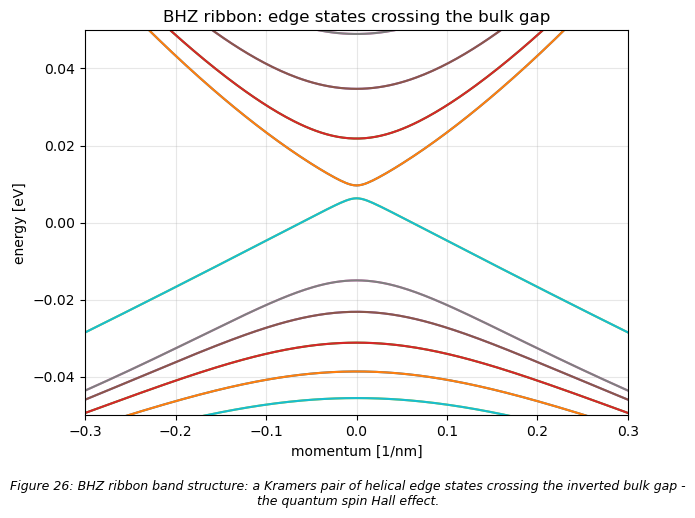

In [25]:
# --- Build a ribbon from the template ----------------------------------------
L, W = 2000, 1000                        # nm

def shape(site):
    x, y = site.pos
    return 0 <= y < W and 0 <= x < L

def lead_shape(site):
    x, y = site.pos
    return 0 <= y < W

syst = kwant.Builder()
syst.fill(template, shape, (0, 0))

lead = kwant.Builder(kwant.TranslationalSymmetry([-a, 0]))
lead.fill(template, lead_shape, (0, 0))

syst.attach_lead(lead)
syst.attach_lead(lead.reversed())
fbhz = syst.finalized()

params = dict(A=3.65, B=-68.6, D=-51.1, M=-0.01, C=0)   # inverted regime

kwant.plotter.bands(fbhz.leads[0], params=params,
                    momenta=np.linspace(-0.3, 0.3, 201), show=False)
pyplot.grid(alpha=.3)
pyplot.xlim(-.3, 0.3); pyplot.ylim(-0.05, 0.05)
pyplot.xlabel("momentum [1/nm]"); pyplot.ylabel("energy [eV]")
pyplot.title("BHZ ribbon: edge states crossing the bulk gap")
show_fig(r'BHZ ribbon band structure: a Kramers pair of helical edge states crossing the inverted bulk gap - the quantum spin Hall effect.')

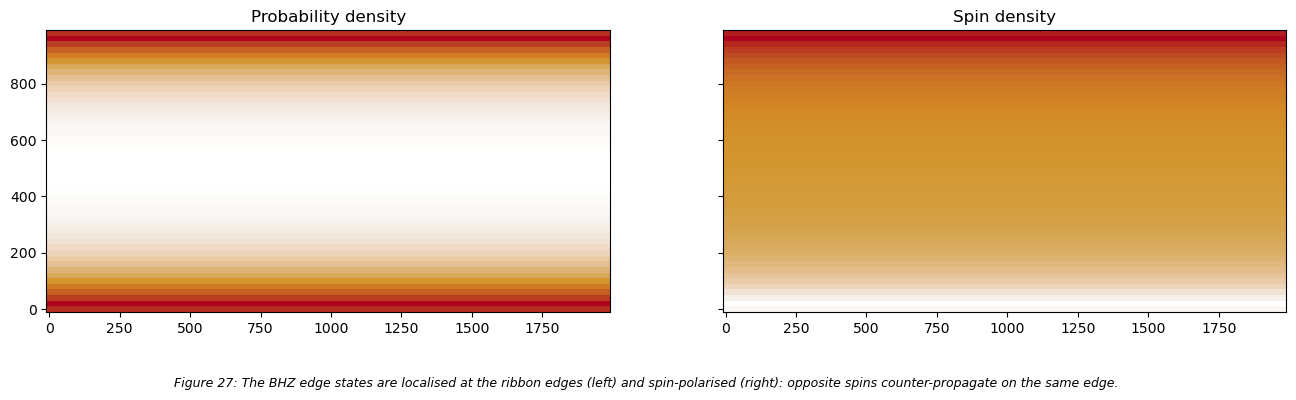

In [26]:
# --- Where do the edge states live, and what spin do they carry? -------------
wf = kwant.wave_function(fbhz, energy=0, params=params)

prob_density = kwant.operator.Density(fbhz, np.eye(4))
spin_density = kwant.operator.Density(fbhz, np.kron(np.array([[1, 0], [0, -1]]),
                                                    np.eye(2)))

wf_sqr = sum(prob_density(psi) for psi in wf(0))
rho_sz = sum(spin_density(psi) for psi in wf(0))

fig, (ax1, ax2) = pyplot.subplots(1, 2, sharey=True, figsize=(16, 4))
kwant.plotter.map(fbhz, wf_sqr, ax=ax1)
kwant.plotter.map(fbhz, rho_sz, ax=ax2)
ax1.set_title("Probability density"); ax2.set_title("Spin density")
show_fig(r'The BHZ edge states are localised at the ribbon edges (left) and spin-polarised (right): opposite spins counter-propagate on the same edge.')

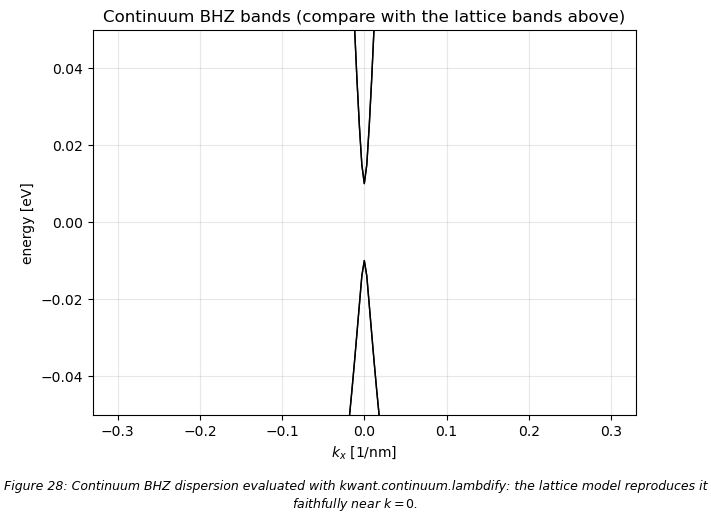

In [27]:
# --- Sanity check: does the lattice model match the continuum near k = 0? ----
import kwant.continuum

h_k = kwant.continuum.lambdify(hamiltonian, locals=params)
k_cont = np.linspace(-0.3, 0.3, 201)
e_cont = [np.linalg.eigvalsh(h_k(k_x=k, k_y=0)) for k in k_cont]

pyplot.plot(k_cont, e_cont, 'k-', lw=1)
pyplot.ylim(-0.05, 0.05); pyplot.xlabel("$k_x$ [1/nm]"); pyplot.ylabel("energy [eV]")
pyplot.title("Continuum BHZ bands (compare with the lattice bands above)")
pyplot.grid(alpha=.3); show_fig(r'Continuum BHZ dispersion evaluated with kwant.continuum.lambdify: the lattice model reproduces it faithfully near $k=0$.')

---
## 14. Magnetic fields — Peierls substitution and Landau levels

### The Peierls substitution

A magnetic field enters a tight-binding model through the **phase** picked up by an
electron hopping between sites:

$$t_{ij} \;\longrightarrow\; t_{ij}\,\exp\!\left(-\frac{ie}{\hbar}\int_{\mathbf{r}_j}^{\mathbf{r}_i}\mathbf{A}\cdot d\boldsymbol{\ell}\right).$$

The physical content is gauge-invariant: the phase around any closed plaquette equals
$2\pi \Phi/\Phi_0$, the flux through it in units of the flux quantum. In the Landau gauge
$\mathbf{A} = (-By, 0, 0)$ this is a $y$-dependent phase on $x$-hoppings:

```python
def hopx(to_site, from_site, B):
    y = from_site.tag[1]
    return -t * np.exp(-1j * B * y)
```

**Discretisation constraint**: the flux per plaquette must be small, $Ba^2 \ll \Phi_0$,
or you leave the continuum regime and enter Hofstadter physics — which is fine if intended,
but not if you meant to model a smooth field.

Kwant 1.4 added `kwant.physics.magnetic_gauge`, which computes a consistent gauge
automatically for arbitrary geometries — much safer than hand-rolling a gauge on a
non-trivial shape, where a naive choice can break the lead's translational symmetry.

> **Version pitfall (checked 2026-08-28).** With **kwant 1.5.0 and numpy ≥ 2.5** (released
> 2026-06-21), `magnetic_gauge` raises
> `ValueError: Both input arrays must be (arrays of) 3-dimensional vectors` for every
> 2D system: `kwant/physics/gauge.py` calls `np.cross` on 2-vectors, a use NumPy removed in
> 2.5. The fix has been on Kwant's `main` branch since January 2025 but is not in any
> release. Until a 1.5.1 appears, pin `numpy<2.5` if you need `magnetic_gauge`; the
> hand-rolled Peierls phases used in this notebook are unaffected.

### Landau levels

In an infinite 2D system the field quenches the kinetic energy into flat, massively
degenerate **Landau levels** $E_n = \hbar\omega_c(n + 1/2)$, $\omega_c = eB/m$.

`kwant.continuum.discretize_landau` builds a system in the **Landau-level basis** directly
rather than on a real-space lattice: translational symmetry perpendicular to the field is
used to reduce the problem, with `N` the number of levels retained. This is *far* cheaper
than a real-space lattice for strong fields, and is the right tool for spectra vs $B$.

*Further reading:* the lattice problem at rational flux is the Hofstadter
butterfly, PRB **14**, 2239 (1976).  The quantum Hall effect itself:
K. v. Klitzing *et al.*, PRL **45**, 494 (1980); the edge-state picture,
B. I. Halperin, PRB **25**, 2185 (1982); the gauge argument for exact
quantisation, R. B. Laughlin, PRB **23**, 5632 (1981).


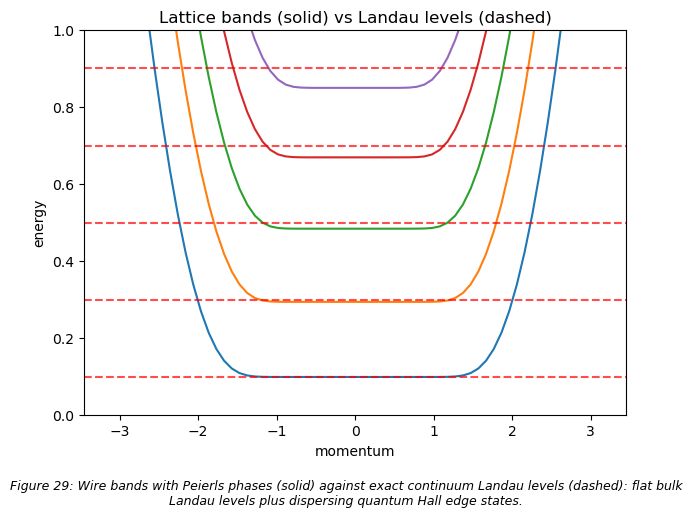

In [28]:
# --- Peierls phases on a lattice, versus exact Landau levels -----------------
import kwant, kwant.continuum, numpy as np, scipy.linalg
from matplotlib import pyplot

lat = kwant.lattice.square(norbs=1)

def peierls(to_site, from_site, B):
    y = from_site.tag[1]
    return -1 * np.exp(-1j * B * y)

wire = kwant.Builder(kwant.TranslationalSymmetry((-1, 0)))
wire[(lat(0, j) for j in range(-19, 20))] = 4
wire[lat.neighbors()] = -1
wire[kwant.HoppingKind((1, 0), lat)] = peierls
fwire = wire.finalized()

# the same physics in the Landau-level basis
landau_syst = kwant.continuum.discretize_landau("k_x**2 + k_y**2", N=5).finalized()

fig, ax = pyplot.subplots(1, 1)
params = dict(B=0.1)
kwant.plotter.bands(fwire, ax=ax, params=params)

h = landau_syst.hamiltonian_submatrix(params=params)
for ev in scipy.linalg.eigvalsh(h):
    ax.axhline(ev, linestyle='--', color='r', alpha=.7)

ax.set_xlabel("momentum"); ax.set_ylabel("energy")
ax.set_ylim(0, 1)
ax.set_title("Lattice bands (solid) vs Landau levels (dashed)")
show_fig(r'Wire bands with Peierls phases (solid) against exact continuum Landau levels (dashed): flat bulk Landau levels plus dispersing quantum Hall edge states.')

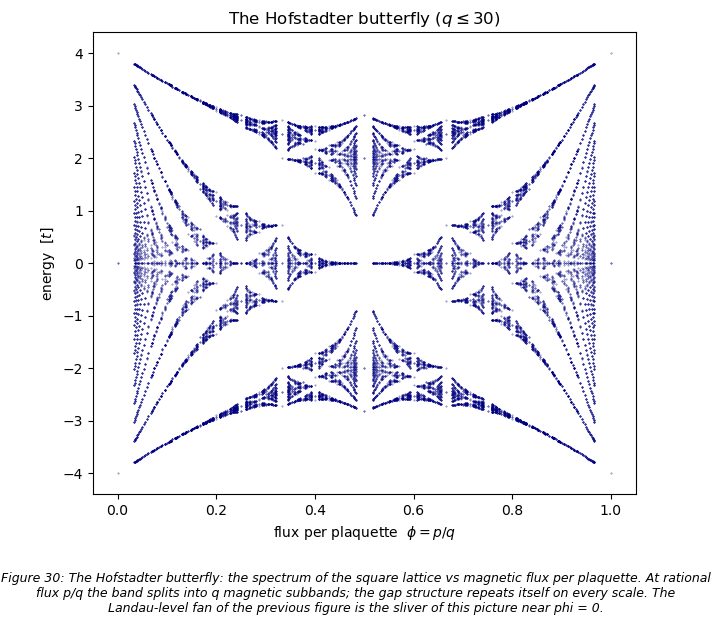

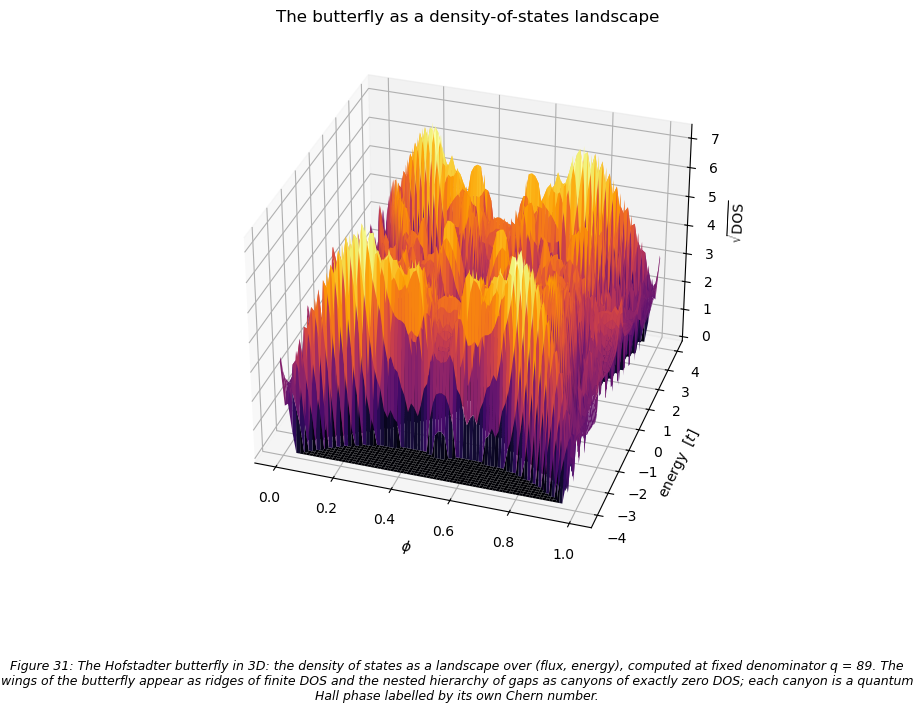

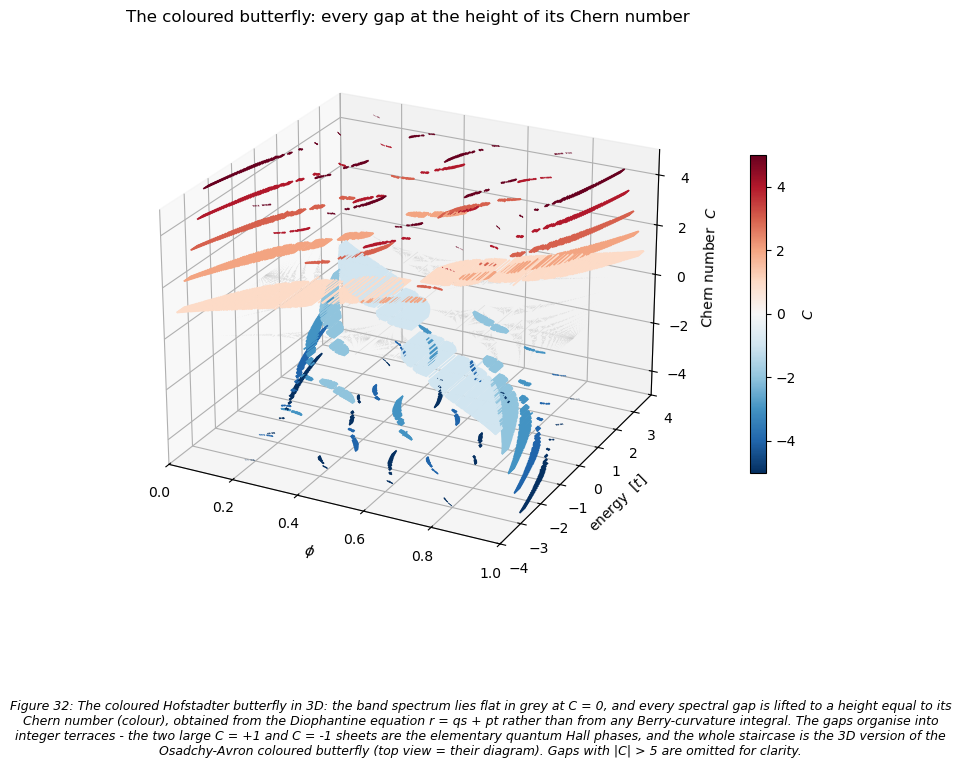

In [29]:
# --- The Hofstadter butterfly, flat and in 3D ---------------------------------
# At rational flux phi = p/q per plaquette, the magnetic translation group
# splits the tight-binding band into q magnetic subbands.  The spectrum as a
# function of flux is the Hofstadter butterfly [PRB 14, 2239 (1976)]: a
# a spectrum whose gap structure recurs at every scale, and every gap inside it carries a quantised Hall conductance (the
# TKNN integers of Part II).
import numpy as np
from matplotlib import pyplot

def harper(p, q, k1, k2):
    """The q x q magnetic Bloch Hamiltonian of the square lattice (t = 1)."""
    m = np.arange(q)
    H = np.diag(2 * np.cos(k2 + 2 * np.pi * p / q * m)).astype(complex)
    H += np.diag(np.ones(q - 1), 1) + np.diag(np.ones(q - 1), -1)
    H[0, q - 1] += np.exp(-1j * q * k1)
    H[q - 1, 0] += np.exp(1j * q * k1)
    return H

# (a) the classic butterfly: eigenvalues for every p/q with q <= 30
from math import gcd
phis, Es = [], []
for q in range(1, 31):
    for p in range(q + 1):
        if gcd(p, q) != 1 and not (p in (0, q) and q == 1):
            continue
        for k1 in (0, np.pi / q):
            for k2 in (0, np.pi):
                ev = np.linalg.eigvalsh(harper(p, q, k1, k2))
                phis += [p / q] * len(ev)
                Es += list(ev)
phis, Es = np.array(phis), np.array(Es)
assert np.abs(Es).max() <= 4 + 1e-9          # bandwidth bound of the model

pyplot.figure(figsize=(7, 6))
pyplot.plot(phis, Es, '.', ms=0.7, color='navy', alpha=0.6)
pyplot.xlabel(r'flux per plaquette  $\phi = p/q$')
pyplot.ylabel('energy  $[t]$')
pyplot.title(r'The Hofstadter butterfly ($q \leq 30$)')
show_fig(r'The Hofstadter butterfly: the spectrum of the square lattice vs magnetic flux per plaquette. At rational flux p/q the band splits into q magnetic subbands; the gap structure repeats itself on every scale. The Landau-level fan of the previous figure is the sliver of this picture near phi = 0.')

# (b) the same object as a 3D landscape: DOS(E, phi) at fixed prime q
q3 = 89                                        # prime -> every p/q3 is reduced
Ebins = np.linspace(-4, 4, 161)
Ecent = 0.5 * (Ebins[1:] + Ebins[:-1])
fluxes = np.arange(q3 + 1) / q3
dos = np.zeros((len(fluxes), len(Ecent)))
ks = np.linspace(0, np.pi / q3, 4)
for ip, p in enumerate(range(q3 + 1)):
    ev = np.concatenate([np.linalg.eigvalsh(harper(p, q3, k1, k2))
                         for k1 in ks for k2 in (0, np.pi / 2, np.pi)])
    dos[ip] = np.histogram(ev, bins=Ebins)[0]
kern = np.exp(-0.5 * (np.arange(-4, 5) / 1.7) ** 2)
dos = np.apply_along_axis(lambda r: np.convolve(r, kern / kern.sum(),
                                                mode='same'), 1, dos)

PHI, EE = np.meshgrid(fluxes, Ecent, indexing='ij')
fig = pyplot.figure(figsize=(9, 7))
ax = fig.add_subplot(projection='3d')
ax.plot_surface(PHI, EE, np.sqrt(dos), cmap='inferno', linewidth=0,
                antialiased=True, rcount=120, ccount=120)
ax.set_xlabel(r'$\phi$')
ax.set_ylabel('energy  $[t]$')
ax.set_zlabel(r'$\sqrt{\mathrm{DOS}}$')
ax.set_title('The butterfly as a density-of-states landscape')
ax.view_init(elev=32, azim=-72)
show_fig(r'The Hofstadter butterfly in 3D: the density of states as a landscape over (flux, energy), computed at fixed denominator q = 89. The wings of the butterfly appear as ridges of finite DOS and the nested hierarchy of gaps as canyons of exactly zero DOS; each canyon is a quantum Hall phase labelled by its own Chern number.')

# (c) the coloured butterfly in 3D: every spectral gap lifted to a height
# equal to its Chern number.  At flux p/q the Hall conductance of the r-th
# gap solves the Diophantine equation r = q s + p t with |t| <= q/2
# [TKNN 1982; Osadchy & Avron, J. Math. Phys. 42, 5665 (2001)] -- no Berry
# curvature integral needed, pure number theory.
from mpl_toolkits.mplot3d.art3d import Line3DCollection
from matplotlib import cm, colors as mcolors

segs, cherns, bands = [], [], []
QMAX, TMAX = 36, 5
for q in range(2, QMAX + 1):
    for p in range(q):
        if gcd(p, q) != 1:
            continue
        allev = np.array([np.linalg.eigvalsh(harper(p, q, k1, k2))
                          for k1 in (0, np.pi / (2 * q), np.pi / q)
                          for k2 in (0, np.pi / 2, np.pi)])
        top = allev.max(axis=0)                 # upper edge of band r
        bot = allev.min(axis=0)                 # lower edge of band r
        for r in range(q):                      # grey silhouette of the bands
            bands.append([(p / q, bot[r], 0), (p / q, top[r], 0)])
        pbar = pow(p, -1, q)
        for r in range(1, q):                   # gap above r filled bands
            if bot[r] <= top[r - 1] + 1e-9:
                continue
            t = (r * pbar) % q
            if t > q / 2:
                t -= q
            if abs(t) > TMAX:
                continue
            segs.append([(p / q, top[r - 1], t), (p / q, bot[r], t)])
            cherns.append(t)

# Diophantine sanity check: at phi = 1/3 the two gaps carry C = +1 and -1
ts = [((r * pow(1, -1, 3)) % 3) for r in (1, 2)]
assert [t - 3 if t > 1.5 else t for t in ts] == [1, -1]

norm = mcolors.Normalize(vmin=-TMAX, vmax=TMAX)
cmap = cm.RdBu_r
fig = pyplot.figure(figsize=(9.5, 7.5))
ax = fig.add_subplot(projection='3d')
ax.add_collection3d(Line3DCollection(bands, colors='0.75', lw=0.5, alpha=0.4))
ax.add_collection3d(Line3DCollection(segs,
                                     colors=cmap(norm(np.array(cherns))),
                                     lw=1.2))
ax.set_xlim(0, 1)
ax.set_ylim(-4, 4)
ax.set_zlim(-TMAX, TMAX)
ax.set_xlabel(r'$\phi$')
ax.set_ylabel('energy  $[t]$')
ax.set_zlabel(r'Chern number  $C$')
ax.view_init(elev=24, azim=-63)
fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, shrink=0.55,
             pad=0.08, label=r'$C$')
ax.set_title('The coloured butterfly: every gap at the height of its Chern number')
show_fig(r'The coloured Hofstadter butterfly in 3D: the band spectrum lies flat in grey at C = 0, and every spectral gap is lifted to a height equal to its Chern number (colour), obtained from the Diophantine equation r = qs + pt rather than from any Berry-curvature integral. The gaps organise into integer terraces - the two large C = +1 and C = -1 sheets are the elementary quantum Hall phases, and the whole staircase is the 3D version of the Osadchy-Avron coloured butterfly (top view = their diagram). Gaps with |C| > 5 are omitted for clarity.')

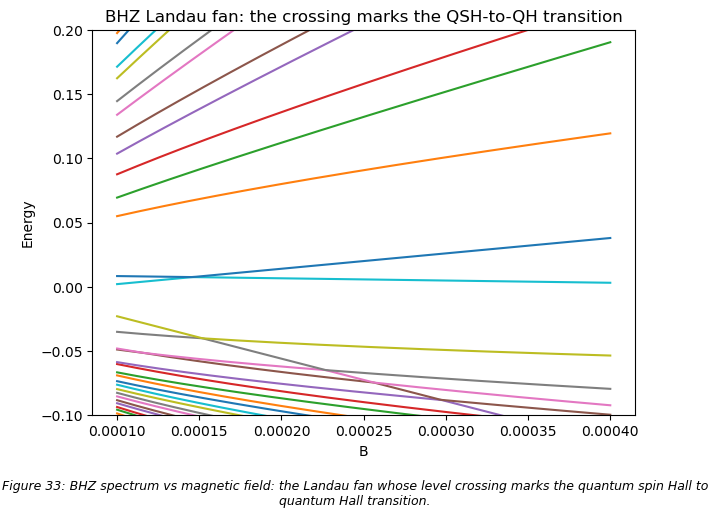

In [30]:
# --- Spectrum of the BHZ model versus magnetic field -------------------------
import kwant, kwant.continuum, numpy as np
from matplotlib import pyplot

hamiltonian_B = """
   + C * identity(4) + M * kron(sigma_0, sigma_z)
   - F * (k_x**2 + k_y**2) * kron(sigma_0, sigma_z)
   - D * (k_x**2 + k_y**2) * kron(sigma_0, sigma_0)
   + A * k_x * kron(sigma_z, sigma_x)
   - A * k_y * kron(sigma_0, sigma_y)
"""

syst_B = kwant.continuum.discretize_landau(hamiltonian_B, N=10).finalized()

params = dict(A=3.645, F=-68.6, D=-51.2, M=-0.01, C=0)
b_values = np.linspace(0.0001, 0.0004, 200)

kwant.plotter.spectrum(syst_B, ('B', b_values), params=params, show=False)
pyplot.ylim(-0.1, 0.2)
pyplot.title("BHZ Landau fan: the crossing marks the QSH-to-QH transition")
show_fig(r'BHZ spectrum vs magnetic field: the Landau fan whose level crossing marks the quantum spin Hall to quantum Hall transition.')

---
## 15. Solvers, performance and scaling

### What actually costs time

For a scattering problem Kwant assembles a sparse linear system of dimension
$\sim N_{\text{orb}}$ (scattering region) $+$ lead modes, and solves it by **sparse LU
factorisation**. Cost is dominated by fill-in during factorisation, which depends on the
*shape* of the system, not just its size:

- **Quasi-1D** (long, thin): cost $\sim O(L W^3)$ — cheap. Long wires are fine.
- **2D square** ($N = L^2$ sites): $\sim O(N^{3/2})$.
- **3D**: $\sim O(N^2)$ — this is where you hit the wall.

### Choosing a solver

| Module | Backend | Notes |
|---|---|---|
| `kwant.solvers.mumps` | MUMPS | **Much faster**, multithreaded, memory-tunable. Use it. |
| `kwant.solvers.sparse` | SciPy SuperLU | Always available, the fallback. |
| `kwant.solvers.default` | whichever is best available | what `kwant.smatrix` uses |

```python
import kwant.solvers.mumps as mumps
mumps.options(nrhs=10, ordering='metis', sparse_rhs=True)
```

- `nrhs` — solve for several right-hand sides at once. Big win when a lead has many modes.
- `ordering` — `'metis'` or `'scotch'` usually beat the default on large 2-D/3-D systems.
- `sparse_rhs` — keeps the right-hand side sparse; helps memory on wide leads.

### Practical rules

1. **Build once, solve many.** Construction and finalisation are expensive; parameterise
   with `params` and re-solve. Never rebuild inside an energy loop.
2. **`smatrix` vs `wave_function`.** If you only need conductance, `smatrix` is cheaper —
   `wave_function` reconstructs the full state in the scattering region.
3. **Use `tinyarray`** for small fixed matrices, not NumPy. Order-of-magnitude difference.
4. **Shift-invert for closed systems** (`sigma=0` in `eigsh`), never plain `which='SM'`.
5. **KPM instead of diagonalisation** when you want spectra of very large systems (§ 12).
6. Kwant releases the GIL in its heavy routines, and parameter sweeps are embarrassingly
   parallel — `multiprocessing` over energies/fields is the easy speedup.
7. `hamiltonian_submatrix(sparse=True)` — the dense default will exhaust memory on any
   serious system.

using MUMPS, ordering = 'auto'
W= 10  sites=    400  solve= 0.020 s
W= 20  sites=   1600  solve= 0.059 s


W= 40  sites=   6400  solve= 0.189 s


W= 60  sites=  14400  solve= 0.402 s


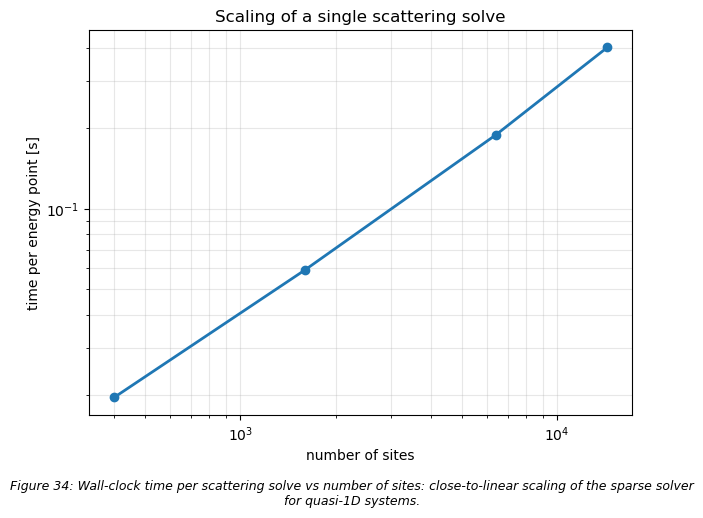

In [31]:
# --- Solver selection and a scaling measurement ------------------------------
import time, numpy as np, kwant
from matplotlib import pyplot

try:
    import kwant.solvers.mumps as mumps
    # The nested-dissection orderings ('metis', 'scotch') are the good ones for
    # 2D lattices, but not every MUMPS build ships them.  Requesting an absent
    # ordering is NOT an error -- MUMPS silently falls back -- so let Kwant pick
    # the best one actually compiled in, and print what was really chosen.
    mumps.options(nrhs=6, ordering='kwant_decides')
    print(f"using MUMPS, ordering = {mumps.default_solver.ordering!r}")
except ImportError:
    print("MUMPS unavailable; using scipy sparse")

lat = kwant.lattice.square(norbs=1)

def timed_wire(L, W, t=1.0):
    syst = kwant.Builder()
    syst[(lat(x, y) for x in range(L) for y in range(W))] = 4 * t
    syst[lat.neighbors()] = -t
    lead = kwant.Builder(kwant.TranslationalSymmetry((-1, 0)))
    lead[(lat(0, j) for j in range(W))] = 4 * t
    lead[lat.neighbors()] = -t
    syst.attach_lead(lead); syst.attach_lead(lead.reversed())
    f = syst.finalized()

    t0 = time.time()
    kwant.smatrix(f, 0.5).transmission(1, 0)
    return len(f.sites), time.time() - t0

sizes, times = [], []
for W in (10, 20, 40, 60):
    n, dt = timed_wire(L=4 * W, W=W)
    sizes.append(n); times.append(dt)
    print(f"W={W:3d}  sites={n:7d}  solve={dt:6.3f} s")

pyplot.loglog(sizes, times, 'o-', lw=2)
pyplot.xlabel("number of sites"); pyplot.ylabel("time per energy point [s]")
pyplot.title("Scaling of a single scattering solve")
pyplot.grid(alpha=.3, which='both'); show_fig(r'Wall-clock time per scattering solve vs number of sites: close-to-linear scaling of the sparse solver for quasi-1D systems.')

In [32]:
# --- Parallel parameter sweep -------------------------------------------------
# Energy points are independent, so an energy sweep is embarrassingly parallel.
# But HOW you parallelise it matters, and the obvious way crashes the kernel:
#
#   !!! NEVER call kwant.smatrix from several threads at once. !!!
#
# `kwant.smatrix` dispatches to MUMPS whenever MUMPS is installed, and MUMPS is
# not re-entrant: concurrent solves corrupt its internal state and abort the
# *process*.  In a notebook that surfaces as
#     "The Kernel crashed while executing code in the current cell..."
# It is a segfault, not a Python exception, so try/except cannot catch it, and
# giving each thread its own Solver() instance does not help either -- the
# shared state lives inside the MUMPS library, not in Kwant.
#
# Two safe options:
#   (a) threads + the SciPy/SuperLU solver, which IS re-entrant  -> shown below
#   (b) one process per worker, each with its own MUMPS          -> note at end

import time
from concurrent.futures import ThreadPoolExecutor

import numpy as np
import kwant
import kwant.solvers.sparse as scipy_solver   # SuperLU: safe to call from threads

energies = np.linspace(0.01, 1.0, 64)


def transmission(e):
    # NOTE: scipy_solver.smatrix, *not* kwant.smatrix -- see the warning above.
    return scipy_solver.smatrix(fsyst, e).transmission(1, 0)


t0 = time.perf_counter()
data_serial = np.array([transmission(e) for e in energies])
t_serial = time.perf_counter() - t0

t0 = time.perf_counter()
with ThreadPoolExecutor(max_workers=4) as pool:
    data_par = np.array(list(pool.map(transmission, energies)))
t_par = time.perf_counter() - t0

assert np.allclose(data_par, data_serial), "parallel result disagrees with serial!"

print(f"serial     {t_serial:6.2f} s")
print(f"4 threads  {t_par:6.2f} s   ->  speedup x{t_serial / t_par:.2f}")
print("first five:", np.round(data_par[:5], 6))

# Do not be surprised if the speedup is close to 1x -- or even below it.
# SuperLU holds the GIL for much of the factorisation, and NumPy/SciPy are
# already linked against a multithreaded BLAS that is using every core, so
# Python-level threads mostly add contention.  Measure before you believe.
#
# For a genuine speedup on a long sweep, use PROCESSES.  On Windows the worker
# must be importable, so put it in a module (e.g. sweep_worker.py) rather than
# in a notebook cell, and drive it from a script:
#
#     # sweep_worker.py
#     import kwant
#     _F = None
#     def transmission(e):
#         global _F
#         if _F is None:
#             _F = make_wire()          # each process builds its own system
#         return kwant.smatrix(_F, e).transmission(1, 0)   # MUMPS is fine here:
#                                                          # one solver per process
#     # driver.py
#     from concurrent.futures import ProcessPoolExecutor
#     from sweep_worker import transmission
#     if __name__ == "__main__":                            # required on Windows
#         with ProcessPoolExecutor(max_workers=4) as pool:
#             data = list(pool.map(transmission, energies, chunksize=4))


serial       1.42 s
4 threads    1.65 s   ->  speedup x0.86
first five: [0. 0. 0. 0. 0.]


---
## 16. Pitfalls — the things that actually go wrong

**`norbs` not set.** `kwant.operator` refuses to work, symmetry checks are skipped, and you
get confusing errors much later. Set it on every lattice, always.

**Tuple vs generator when adding sites.**
`syst[(lat(0,0), lat(1,0))] = x` adds a *hopping*, not two sites — because `syst[a, b]` is
`syst[(a, b)]`. Add several sites with a generator or a list.

**Lead symmetry vector points the wrong way.** It must point *away from* the scattering
region, into the lead. `(-a, 0)` = left lead. Use `lead.reversed()` for the other side.

**Dangling sites on non-square lattices.** Cutting a honeycomb or kagome lattice to a shape
leaves atoms with one neighbour, which produce spurious near-zero-energy states.
`syst.eradicate_dangling()`.

**Hermiticity is automatic — and overwritable.** Kwant adds the conjugate hopping for you,
so setting both directions with inconsistent values silently keeps the last one written.

**Closed-system eigenvalues converge slowly** unless you use shift-invert
(`eigsh(..., sigma=0)`).

**`conservation_law` declared where it does not hold.** In a superconducting lead $\Delta$
mixes electrons and holes; declaring `-tau_z` there gives wrong mode labelling. Only declare
symmetries that are actually present.

**Magnetic field too strong for the lattice.** Flux per plaquette must satisfy
$Ba^2 \ll \Phi_0$, otherwise you are computing Hofstadter physics, not continuum Landau
levels. Also, a naive gauge can break lead periodicity — use
`kwant.physics.magnetic_gauge`.

**Discretisation too coarse.** The tight-binding model matches the continuum only for
wavelengths $\gg a$. Always check convergence in $a$, and compare against
`kwant.continuum.lambdify` near $k=0$.

**`kwant.smatrix` is not thread-safe when MUMPS is installed.** Concurrent calls from a
thread pool corrupt MUMPS's internal state and segfault the interpreter -- in a notebook
that is the dreaded "kernel crashed" with no traceback. One solver instance per thread does
*not* help; the shared state is inside the MUMPS library. Threads: use
`kwant.solvers.sparse` (SuperLU, re-entrant). MUMPS in parallel: one process per worker.
See section 15 and `test_thread_safety.py`.

**Rebuilding inside a loop.** Construction dominates runtime. Build once, sweep with
`params`.

**`hamiltonian_submatrix()` dense by default.** Pass `sparse=True` for anything non-trivial.

**Plotting callbacks take different arguments** on a `Builder` (`Site` objects) than on a
finalised system (integer indices).

### Correctness checks worth running

```python
S = kwant.smatrix(fsyst, E).data
assert np.allclose(S.conj().T @ S, np.eye(len(S)))      # unitarity == current conservation
assert np.isclose(T + R, N)                             # sum rule
```

Unitarity failing almost always means the leads are ill-defined — a lead that is not
translationally invariant, or a mode count that changes discontinuously because you sit
exactly at a band edge. Move off the band edge and re-check.

---
## Exercises for Part I

Worked solutions for every exercise are in the companion notebook
**`Kwant_Exercises_Solutions.ipynb`** (same folder).  Difficulty: ◦ = direct,
• = requires some thought, ★ = mini-project.  Every exercise states its
origin.

**E1.1** ◦ *(from the Kwant tutorial, "quantum wire" chapter)* — Thread a
perpendicular magnetic field through the clean wire of §3 with Peierls
phases and compute $G(B)$ at fixed energy.  Explain the step-downs you see
in terms of magnetic depopulation of subbands.

**E1.2** ◦ *(from the Kwant tutorial, spin chapter)* — Add a Zeeman term
$E_Z\sigma_z$ to the wire and recompute the staircase.  Why do the steps
split into half-steps of $e^2/2h$... and at which energies?

**E1.3** • *(original, this notebook)* — The Landauer formula at finite
temperature reads $G = (e^2/h)\int dE\,T(E)\,(-\partial f/\partial E)$.
Take the $T(E)$ of the quantum-well resonance of §5 and plot $G(T_{\rm
temp})$; show the resonance washes out when $k_BT \sim \Gamma$.

**E1.4** ◦ *(adapted from the Kwant tutorial well example)* — Sweep the well
*width* instead of its depth and interpret the spacing of the resonances.

**E1.5** • *(original)* — Universal conductance fluctuations: give the
stadium dot two point-contact leads, compute $G$ over a dense energy window,
and compare $\sqrt{\mathrm{var}\,G}$ with the universal value
$\sim e^2/h$ [Beenakker, RMP 69, 731 (1997)].

**E1.6** • *(original)* — In the graphene p-n junction of §8, sweep the
junction smoothness $w$ and show that transmission at the Dirac point drops
as the junction gets smoother (only near-normal incidence survives —
Cheianov & Fal'ko, PRB 74, 041403 (2006)).

**E1.7** • *(after Blonder-Tinkham-Klapwijk, PRB 25, 4515 (1982))* — For the
N-S junction of §9, map the barrier strength to the BTK parameter $Z$ by
fitting the sub-gap conductance suppression $G(0)/G_N = 1/(1+Z^2)^{...}$ —
or simply plot $G(E=0)$ vs barrier and compare with BTK's
$(1+2Z^2)^{-2}$-type suppression.

**E1.8** ★ *(original)* — Andreev bound states and the Josephson effect:
build an S-N-S junction with pairing phases $0$ and $\varphi$ on the two
sides (no leads; closed system), diagonalise, and plot the sub-gap spectrum
vs $\varphi$.  Verify the ABS dispersion $E \approx \pm\Delta\sqrt{1-\tau
\sin^2(\varphi/2)}$ and sketch the current-phase relation $I \propto
dE/d\varphi$.

**E1.9** ◦ *(from the Kwant KPM documentation)* — Recompute the graphene DOS
of §12 with 10× fewer moments, with and without the Jackson kernel, and
observe Gibbs oscillations vs resolution loss.

**E1.10** • *(after Osadchy & Avron, J. Math. Phys. 42, 5665 (2001))* —
Using the Diophantine solution from the coloured-butterfly cell of §14,
render the classic *flat* coloured butterfly: the $(\phi, E)$ plane with
every gap painted by its Chern number.

**E1.11** ◦ *(pencil, original)* — Show that the FHS plaquette flux
$F = \arg(U_1U_2U_3U_4)$ is invariant under $u_{\mathbf k} \to
e^{i\chi(\mathbf k)}u_{\mathbf k}$, and explain why summing it over the
torus must give an integer multiple of $2\pi$.

---
# Part II — Topological matter

Everything below applies the machinery of Part I to the flagship models of
topological condensed matter, in one, two and three dimensions.  Each section
follows the same arc: *theory → a numerical topological invariant → edge or
surface states → a transport signature* (where transport is meaningful).

Two computational ideas do most of the work:

* **Berry phases on a discretized Brillouin zone.**  Wilson loops (products of
  overlap matrices of occupied states) give polarizations, Wannier centers and,
  via the Fukui–Hatsugai–Suzuki plaquette formula, Chern numbers that are
  *exactly* integer even on coarse grids.
* **Bulk–boundary correspondence in transport.**  A nonzero bulk invariant
  forces gapless edge/surface states, which Kwant sees directly as quantized,
  disorder-immune conductance.

Sources this part draws on: the Delft course
[topocondmat.org](https://topocondmat.org) (Kwant-based notebooks),
the [PythTB examples](https://www.physics.rutgers.edu/pythtb/examples.html)
(Berry-phase computations), Asbóth, Oroszlány & Pályi,
*A Short Course on Topological Insulators* (Springer 2016), and the original
papers cited in each section.

**Where the invariants come from.**  Every quantised number computed in this
part descends from one object: the Berry phase of Bloch states [M. V. Berry,
Proc. R. Soc. A **392**, 45 (1984)].  Integrated over a 2D Brillouin zone its
curvature gives the Chern number of TKNN [Thouless, Kohmoto, Nightingale &
den Nijs, PRL **49**, 405 (1982)], which *is* the Hall conductance; restricted
to a loop it gives the Zak phase / electric polarization; with time reversal
it collapses to the $\mathbb{Z}_2$ index; nested inside a Wilson loop it
yields multipole moments.  Which invariant a Hamiltonian can carry is fixed
by its antiunitary symmetries alone — the *tenfold way* classification
[Altland-Zirnbauer; see Chiu, Teo, Schnyder & Ryu, RMP **88**, 035005
(2016)].

*General reviews:* Hasan & Kane, RMP **82**, 3045 (2010); Qi & Zhang, RMP
**83**, 1057 (2011); Xiao, Chang & Niu, RMP **82**, 1959 (2010) (Berry
phases); Bernevig & Hughes, *Topological Insulators and Topological
Superconductors* (Princeton, 2013); Asbóth, Oroszlány & Pályi (Springer,
2016).  Beyond solids: Cooper, Dalibard & Spielman, RMP **91**, 015005
(2019) (ultracold atoms); Ozawa *et al.*, RMP **91**, 015006 (2019)
(photonics).


---
## 17. The SSH chain — the simplest topological insulator

The Su–Schrieffer–Heeger model [PRL **42**, 1698 (1979)] is a dimerized chain:
two sites per cell, alternating hoppings $t_1$ (intra-cell) and $t_2$
(inter-cell),

$$H(k) = \begin{pmatrix} 0 & q(k) \\ q^*(k) & 0 \end{pmatrix},
\qquad q(k) = t_1 + t_2 e^{ik}.$$

Chiral (sublattice) symmetry $\sigma_z H \sigma_z = -H$ makes the *winding
number* of $q(k)$ around the origin a quantized invariant:

$$\nu = \frac{1}{2\pi i}\oint dk\, \frac{d}{dk}\log q(k) =
\begin{cases} 0 & t_1 > t_2 \text{ (trivial)}\\ 1 & t_1 < t_2 \text{ (topological)}\end{cases}$$

Equivalently the Zak phase (Berry phase of the filled band across the BZ) is
$0$ or $\pi$.  Bulk–boundary correspondence: $\nu = 1$ forces one zero-energy
state per end, exponentially localized, living on a single sublattice.

**Transport subtlety worth internalizing:** the two end states only talk to
each other through their overlap $\delta \sim (t_1/t_2)^{L}$.  A long chain
therefore transmits *nothing* even on resonance — to see the edge doublet in a
conductance trace you need a short chain and weakly coupled leads, so that the
level broadening $\Gamma$ matches $\delta$.

**Physics in more depth.**  The SSH chain sits in symmetry class BDI of the
tenfold way: chiral symmetry quantises the winding number, and time reversal
makes it an integer rather than just a parity.  The zero modes are the
lattice version of the Jackiw-Rebbi domain-wall states of the 1D Dirac
equation [PRD **13**, 3398 (1976)], and carry the same startling consequence:
a single domain wall between the two dimerisations binds **half** an electron
charge.  Historically the model described solitons in polyacetylene [Su,
Schrieffer & Heeger, PRL **42**, 1698 (1979); Heeger *et al.*, RMP **60**,
781 (1988)].

*Experiments:* the Zak phase was measured with cold atoms in an optical
superlattice [Atala *et al.*, Nat. Phys. **9**, 795 (2013)], and the full
SSH physics including edge states in momentum-space lattices [Meier *et
al.*, Nat. Commun. **7**, 13986 (2016)].


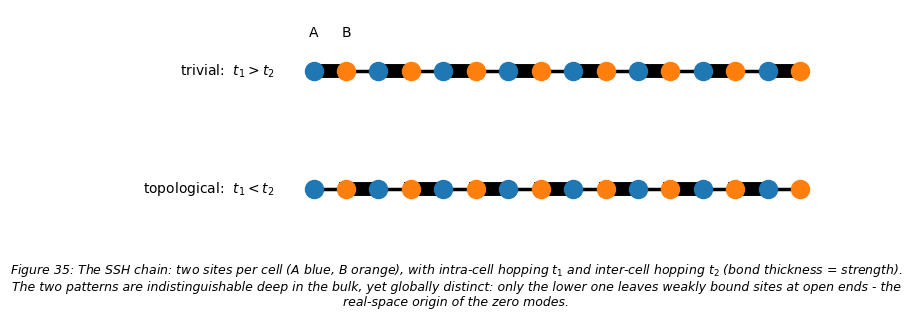

In [33]:
# --- geometry: the two dimerisation patterns of the SSH chain ----------------
import numpy as np
from matplotlib import pyplot

fig, axes = pyplot.subplots(2, 1, figsize=(9, 2.8), sharex=True)
for ax, (t1, t2, label) in zip(axes, [(1.0, 0.5, 'trivial:  $t_1 > t_2$'),
                                      (0.5, 1.0, 'topological:  $t_1 < t_2$')]):
    for n in range(8):
        xA, xB = 2 * n, 2 * n + 1
        ax.plot([xA, xB], [0, 0], 'k-', lw=10 * t1 * t1, solid_capstyle='round')
        if n < 7:
            ax.plot([xB, xB + 1], [0, 0], 'k-', lw=10 * t2 * t2)
        ax.plot(xA, 0, 'o', ms=13, color='C0', zorder=3)
        ax.plot(xB, 0, 'o', ms=13, color='C1', zorder=3)
    ax.text(-1.2, 0, label, va='center', ha='right', fontsize=10)
    ax.set_xlim(-6, 15.5)
    ax.set_ylim(-0.45, 0.75)
    ax.set_axis_off()
axes[0].text(0, .42, 'A', ha='center')
axes[0].text(1, .42, 'B', ha='center')
show_fig(r'The SSH chain: two sites per cell (A blue, B orange), with intra-cell hopping $t_1$ and inter-cell hopping $t_2$ (bond thickness = strength). The two patterns are indistinguishable deep in the bulk, yet globally distinct: only the lower one leaves weakly bound sites at open ends - the real-space origin of the zero modes.')

trivial      t1=1.0 t2=0.5:  winding = 0,  Zak phase = 0.0000 pi
topological  t1=0.5 t2=1.0:  winding = 1,  Zak phase = 1.0000 pi


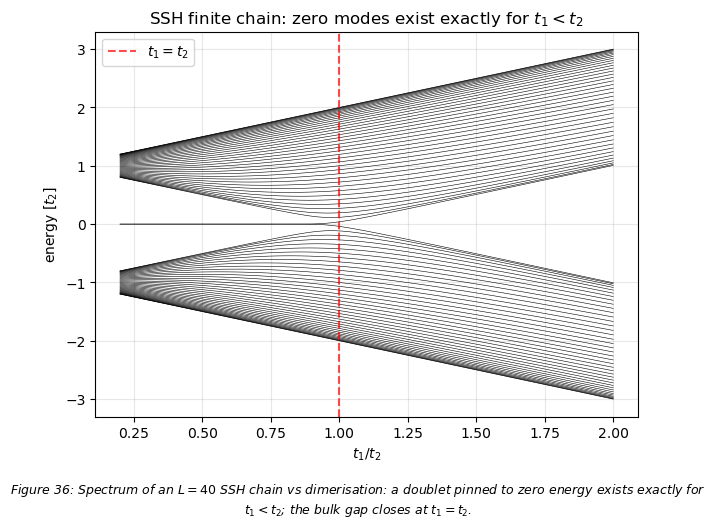

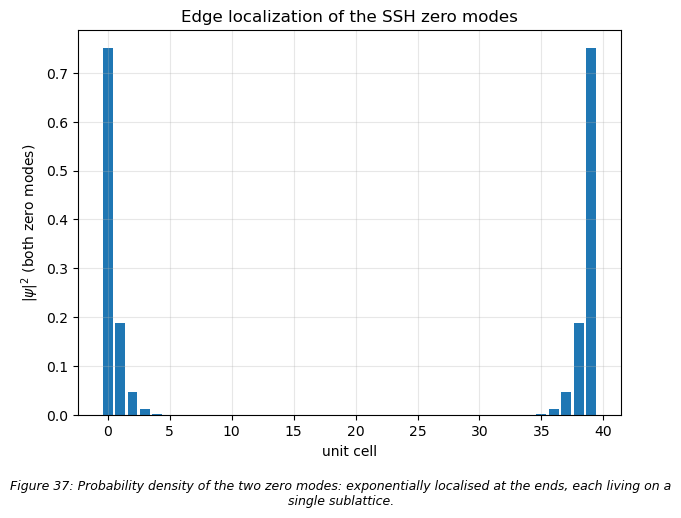

In [34]:
# --- SSH chain: winding number, Zak phase, and the edge-state doublet --------
import kwant, numpy as np
from matplotlib import pyplot

sigma_x = np.array([[0, 1], [1, 0]])
lat = kwant.lattice.chain(norbs=2)              # 2 orbitals = A/B sublattice
hop_inter = np.array([[0.0, 1.0], [0.0, 0.0]])  # B(x) -> A(x+1)

def ssh_chain(t1, t2, L):
    syst = kwant.Builder()
    syst[(lat(x) for x in range(L))] = t1 * sigma_x
    syst[kwant.builder.HoppingKind((1,), lat, lat)] = t2 * hop_inter
    return syst

def winding_number(t1, t2, nk=201):
    ks = np.linspace(0, 2 * np.pi, nk)
    q = t1 + t2 * np.exp(1j * ks)                       # det block of H(k)
    return int(round(np.diff(np.unwrap(np.angle(q))).sum() / (2 * np.pi)))

def zak_phase(t1, t2, nk=200):
    """Berry phase of the filled band: a discrete Wilson loop over the BZ."""
    ks = np.linspace(0, 2 * np.pi, nk, endpoint=False)
    us = []
    for k in ks:
        q = t1 + t2 * np.exp(1j * k)
        h = np.array([[0, q], [np.conj(q), 0]])
        us.append(np.linalg.eigh(h)[1][:, 0])
    prod = 1.0 + 0j
    for i in range(nk):
        prod *= np.vdot(us[i], us[(i + 1) % nk])
    return (-np.angle(prod)) % (2 * np.pi)

for (t1, t2), label in [((1.0, 0.5), "trivial"), ((0.5, 1.0), "topological")]:
    print(f"{label:12s} t1={t1} t2={t2}:  winding = {winding_number(t1, t2)},  "
          f"Zak phase = {zak_phase(t1, t2) / np.pi:.4f} pi")

# spectrum of a finite chain across the transition: watch the zero modes appear
L = 40
ratios = np.linspace(0.2, 2.0, 61)
spectra = []
for r in ratios:                                   # t1/t2 = r at fixed bandwidth
    h = ssh_chain(r, 1.0, L).finalized().hamiltonian_submatrix()
    spectra.append(np.linalg.eigvalsh(h))
spectra = np.array(spectra)

pyplot.plot(ratios, spectra, 'k-', lw=.4)
pyplot.axvline(1.0, color='r', ls='--', alpha=.7, label=r'$t_1 = t_2$')
pyplot.xlabel(r"$t_1 / t_2$"); pyplot.ylabel("energy $[t_2]$")
pyplot.title("SSH finite chain: zero modes exist exactly for $t_1 < t_2$")
pyplot.legend(); pyplot.grid(alpha=.3); show_fig(r'Spectrum of an $L=40$ SSH chain vs dimerisation: a doublet pinned to zero energy exists exactly for $t_1<t_2$; the bulk gap closes at $t_1=t_2$.')

# the zero modes live on the ends, one sublattice each
h = ssh_chain(0.5, 1.0, L).finalized().hamiltonian_submatrix()
ev, vec = np.linalg.eigh(h)
izero = np.argsort(np.abs(ev))[:2]
dens = (np.abs(vec[:, izero]) ** 2).sum(axis=1).reshape(L, 2).sum(axis=1)
pyplot.bar(range(L), dens, color='C0')
pyplot.xlabel("unit cell"); pyplot.ylabel(r"$|\psi|^2$ (both zero modes)")
pyplot.title("Edge localization of the SSH zero modes")
pyplot.grid(alpha=.3); show_fig(r'Probability density of the two zero modes: exponentially localised at the ends, each living on a single sublattice.')

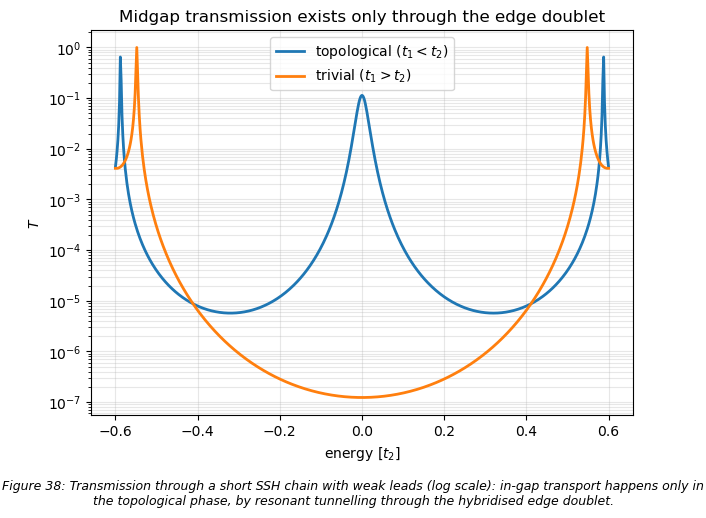

in-gap max T:  topological = 0.1136,  trivial = 6.52e-06


In [35]:
# --- SSH transport: resonant tunnelling through the edge doublet -------------
import kwant, numpy as np
from matplotlib import pyplot

sigma_x = np.array([[0, 1], [1, 0]])
lat = kwant.lattice.chain(norbs=2)
hop_inter = np.array([[0.0, 1.0], [0.0, 0.0]])

def ssh_transport(t1, t2, L=8, t_c=0.15):
    """Short SSH chain, weak links t_c to metallic contacts, uniform-chain leads."""
    syst = kwant.Builder()
    syst[(lat(x) for x in range(L))] = t1 * sigma_x
    syst[kwant.builder.HoppingKind((1,), lat, lat)] = t2 * hop_inter
    syst[lat(-1)] = 1.0 * sigma_x                 # metallic contact cells
    syst[lat(L)] = 1.0 * sigma_x
    syst[lat(0), lat(-1)] = t_c * hop_inter       # the weak links
    syst[lat(L), lat(L - 1)] = t_c * hop_inter
    lead = kwant.Builder(kwant.TranslationalSymmetry((-1,)))
    lead[lat(0)] = 1.0 * sigma_x                  # t1 = t2: gapless = metallic
    lead[kwant.builder.HoppingKind((1,), lat, lat)] = hop_inter
    syst.attach_lead(lead)
    syst.attach_lead(lead.reversed())
    return syst.finalized()

energies = np.linspace(-0.6, 0.6, 601)
T_top = [kwant.smatrix(ssh_transport(0.5, 1.0), e).transmission(1, 0)
         for e in energies]
T_tri = [kwant.smatrix(ssh_transport(1.0, 0.5), e).transmission(1, 0)
         for e in energies]

pyplot.semilogy(energies, T_top, lw=2, label=r"topological ($t_1 < t_2$)")
pyplot.semilogy(energies, T_tri, lw=2, label=r"trivial ($t_1 > t_2$)")
pyplot.xlabel("energy $[t_2]$"); pyplot.ylabel(r"$T$")
pyplot.title("Midgap transmission exists only through the edge doublet")
pyplot.legend(); pyplot.grid(alpha=.3, which='both'); show_fig(r'Transmission through a short SSH chain with weak leads (log scale): in-gap transport happens only in the topological phase, by resonant tunnelling through the hybridised edge doublet.')

gap = np.abs(energies) < 0.4                  # strictly inside both gaps
Tg_top, Tg_tri = np.array(T_top)[gap].max(), np.array(T_tri)[gap].max()
print(f"in-gap max T:  topological = {Tg_top:.4f},  trivial = {Tg_tri:.2e}")
assert Tg_top > 30 * Tg_tri

---
## 18. The Kitaev chain — Majorana zero modes

Kitaev's model [Phys.-Usp. **44**, 131 (2001)] is a spinless 1D $p$-wave
superconductor.  In the BdG basis $(c, c^\dagger)$,

$$H(k) = \underbrace{(-\mu - 2t\cos k)}_{h(k)}\,\tau_z +
         \underbrace{2\Delta \sin k}_{d(k)}\,\tau_y ,$$

with spectrum $E(k) = \pm\sqrt{h^2 + d^2}$.  Particle–hole symmetry
($P = \tau_x K$, $P H(k) P^{-1} = -H(-k)$) protects a $\mathbb{Z}_2$
invariant that only depends on the signs of $h$ at the PH-symmetric momenta:

$$Q = \operatorname{sign}\left[h(0)\,h(\pi)\right] =
\operatorname{sign}\left[\mu^2 - 4t^2\right],$$

so the chain is **topological for $|\mu| < 2t$**.  There it hosts one Majorana
zero mode per end ($\gamma = \gamma^\dagger$), split only by an exponentially
small overlap.

The experimental smoking gun is transport: an electron incident from a normal
lead *must* Andreev-reflect resonantly through the Majorana, pinning the
zero-bias conductance to exactly $2e^2/h$ — independent of the barrier
strength.  This is the cleanest quantization in this notebook after the
conductance staircase of Part I.  (See topocondmat.org, week 1–2.)

**Physics in more depth.**  The chain belongs to class D: only particle-hole
symmetry, giving a $\mathbb{Z}_2$ invariant — the sign of the Pfaffian of
$H(k)$ at the two PH-symmetric momenta, which reduces to the
$\operatorname{sign}[h(0)h(\pi)]$ used below.  What makes Majorana end modes
more than a curiosity is their **non-abelian exchange statistics**: braiding
two of them enacts a unitary rotation in the degenerate ground-state
manifold [Ivanov, PRL **86**, 268 (2001)], the basis of topological quantum
computation proposals [Kitaev, Ann. Phys. **303**, 2 (2003)].  The ZBP
computed below is the transport face of a deeper statement: PH symmetry
forces the reflection matrix determinant to $\pm1$, and the topological
sign pins perfect Andreev reflection at $E=0$.

*Reviews:* Alicea, Rep. Prog. Phys. **75**, 076501 (2012); Beenakker, Annu.
Rev. Condens. Matter Phys. **4**, 113 (2013); Leijnse & Flensberg, Semicond.
Sci. Technol. **27**, 124003 (2012).


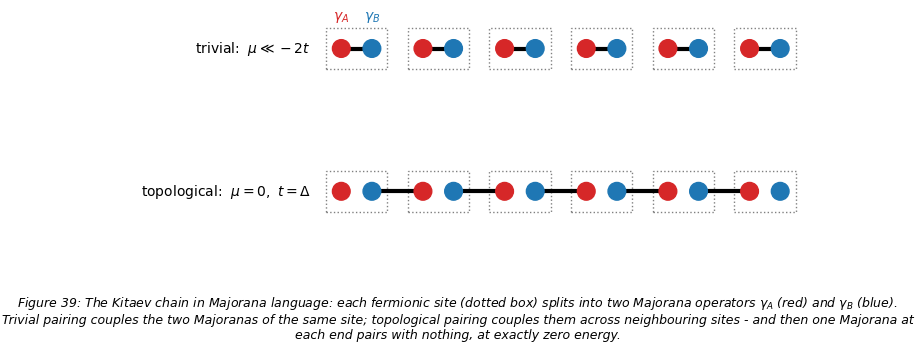

In [36]:
# --- geometry: the Kitaev chain in the Majorana representation ---------------
import numpy as np
from matplotlib import pyplot

fig, axes = pyplot.subplots(2, 1, figsize=(9, 3.4))
for ax, (pair, label) in zip(axes,
                             [('intra', 'trivial:  $\\mu \\ll -2t$'),
                              ('inter', 'topological:  $\\mu = 0,\\ t = \\Delta$')]):
    for n in range(6):
        x = 2.4 * n
        ax.add_patch(pyplot.Rectangle((x - 0.45, -0.6), 1.8, 1.2, fill=False,
                                      ls=':', ec='gray'))
        if pair == 'intra':
            ax.plot([x, x + 0.9], [0, 0], 'k-', lw=3, zorder=2)
        elif n < 5:
            ax.plot([x + 0.9, x + 2.4], [0, 0], 'k-', lw=3, zorder=2)
        ax.add_patch(pyplot.Circle((x, 0), 0.26, color='C3', zorder=3))
        ax.add_patch(pyplot.Circle((x + 0.9, 0), 0.26, color='C0', zorder=3))
    ax.text(-0.9, 0, label, va='center', ha='right', fontsize=10)
    ax.set_xlim(-6.5, 14)
    ax.set_ylim(-1.1, 1.1)
    ax.set_aspect('equal')
    ax.set_axis_off()
axes[0].text(0, 0.85, r'$\gamma_A$', color='C3', ha='center')
axes[0].text(0.9, 0.85, r'$\gamma_B$', color='C0', ha='center')
show_fig(r'The Kitaev chain in Majorana language: each fermionic site (dotted box) splits into two Majorana operators $\gamma_A$ (red) and $\gamma_B$ (blue). Trivial pairing couples the two Majoranas of the same site; topological pairing couples them across neighbouring sites - and then one Majorana at each end pairs with nothing, at exactly zero energy.')

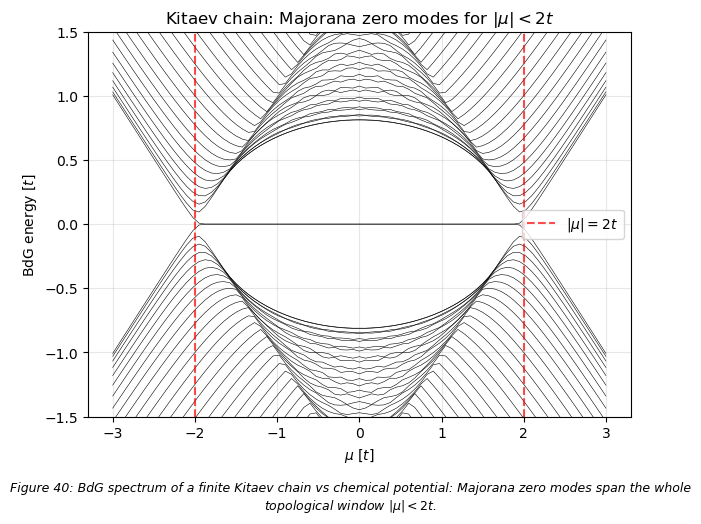

Q(mu=0.5) = -1  (topological);  Q(mu=3.0) = 1  (trivial)
L= 10:  |E_0| = 1.60e-02
L= 20:  |E_0| = 2.06e-04
L= 40:  |E_0| = 1.58e-08


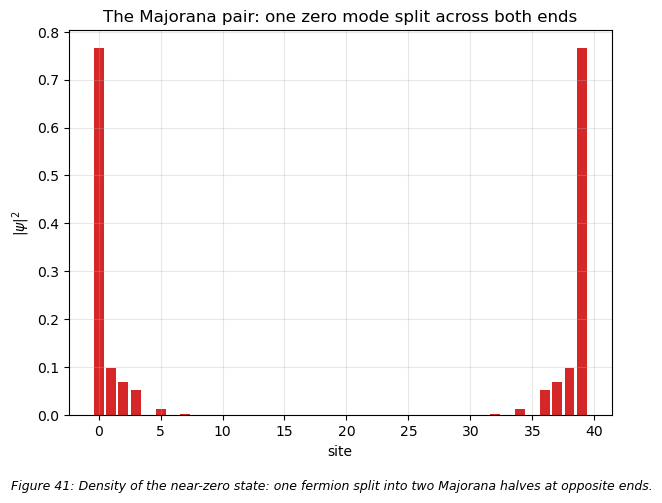

In [37]:
# --- Kitaev chain: phase diagram and Majorana modes ---------------------------
import kwant, numpy as np
from matplotlib import pyplot

tau_y = np.array([[0, -1j], [1j, 0]])
tau_z = np.array([[1, 0], [0, -1]])

t, Delta = 1.0, 0.4
lat = kwant.lattice.chain(norbs=2)          # 2 orbitals = particle, hole

def kitaev_chain(mu, L):
    syst = kwant.Builder()
    syst[(lat(x) for x in range(L))] = -mu * tau_z
    syst[kwant.builder.HoppingKind((1,), lat, lat)] = \
        -t * tau_z - 1j * Delta * tau_y
    return syst

# spectrum of a finite chain vs mu: Majoranas exist exactly for |mu| < 2t
L = 40
mus = np.linspace(-3, 3, 81)
spectra = np.array([np.linalg.eigvalsh(
    kitaev_chain(m, L).finalized().hamiltonian_submatrix()) for m in mus])

pyplot.plot(mus, spectra, 'k-', lw=.4)
pyplot.axvline(-2, color='r', ls='--', alpha=.7)
pyplot.axvline(2, color='r', ls='--', alpha=.7, label=r'$|\mu| = 2t$')
pyplot.ylim(-1.5, 1.5)
pyplot.xlabel(r"$\mu\ [t]$"); pyplot.ylabel("BdG energy $[t]$")
pyplot.title("Kitaev chain: Majorana zero modes for $|\\mu| < 2t$")
pyplot.legend(); pyplot.grid(alpha=.3); show_fig(r'BdG spectrum of a finite Kitaev chain vs chemical potential: Majorana zero modes span the whole topological window $|\mu|<2t$.')

# the Z2 invariant needs only the signs of h(k) at k = 0 and pi
Q = lambda mu: int(np.sign((-mu - 2 * t) * (-mu + 2 * t)))
print("Q(mu=0.5) =", Q(0.5), " (topological);  Q(mu=3.0) =", Q(3.0), " (trivial)")

# exponential protection: the zero-mode splitting vs chain length
for L_ in (10, 20, 40):
    ev = np.linalg.eigvalsh(kitaev_chain(0.5, L_).finalized()
                            .hamiltonian_submatrix())
    print(f"L={L_:3d}:  |E_0| = {np.abs(ev).min():.2e}")

# Majorana wavefunction: half a fermion on each end
h = kitaev_chain(0.5, L).finalized().hamiltonian_submatrix()
ev, vec = np.linalg.eigh(h)
izero = np.argsort(np.abs(ev))[:2]
dens = (np.abs(vec[:, izero]) ** 2).sum(axis=1).reshape(L, 2).sum(axis=1)
pyplot.bar(range(L), dens, color='C3')
pyplot.xlabel("site"); pyplot.ylabel(r"$|\psi|^2$")
pyplot.title("The Majorana pair: one zero mode split across both ends")
pyplot.grid(alpha=.3); show_fig(r'Density of the near-zero state: one fermion split into two Majorana halves at opposite ends.')

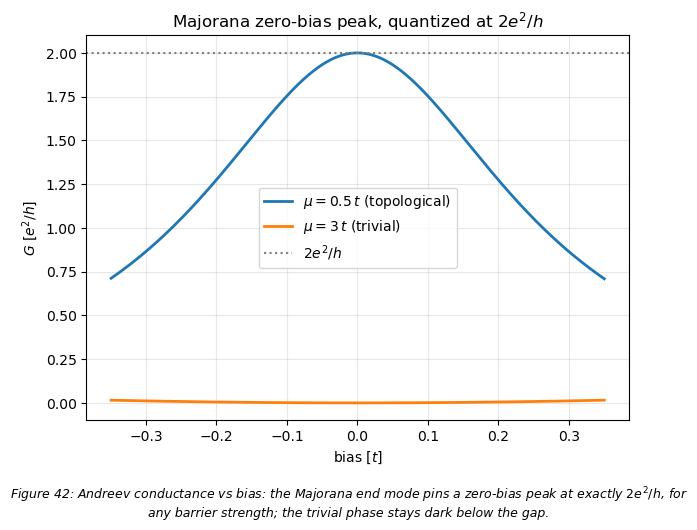

barrier=1.0:  G(V~0) = 2.000000  (pinned to 2 by the Majorana)
barrier=1.6:  G(V~0) = 2.000000  (pinned to 2 by the Majorana)
barrier=2.5:  G(V~0) = 1.999999  (pinned to 2 by the Majorana)


In [38]:
# --- NS junction: the quantized zero-bias peak --------------------------------
import kwant, numpy as np
from matplotlib import pyplot

tau_x = np.array([[0, 1], [1, 0]])
tau_y = np.array([[0, -1j], [1j, 0]])
tau_z = np.array([[1, 0], [0, -1]])
t, Delta = 1.0, 0.4
lat = kwant.lattice.chain(norbs=2)

def ns_kitaev(mu_wire, L=25, mu_lead=1.0, barrier=1.6):
    """normal lead | tunnel barrier | Kitaev chain (far end terminated)."""
    syst = kwant.Builder()
    syst[(lat(x) for x in range(L))] = -mu_wire * tau_z
    syst[kwant.builder.HoppingKind((1,), lat, lat)] = \
        -t * tau_z - 1j * Delta * tau_y
    syst[lat(0)] = (-mu_wire + barrier) * tau_z
    lead = kwant.Builder(kwant.TranslationalSymmetry((-1,)),
                         conservation_law=-tau_z, particle_hole=tau_x)
    lead[lat(0)] = -mu_lead * tau_z
    lead[kwant.builder.HoppingKind((1,), lat, lat)] = -t * tau_z
    syst.attach_lead(lead)
    return syst.finalized()

def andreev_G(fsyst, e):
    """G = N - R_ee + R_he, in units e^2/h (one lead: reflection only)."""
    s = kwant.smatrix(fsyst, e)
    N = s.submatrix((0, 0), (0, 0)).shape[0]
    return N - s.transmission((0, 0), (0, 0)) + s.transmission((0, 1), (0, 0))

# NB: at exactly E = 0 the electron and hole modes of a PH-symmetric lead are
# degenerate and the block labelling is singular -- never evaluate there.
energies = np.linspace(-0.35, 0.35, 281) + 5e-4
G_top = [andreev_G(ns_kitaev(0.5), e) for e in energies]
G_tri = [andreev_G(ns_kitaev(3.0), e) for e in energies]

pyplot.plot(energies, G_top, lw=2, label=r"$\mu = 0.5\,t$ (topological)")
pyplot.plot(energies, G_tri, lw=2, label=r"$\mu = 3\,t$ (trivial)")
pyplot.axhline(2, color='gray', ls=':', label=r'$2e^2/h$')
pyplot.xlabel("bias $[t]$"); pyplot.ylabel(r"$G\ [e^2/h]$")
pyplot.title("Majorana zero-bias peak, quantized at $2e^2/h$")
pyplot.legend(); pyplot.grid(alpha=.3); show_fig(r'Andreev conductance vs bias: the Majorana end mode pins a zero-bias peak at exactly $2e^2/h$, for any barrier strength; the trivial phase stays dark below the gap.')

for barrier in (1.0, 1.6, 2.5):
    G0 = andreev_G(ns_kitaev(0.5, barrier=barrier), 1e-4)
    print(f"barrier={barrier}:  G(V~0) = {G0:.6f}  (pinned to 2 by the Majorana)")
    assert abs(G0 - 2.0) < 1e-3

---
## 19. The Majorana nanowire — Kitaev physics in a real device

No spinless $p$-wave superconductors exist in nature.  Oreg *et al.* [PRL
**105**, 177002 (2010)] and Lutchyn *et al.* [PRL **105**, 077001 (2010)]
showed how to engineer one: a semiconductor wire with Rashba spin–orbit
coupling $\alpha$, proximitized by an $s$-wave superconductor $\Delta$, in a
magnetic field $B$ along the wire.  In the Nambu basis
$(\psi_\uparrow, \psi_\downarrow, \psi_\downarrow^\dagger, -\psi_\uparrow^\dagger)$:

$$H = \left(\frac{k^2}{2m} - \mu + \alpha k \sigma_y\right)\tau_z
      + B\,\sigma_x + \Delta\,\tau_x .$$

The Zeeman term opens a helical gap; pairing then drives the wire into an
effective Kitaev phase when

$$B > B_c = \sqrt{\Delta^2 + \mu^2},$$

with the bulk gap closing and reopening exactly at $B_c$.  The signature is
the same as for the Kitaev chain — a zero-bias conductance peak at $2e^2/h$ —
but now it *emerges as the field is tuned through* $B_c$, which is what the
2012 Delft experiment [Mourik *et al.*, Science **336**, 1003] looked for.
(See topocondmat.org, week 2.)

**Experimental status — read with care.**  The first zero-bias peaks were
reported by Mourik *et al.* [Science **336**, 1003 (2012)] and refined in
hard-gap devices [Deng *et al.*, Science **354**, 1557 (2016)].  But a ZBP
alone is *not* proof of a Majorana: disorder, smooth confinement and Andreev
bound states can all pin peaks near zero bias without any topology — one
prominent "quantised" claim was retracted.  The field's sobering
self-assessment is in Prada *et al.*, Nat. Rev. Phys. **2**, 575 (2020) and
Flensberg, von Oppen & Stern, Nat. Rev. Mater. **6**, 944 (2021); a
measurement protocol that goes beyond single-peak evidence is described in
Microsoft Quantum, PRB **107**, 245423 (2023).  Simulations like the one
below are the baseline against which such claims are judged.


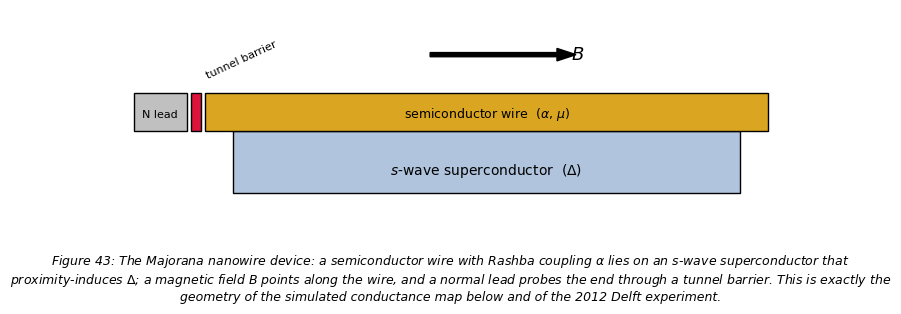

In [39]:
# --- geometry: the hybrid nanowire device ------------------------------------
from matplotlib import pyplot
from matplotlib.patches import FancyArrow, Rectangle

fig, ax = pyplot.subplots(figsize=(9, 2.7))
ax.add_patch(Rectangle((1.4, 0.35), 7.2, 0.9, fc='#b0c4de', ec='k'))
ax.add_patch(Rectangle((1.0, 1.25), 8.0, 0.55, fc='#daa520', ec='k'))
ax.add_patch(Rectangle((0.0, 1.25), 0.75, 0.55, fc='#c0c0c0', ec='k'))
ax.add_patch(Rectangle((0.80, 1.25), 0.15, 0.55, fc='crimson', ec='k'))
ax.add_patch(FancyArrow(4.2, 2.35, 1.8, 0, width=0.06, color='k'))
ax.text(6.2, 2.35, '$B$', fontsize=13, va='center')
ax.text(5.0, 0.62, r'$s$-wave superconductor  ($\Delta$)', ha='center')
ax.text(5.0, 1.44, r'semiconductor wire  ($\alpha$, $\mu$)',
        ha='center', fontsize=9)
ax.text(0.37, 1.44, 'N lead', ha='center', fontsize=8)
ax.text(1.0, 2.0, 'tunnel barrier', fontsize=8, rotation=25)
ax.set_xlim(-0.3, 9.6)
ax.set_ylim(0, 3.0)
ax.set_axis_off()
show_fig(r'The Majorana nanowire device: a semiconductor wire with Rashba coupling $\alpha$ lies on an s-wave superconductor that proximity-induces $\Delta$; a magnetic field B points along the wire, and a normal lead probes the end through a tunnel barrier. This is exactly the geometry of the simulated conductance map below and of the 2012 Delft experiment.')

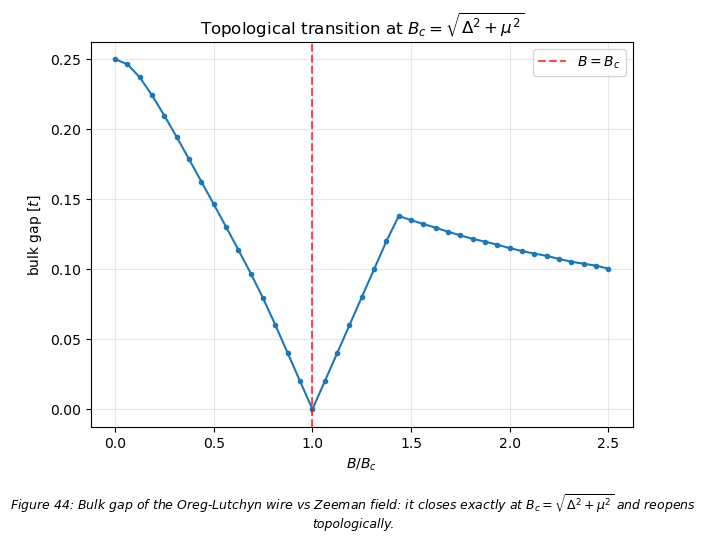

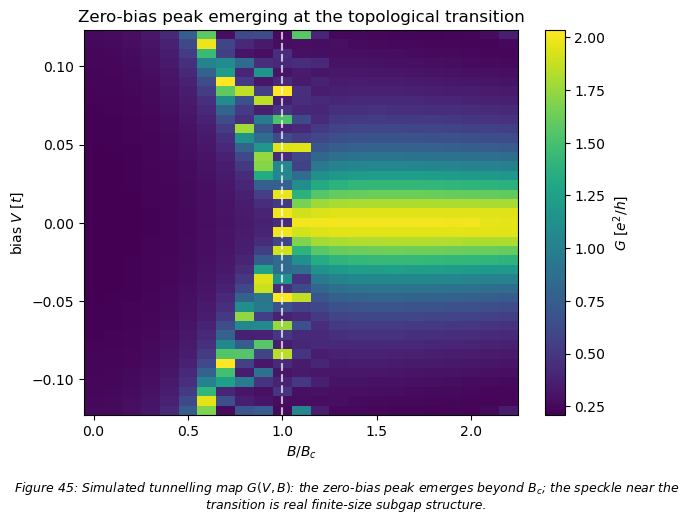

G(V~0):  B=0.5 B_c -> 0.251;   B=1.8 B_c -> 2.0000  (2 = Majorana)


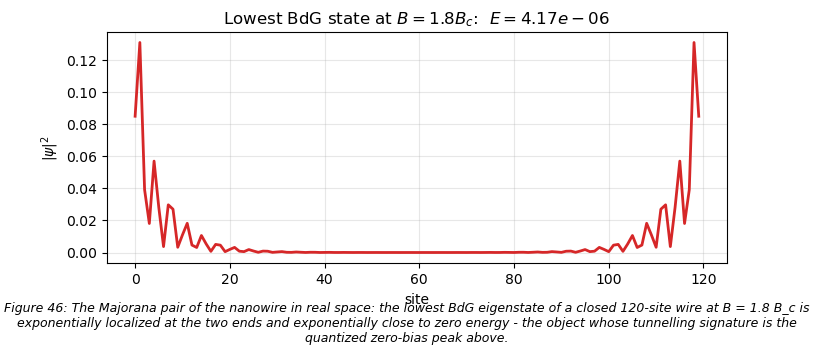

In [40]:
# --- Majorana nanowire: gap closing at B_c and the emerging ZBP ---------------
import kwant, numpy as np
from matplotlib import pyplot

s0 = np.eye(2)
sx = np.array([[0, 1], [1, 0]])
sy = np.array([[0, -1j], [1j, 0]])
sz = np.array([[1, 0], [0, -1]])
k4 = np.kron

t, alpha, Delta, mu = 1.0, 0.4, 0.25, 0.2
Bc = np.hypot(Delta, mu)
lat = kwant.lattice.chain(norbs=4)          # (up, dn) x (particle, hole)

def onsite(B):
    return (2 * t - mu) * k4(sz, s0) + B * k4(np.eye(2), sx) + Delta * k4(sx, s0)

hopping = -t * k4(sz, s0) + 0.5j * alpha * k4(sz, sy)

def wire_lead(B):
    lead = kwant.Builder(kwant.TranslationalSymmetry((-1,)))
    lead[lat(0)] = onsite(B)
    lead[kwant.builder.HoppingKind((1,), lat, lat)] = hopping
    return lead

# (a) bulk gap vs B: closes exactly at B_c = sqrt(Delta^2 + mu^2)
Bs = np.linspace(0, 2.5 * Bc, 41)
ks = np.linspace(0, np.pi, 201)
gaps = []
for B in Bs:
    bands = kwant.physics.Bands(wire_lead(B).finalized())
    gaps.append(min(np.abs(bands(k)).min() for k in ks))

pyplot.plot(Bs / Bc, gaps, 'o-', ms=3)
pyplot.axvline(1, color='r', ls='--', alpha=.7, label=r'$B = B_c$')
pyplot.xlabel(r"$B / B_c$"); pyplot.ylabel("bulk gap $[t]$")
pyplot.title(r"Topological transition at $B_c=\sqrt{\Delta^2+\mu^2}$")
pyplot.legend(); pyplot.grid(alpha=.3); show_fig(r'Bulk gap of the Oreg-Lutchyn wire vs Zeeman field: it closes exactly at $B_c=\sqrt{\Delta^2+\mu^2}$ and reopens topologically.')

# (b) tunneling conductance map G(V, B): the ZBP appears only above B_c
def ns_wire(B, L=70, barrier=1.2, mu_lead=1.5):
    syst = kwant.Builder()
    syst[(lat(x) for x in range(L))] = onsite(B)
    syst[kwant.builder.HoppingKind((1,), lat, lat)] = hopping
    syst[lat(0)] = onsite(B) + barrier * k4(sz, s0)
    lead = kwant.Builder(kwant.TranslationalSymmetry((-1,)),
                         conservation_law=-k4(sz, s0))
    lead[lat(0)] = (2 * t - mu_lead) * k4(sz, s0) + B * k4(np.eye(2), sx)
    lead[kwant.builder.HoppingKind((1,), lat, lat)] = -t * k4(sz, s0)
    syst.attach_lead(lead)
    return syst.finalized()

def andreev_G(fsyst, e):
    s = kwant.smatrix(fsyst, e)
    N = s.submatrix((0, 0), (0, 0)).shape[0]
    return N - s.transmission((0, 0), (0, 0)) + s.transmission((0, 1), (0, 0))

Bs_map = np.linspace(0, 2.2 * Bc, 23)
Vs = np.linspace(-0.12, 0.12, 41) + 2e-4
Gmap = np.array([[andreev_G(ns_wire(B), V) for B in Bs_map] for V in Vs])

pyplot.pcolormesh(Bs_map / Bc, Vs, Gmap, shading='auto', cmap='viridis')
pyplot.colorbar(label=r"$G\ [e^2/h]$")
pyplot.axvline(1, color='w', ls='--', alpha=.7)
pyplot.xlabel(r"$B/B_c$"); pyplot.ylabel("bias $V$ $[t]$")
pyplot.title("Zero-bias peak emerging at the topological transition")
show_fig(r'Simulated tunnelling map $G(V,B)$: the zero-bias peak emerges beyond $B_c$; the speckle near the transition is real finite-size subgap structure.')

G_below = andreev_G(ns_wire(0.5 * Bc), 1e-4)
G_above = andreev_G(ns_wire(1.8 * Bc), 1e-4)
print(f"G(V~0):  B=0.5 B_c -> {G_below:.3f};   B=1.8 B_c -> {G_above:.4f}  (2 = Majorana)")
assert abs(G_above - 2.0) < 0.05

# the Majorana pair in real space: lowest BdG state of a long closed wire
L_mzm = 120
wire_cl = kwant.Builder()
wire_cl[(lat(x) for x in range(L_mzm))] = onsite(1.8 * Bc)
wire_cl[kwant.builder.HoppingKind((1,), lat, lat)] = hopping
evw, vecw = np.linalg.eigh(wire_cl.finalized().hamiltonian_submatrix())
i0 = np.argmin(np.abs(evw))
dens_mzm = (np.abs(vecw[:, i0]) ** 2).reshape(L_mzm, 4).sum(axis=1)
pyplot.figure(figsize=(8, 3))
pyplot.plot(dens_mzm, lw=2, color='C3')
pyplot.xlabel('site'); pyplot.ylabel(r'$|\psi|^2$')
pyplot.title(f'Lowest BdG state at $B = 1.8B_c$:  $E = {evw[i0]:.2e}$')
pyplot.grid(alpha=.3)
show_fig(r'The Majorana pair of the nanowire in real space: the lowest BdG eigenstate of a closed 120-site wire at B = 1.8 B_c is exponentially localized at the two ends and exponentially close to zero energy - the object whose tunnelling signature is the quantized zero-bias peak above.')

---
## 20. The Thouless pump — a Chern number in (k, t)

Thouless [PRB **27**, 6083 (1983)]: slide a periodic potential adiabatically
by one period and the charge transported through a filled band is *exactly
quantized* — it is the Chern number of the band over the $(k, \varphi)$ torus,
where $\varphi$ is the pump phase.  Time acts as a second momentum: **a 1D
pump is a 2D Chern insulator in disguise**.

The minimal realization is the Rice–Mele model — an SSH chain whose
dimerization $\delta$ and staggered onsite $\Delta$ trace a loop:

$$t_{1,2} = t_0 \pm \delta_0\cos\varphi, \qquad
\Delta(\varphi) = \Delta_0 \sin\varphi .$$

The loop encircles the gapless point $(\delta, \Delta) = (0, 0)$, so $C = \pm 1$:
one electron pumped per cycle.  Three equivalent diagnostics, all computed
below:

1. the FHS Chern number on the $(k, \varphi)$ torus (this is where the
   `chern_fhs` routine used throughout Part II first appears);
2. the polarization (Zak phase) winding exactly once per cycle;
3. edge states in a finite chain traversing the gap as $\varphi$ advances —
   the real-space picture of the pumped charge.

*Experiments:* quantised Thouless pumping was finally realised three decades
after the proposal, with ultracold fermions [Nakajima *et al.*, Nat. Phys.
**12**, 296 (2016)] and bosons [Lohse *et al.*, Nat. Phys. **12**, 350
(2016)] in modulated optical superlattices; see Citro & Aidelsburger, Nat.
Rev. Phys. **5**, 87 (2023) for a review.  The same Wilson-loop
(polarization) technology used here reappears in §24 as the nested Wilson
loop of higher-order topology.


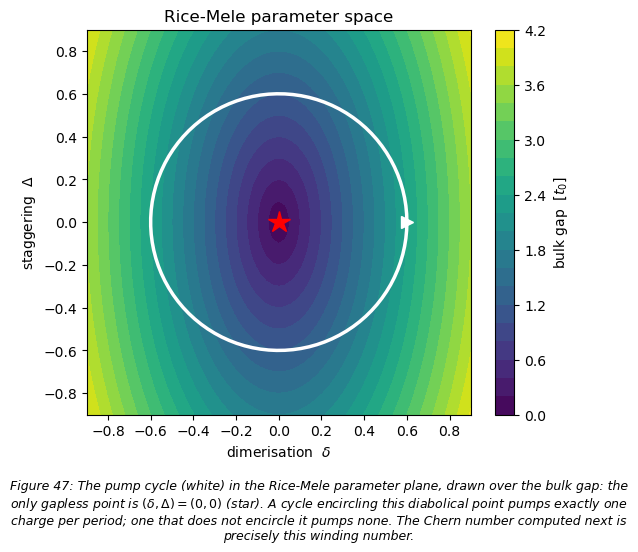

In [41]:
# --- geometry: the pump cycle in parameter space -----------------------------
import numpy as np
from matplotlib import pyplot

t0_, nk = 1.0, 121
deltas = np.linspace(-0.9, 0.9, 61)
Ds = np.linspace(-0.9, 0.9, 61)
ks = np.linspace(0, 2 * np.pi, nk)
gap = np.zeros((len(Ds), len(deltas)))
for i, D in enumerate(Ds):
    for j, de in enumerate(deltas):
        q = (t0_ + de) + (t0_ - de) * np.exp(1j * ks)
        gap[i, j] = 2 * np.min(np.sqrt(np.abs(q) ** 2 + D ** 2))
pyplot.figure(figsize=(6.2, 5))
pyplot.contourf(deltas, Ds, gap, 25, cmap='viridis')
pyplot.colorbar(label='bulk gap  $[t_0]$')
phi = np.linspace(0, 2 * np.pi, 100)
pyplot.plot(0.6 * np.cos(phi), 0.6 * np.sin(phi), 'w-', lw=2.5)
pyplot.plot([0.6], [0], 'w>', ms=9)
pyplot.plot(0, 0, 'r*', ms=16)
pyplot.xlabel(r'dimerisation  $\delta$')
pyplot.ylabel(r'staggering  $\Delta$')
pyplot.title('Rice-Mele parameter space')
show_fig(r'The pump cycle (white) in the Rice-Mele parameter plane, drawn over the bulk gap: the only gapless point is $(\delta,\Delta)=(0,0)$ (star). A cycle encircling this diabolical point pumps exactly one charge per period; one that does not encircle it pumps none. The Chern number computed next is precisely this winding number.')

charge pumped per cycle = C over the (k, phi) torus = -1
cycle without onsite modulation: 0


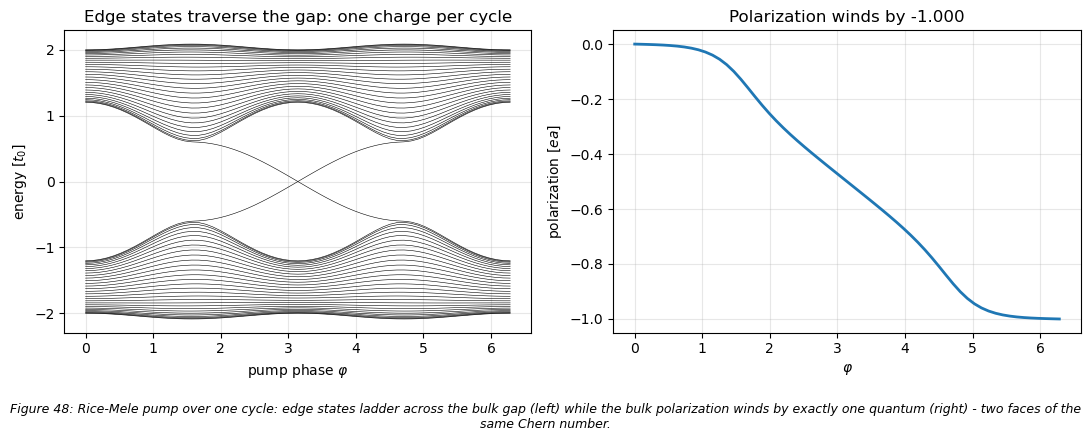

In [42]:
# --- Rice-Mele pump: Chern number, polarization flow, edge-state ladder -------
import kwant, numpy as np
from matplotlib import pyplot

sigma_x = np.array([[0, 1], [1, 0]])
sigma_z = np.array([[1, 0], [0, -1]])
t0, d0, D0 = 1.0, 0.6, 0.6

def h_rice_mele(k, phi):
    t1 = t0 + d0 * np.cos(phi)
    t2 = t0 - d0 * np.cos(phi)
    D = D0 * np.sin(phi)
    q = t1 + t2 * np.exp(1j * k)
    return np.array([[D, q], [np.conj(q), -D]])

def chern_fhs(hfunc, n_occ, n1=40, n2=40):
    """Chern number by the Fukui-Hatsugai-Suzuki plaquette method.

    hfunc(x1, x2): Bloch Hamiltonian, 2pi-periodic in both arguments.  The
    result is exactly integer on any grid fine enough to resolve the gap.
    (Reused by every 2D section below.)
    """
    xs1 = np.linspace(0, 2 * np.pi, n1, endpoint=False)
    xs2 = np.linspace(0, 2 * np.pi, n2, endpoint=False)
    frames = np.empty((n1, n2), dtype=object)
    for i, x1 in enumerate(xs1):
        for j, x2 in enumerate(xs2):
            frames[i, j] = np.linalg.eigh(hfunc(x1, x2))[1][:, :n_occ]
    link = lambda a, b: np.linalg.det(a.conj().T @ b)
    F = 0.0
    for i in range(n1):
        for j in range(n2):
            u1 = link(frames[i, j], frames[(i+1) % n1, j])
            u2 = link(frames[(i+1) % n1, j], frames[(i+1) % n1, (j+1) % n2])
            u3 = link(frames[(i+1) % n1, (j+1) % n2], frames[i, (j+1) % n2])
            u4 = link(frames[i, (j+1) % n2], frames[i, j])
            F += np.angle(u1 * u2 * u3 * u4)
    return int(round(F / (2 * np.pi)))

C = chern_fhs(h_rice_mele, n_occ=1)
print(f"charge pumped per cycle = C over the (k, phi) torus = {C}")
assert abs(C) == 1

# a cycle that does NOT encircle the gapless point pumps nothing
def h_no_pump(k, phi):
    t1 = t0 + d0 * np.cos(phi)
    t2 = t0 - d0 * np.cos(phi)
    q = t1 + t2 * np.exp(1j * k)
    return np.array([[0, q], [np.conj(q), 0]])
print("cycle without onsite modulation:", chern_fhs(h_no_pump, n_occ=1))

# polarization (Zak phase) winds once per cycle -- same integer
def zak(phi, nk=200):
    ks = np.linspace(0, 2 * np.pi, nk, endpoint=False)
    us = [np.linalg.eigh(h_rice_mele(k, phi))[1][:, 0] for k in ks]
    prod = 1.0 + 0j
    for i in range(nk):
        prod *= np.vdot(us[i], us[(i + 1) % nk])
    return -np.angle(prod) / (2 * np.pi)

phis = np.linspace(0, 2 * np.pi, 61)
pol = np.unwrap([2 * np.pi * zak(p) for p in phis]) / (2 * np.pi)

# finite chain: the edge-state ladder carries the charge across the gap
lat = kwant.lattice.chain(norbs=2)
L = 30
def finite_chain(phi):
    t1 = t0 + d0 * np.cos(phi); t2 = t0 - d0 * np.cos(phi)
    D = D0 * np.sin(phi)
    syst = kwant.Builder()
    syst[(lat(x) for x in range(L))] = D * sigma_z + t1 * sigma_x
    syst[kwant.builder.HoppingKind((1,), lat, lat)] = \
        t2 * np.array([[0, 1], [0, 0]])
    return syst.finalized()

spectra = np.array([np.linalg.eigvalsh(finite_chain(p).hamiltonian_submatrix())
                    for p in phis])

fig, (ax1, ax2) = pyplot.subplots(1, 2, figsize=(11, 4))
ax1.plot(phis, spectra, 'k-', lw=.4)
ax1.set_xlabel(r"pump phase $\varphi$"); ax1.set_ylabel("energy $[t_0]$")
ax1.set_title("Edge states traverse the gap: one charge per cycle")
ax1.grid(alpha=.3)
ax2.plot(phis, pol, lw=2)
ax2.set_xlabel(r"$\varphi$"); ax2.set_ylabel("polarization $[ea]$")
ax2.set_title(f"Polarization winds by {pol[-1] - pol[0]:+.3f}")
ax2.grid(alpha=.3)
pyplot.tight_layout(); show_fig(r'Rice-Mele pump over one cycle: edge states ladder across the bulk gap (left) while the bulk polarization winds by exactly one quantum (right) - two faces of the same Chern number.')

assert abs(abs(pol[-1] - pol[0]) - 1) < 0.02

---
## 21. The Haldane model — a Chern insulator without Landau levels

Haldane [PRL **61**, 2015 (1988)] showed that the quantum Hall effect needs no
net magnetic field — only broken time-reversal symmetry.  Take graphene, add a
staggered sublattice potential $\pm M$ and complex second-neighbour hoppings
$t_2 e^{\pm i\phi}$ (the sign set by the chirality of the path):

$$H = t_1\!\!\sum_{\langle ij\rangle}\! c_i^\dagger c_j
    + t_2\!\!\sum_{\langle\langle ij\rangle\rangle}\!\! e^{i\nu_{ij}\phi}\, c_i^\dagger c_j
    + M\sum_i \xi_i\, c_i^\dagger c_i .$$

The phase diagram in $(\phi, M/t_2)$ contains lobes with Chern number
$C = \pm 1$ bounded by $|M| = 3\sqrt{3}\, t_2 \sin\phi$.  Consequences, all
verified below:

* $C$ computed by the FHS formula jumps between $0$ and $\pm 1$ exactly at the
  predicted boundary;
* a ribbon carries one **chiral** edge mode per edge crossing the bulk gap;
* the two-terminal conductance is quantized at $C\,e^2/h$ and — because a
  chiral mode has no backward channel to scatter into — *completely immune to
  disorder*.

(See topocondmat.org week 4; PythTB's `haldane_bp` example computes the same
Berry curvature.)

**Physics in more depth.**  Haldane's point was conceptual: the quantum Hall
effect requires broken time reversal, *not* a net magnetic field — Landau
levels are sufficient, never necessary.  The staggered flux enters only
through the phases $t_2e^{\pm i\phi}$; each hexagon still encloses zero
total flux.  At $M=0$, $\phi=0$ the model is graphene with two Dirac
points; the $M$ term gaps them with the *same* mass sign (trivial), the
$\phi$ term with *opposite* signs (topological) — the phase boundary is
where one Dirac mass changes sign, which is why it is $|M| =
3\sqrt{3}t_2\sin\phi$.

*Experiments:* the "quantum anomalous Hall effect" this model predicts was
observed in magnetically doped topological-insulator films [Chang *et al.*,
Science **340**, 167 (2013)], and the Haldane model itself was engineered
with shaken optical lattices [Jotzu *et al.*, Nature **515**, 237 (2014)].
See Haldane's Nobel lecture, RMP **89**, 040502 (2017).


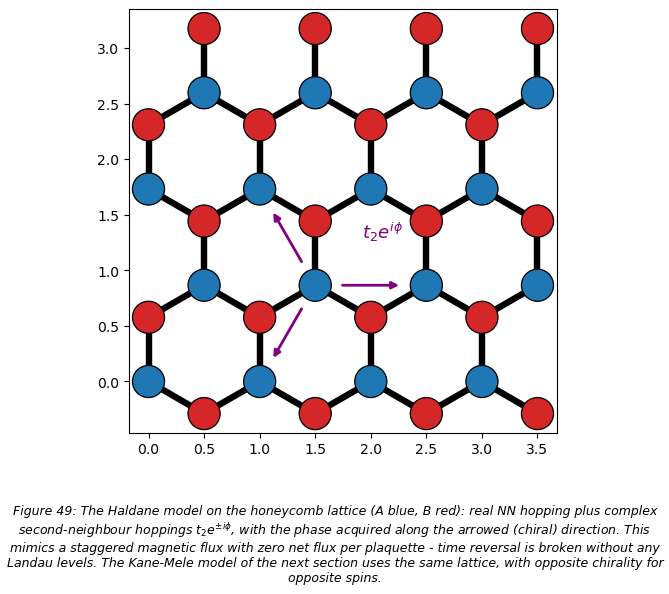

In [43]:
# --- geometry: honeycomb lattice with chiral second-neighbour hoppings -------
import kwant, numpy as np
from matplotlib import pyplot

lat_h = kwant.lattice.honeycomb(norbs=1)
asub, bsub = lat_h.sublattices
fl = kwant.Builder()
fl[lat_h.shape(lambda p: -0.5 < p[0] < 3.6 and -0.4 < p[1] < 3.2, (1, 1))] = 0
fl[lat_h.neighbors()] = -1
fig = kwant.plot(fl,
                 site_color=lambda s: '#1f77b4' if s.family == asub else '#d62728',
                 site_lw=0.02, fig_size=(6.5, 5.5), show=False)
ax = fig.get_axes()[0]
c = np.array(asub(1, 1).pos)
for v in [(1, 0), (-1, 1), (0, -1)]:
    d = np.array(asub(1 + v[0], 1 + v[1]).pos) - c
    ax.annotate('', xy=c + 0.78 * d, xytext=c + 0.22 * d,
                arrowprops=dict(arrowstyle='-|>', color='purple', lw=2))
ax.annotate(r'$t_2 e^{i\phi}$', xy=c + np.array([0.42, 0.42]),
            color='purple', fontsize=13)
show_fig(r'The Haldane model on the honeycomb lattice (A blue, B red): real NN hopping plus complex second-neighbour hoppings $t_2 e^{\pm i\phi}$, with the phase acquired along the arrowed (chiral) direction. This mimics a staggered magnetic flux with zero net flux per plaquette - time reversal is broken without any Landau levels. The Kane-Mele model of the next section uses the same lattice, with opposite chirality for opposite spins.')

M= 0.00, phi=+1.57:  C = +1   (centre of the C=+1 lobe)


M= 1.01, phi=+1.57:  C = +0   (above the lobe)


M= 0.00, phi=-1.57:  C = -1   (opposite chirality)


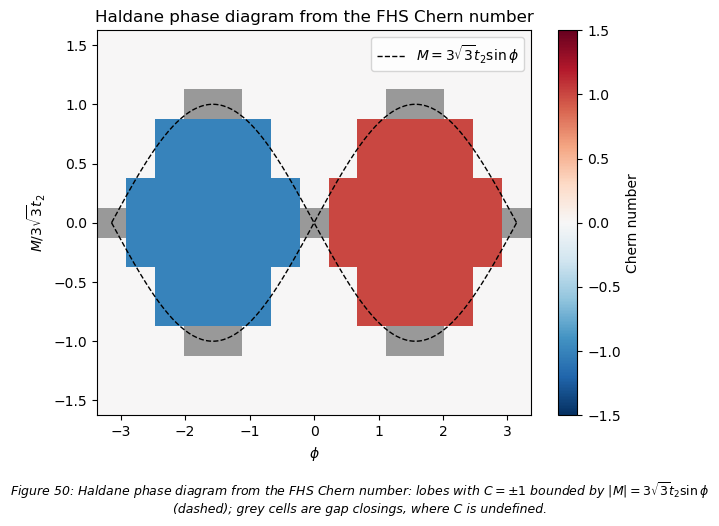

In [44]:
# --- Haldane model: Bloch Hamiltonian from kwant + Chern phase diagram --------
import kwant, kwant.wraparound, numpy as np
from matplotlib import pyplot

t1_h, t2_h = 1.0, 0.15
lat = kwant.lattice.honeycomb(norbs=1)
a_sub, b_sub = lat.sublattices
nnn_a = [kwant.builder.HoppingKind(v, a_sub, a_sub)
         for v in [(1, 0), (-1, 1), (0, -1)]]      # one chirality class
nnn_b = [kwant.builder.HoppingKind(v, b_sub, b_sub)
         for v in [(1, 0), (-1, 1), (0, -1)]]

def haldane_bulk(M, phi):
    syst = kwant.Builder(kwant.TranslationalSymmetry(*lat.prim_vecs))
    syst[a_sub(0, 0)] = M
    syst[b_sub(0, 0)] = -M
    syst[lat.neighbors()] = t1_h
    for kind in nnn_a:
        syst[kind] = t2_h * np.exp(1j * phi)
    for kind in nnn_b:
        syst[kind] = t2_h * np.exp(-1j * phi)
    return syst

def bloch_hamiltonian(bulk_builder, prim_vecs):
    """H(theta1, theta2), theta_i = phase across primitive vector i.

    Works for any 2D lattice: wraparound gives H(k) in Cartesian momenta;
    mapping through the reciprocal vectors makes it 2pi-periodic in theta,
    which is what chern_fhs (section 20) expects.
    """
    wrapped = kwant.wraparound.wraparound(bulk_builder).finalized()
    b1, b2 = 2 * np.pi * np.linalg.inv(np.array(prim_vecs)).T
    def hfunc(th1, th2):
        k = (th1 * b1 + th2 * b2) / (2 * np.pi)
        return wrapped.hamiltonian_submatrix(params=dict(k_x=k[0], k_y=k[1]))
    return hfunc

Mc = 3 * np.sqrt(3) * t2_h
for M, phi, label in [(0.0, np.pi / 2, "centre of the C=+1 lobe"),
                      (1.3 * Mc, np.pi / 2, "above the lobe"),
                      (0.0, -np.pi / 2, "opposite chirality")]:
    C = chern_fhs(bloch_hamiltonian(haldane_bulk(M, phi), lat.prim_vecs),
                  n_occ=1, n1=24, n2=24)
    print(f"M={M:5.2f}, phi={phi:+.2f}:  C = {C:+d}   ({label})")

# the celebrated phase diagram, computed pointwise.  Two numerical caveats:
# the FHS grid must resolve the Berry-curvature hotspots at K and K' (16x16
# is NOT enough at M=0 -- it returns 0 there; 24x24 is), and at gapless
# points the Chern number is undefined, so mask them out.
def direct_gap(M, phi, n=30):
    # Two subtleties.  (1) Use the DIRECT gap E2(k)-E1(k), not min|E|: the
    # NNN term carries a sigma_0 offset that pushes bands through E=0 without
    # closing the direct gap, and only the direct gap matters for the Chern
    # number.  (2) A coarse k-grid can miss the Dirac point entirely (pure
    # graphene "shows" a gap of 0.15 on a 30x30 grid!), so refine locally
    # around the coarse minimum.
    hf = bloch_hamiltonian(haldane_bulk(M, phi), lat.prim_vecs)
    ks = np.linspace(0, 2 * np.pi, n, endpoint=False)
    gaps = np.array([[np.diff(np.linalg.eigvalsh(hf(x1, x2)))[0]
                      for x2 in ks] for x1 in ks])
    i, j = np.unravel_index(gaps.argmin(), gaps.shape)
    fine = np.linspace(-2 * np.pi / n, 2 * np.pi / n, 15)
    return min(np.diff(np.linalg.eigvalsh(hf(ks[i] + dx, ks[j] + dy)))[0]
               for dx in fine for dy in fine)

phis = np.linspace(-np.pi, np.pi, 15)
Ms = np.linspace(-1.5 * Mc, 1.5 * Mc, 13)
Cmap = np.full((len(Ms), len(phis)), np.nan)
for i, M in enumerate(Ms):
    for j, phi in enumerate(phis):
        if direct_gap(M, phi) > 0.05:
            Cmap[i, j] = chern_fhs(bloch_hamiltonian(haldane_bulk(M, phi),
                                                     lat.prim_vecs),
                                   n_occ=1, n1=24, n2=24)

cmap = pyplot.get_cmap('RdBu_r').copy()
cmap.set_bad('0.6')                       # grey = gap closed, C undefined
pyplot.pcolormesh(phis, Ms / Mc, Cmap, shading='auto', cmap=cmap,
                  vmin=-1.5, vmax=1.5)
pyplot.colorbar(label="Chern number")
ph = np.linspace(-np.pi, np.pi, 200)
pyplot.plot(ph, np.sin(ph) * np.ones_like(ph) * 1.0, 'k--', lw=1,
            label=r"$M = 3\sqrt{3}t_2\sin\phi$")
pyplot.plot(ph, -np.sin(ph), 'k--', lw=1)
pyplot.xlabel(r"$\phi$"); pyplot.ylabel(r"$M / 3\sqrt{3}t_2$")
pyplot.title("Haldane phase diagram from the FHS Chern number")
pyplot.legend(loc='upper right'); show_fig(r'Haldane phase diagram from the FHS Chern number: lobes with $C=\pm1$ bounded by $|M|=3\sqrt{3}t_2\sin\phi$ (dashed); grey cells are gap closings, where C is undefined.')

topological ($M = 0$):  $C = 1$:  integrated curvature / 2pi = +1.0000


trivial ($M = 1.3 M_c$):  $C = 0$:  integrated curvature / 2pi = -0.0000


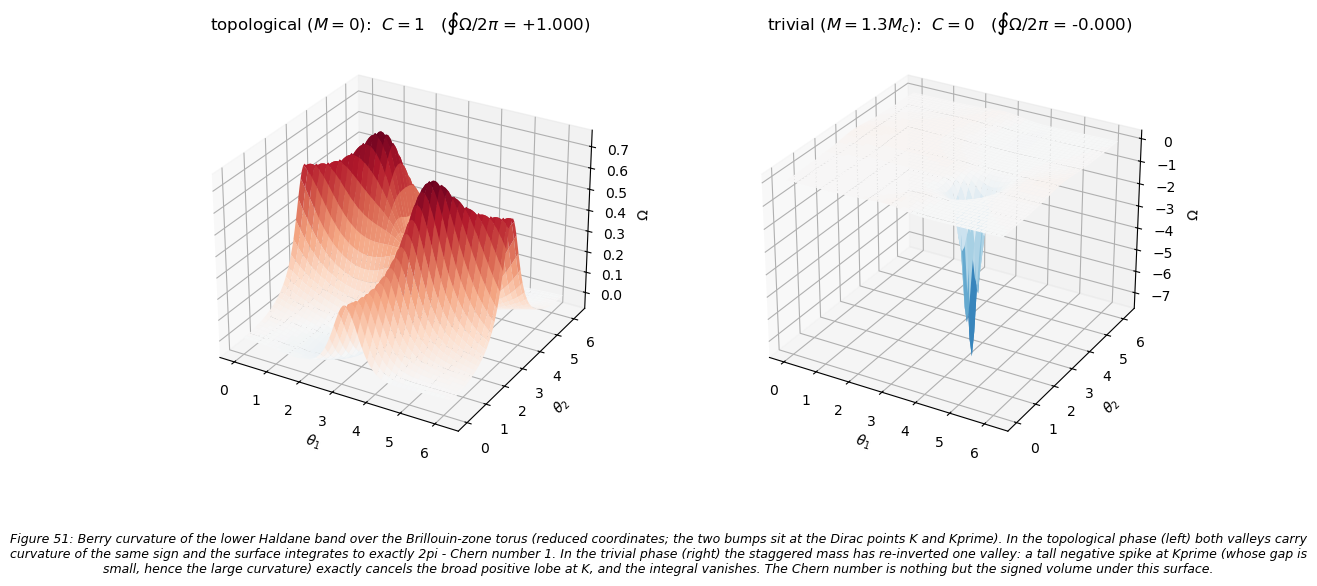

In [45]:
# --- Berry curvature of the Haldane model in 3D -------------------------------
# The Chern number is the integral of the Berry curvature over the BZ; here is
# the integrand itself, from the same plaquette construction as chern_fhs.
#
# One subtlety uncovered while writing this cell: kwant.wraparound's momenta
# k_x, k_y ARE the phases across the two primitive vectors (2pi-periodic as
# they stand).  The reciprocal-vector reparametrization used for the Chern
# numbers above is fine for the TOTAL flux (the loop closes combinatorially),
# but it is not 2pi-periodic point by point, which would contaminate the local
# curvature density along the torus seam.  So here we feed wraparound its own
# native coordinates.
def berry_curvature(bulk_builder, n=90):
    """Berry curvature density of the lowest band on the (theta1, theta2) torus."""
    w = kwant.wraparound.wraparound(bulk_builder).finalized()
    hf = lambda t1, t2: w.hamiltonian_submatrix(params=dict(k_x=t1, k_y=t2))
    th = np.linspace(0, 2 * np.pi, n, endpoint=False)
    u = np.empty((n, n), dtype=object)
    for a in range(n):
        for b in range(n):
            u[a, b] = np.linalg.eigh(hf(th[a], th[b]))[1][:, 0]
    F = np.zeros((n, n))
    for a in range(n):
        for b in range(n):
            F[a, b] = np.angle(
                np.vdot(u[a, b], u[(a + 1) % n, b]) *
                np.vdot(u[(a + 1) % n, b], u[(a + 1) % n, (b + 1) % n]) *
                np.vdot(u[(a + 1) % n, (b + 1) % n], u[a, (b + 1) % n]) *
                np.vdot(u[a, (b + 1) % n], u[a, b]))
    return th, F / (2 * np.pi / n) ** 2

fig = pyplot.figure(figsize=(13, 5.5))
for panel, (M, phi, label) in enumerate(
        [(0.0, np.pi / 2, r'topological ($M = 0$):  $C = 1$'),
         (1.3 * Mc, np.pi / 2, r'trivial ($M = 1.3 M_c$):  $C = 0$')]):
    th, Omega = berry_curvature(haldane_bulk(M, phi))
    C_int = Omega.sum() * (2 * np.pi / len(th)) ** 2 / (2 * np.pi)
    T1, T2 = np.meshgrid(th, th, indexing='ij')
    ax = fig.add_subplot(1, 2, panel + 1, projection='3d')
    ax.plot_surface(T1, T2, Omega, cmap='RdBu_r', linewidth=0,
                    antialiased=True,
                    vmin=-np.abs(Omega).max(), vmax=np.abs(Omega).max())
    ax.set_xlabel(r'$\theta_1$')
    ax.set_ylabel(r'$\theta_2$')
    ax.set_zlabel(r'$\Omega$')
    ax.set_title(rf'{label}   ($\oint\Omega/2\pi$ = {C_int:+.3f})')
    ax.view_init(elev=28, azim=-60)
    print(f'{label}:  integrated curvature / 2pi = {C_int:+.4f}')
    assert abs(C_int - round(C_int)) < 1e-6    # exactly integer on the torus
show_fig(r'Berry curvature of the lower Haldane band over the Brillouin-zone torus (reduced coordinates; the two bumps sit at the Dirac points K and Kprime). In the topological phase (left) both valleys carry curvature of the same sign and the surface integrates to exactly 2pi - Chern number 1. In the trivial phase (right) the staggered mass has re-inverted one valley: a tall negative spike at Kprime (whose gap is small, hence the large curvature) exactly cancels the broad positive lobe at K, and the integral vanishes. The Chern number is nothing but the signed volume under this surface.')

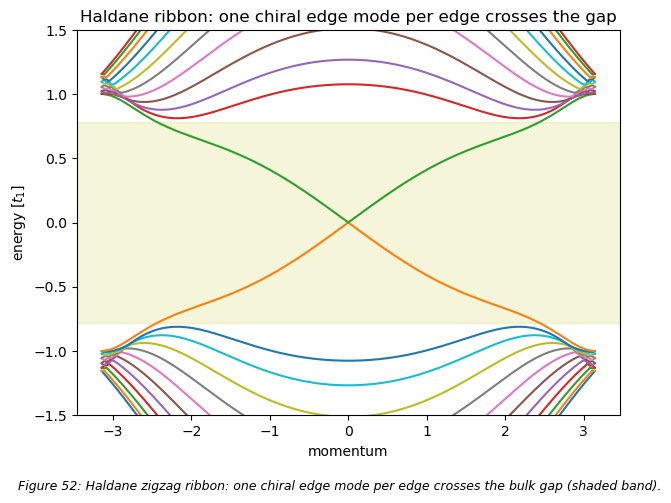

disorder U0=0.0:  T = 1.000000   (chiral edge: no backscattering)
disorder U0=0.3:  T = 0.999985   (chiral edge: no backscattering)


disorder U0=0.6:  T = 0.999960   (chiral edge: no backscattering)


In [46]:
# --- Haldane: chiral edge states and disorder-proof conductance ---------------
import kwant, numpy as np
from matplotlib import pyplot

def haldane_ribbon(M, phi, W=12):
    syst = kwant.Builder(kwant.TranslationalSymmetry(lat.vec((1, 0))))
    syst[lat.shape(lambda p: 0 <= p[1] < W * np.sqrt(3) / 2, (0, 0))] = \
        lambda s: M if s.family == a_sub else -M
    syst[lat.neighbors()] = t1_h
    for kind in nnn_a:
        syst[kind] = t2_h * np.exp(1j * phi)
    for kind in nnn_b:
        syst[kind] = t2_h * np.exp(-1j * phi)
    return syst

frib = haldane_ribbon(0.0, np.pi / 2).finalized()
fig, ax = pyplot.subplots()
kwant.plotter.bands(frib, momenta=np.linspace(-np.pi, np.pi, 201), ax=ax)
ax.set_ylim(-1.5, 1.5)
ax.axhspan(-Mc, Mc, color='y', alpha=.15)
ax.set_xlabel("momentum"); ax.set_ylabel("energy $[t_1]$")
ax.set_title("Haldane ribbon: one chiral edge mode per edge crosses the gap")
show_fig(r'Haldane zigzag ribbon: one chiral edge mode per edge crosses the bulk gap (shaded band).')

def haldane_bar(M, phi, W=10, L=16, U0=0.0, salt="a"):
    syst = kwant.Builder()
    shape = lambda p: (0 <= p[0] < L) and (0 <= p[1] < W * np.sqrt(3) / 2)
    def onsite(s):
        m = M if s.family == a_sub else -M
        return m + U0 * (kwant.digest.uniform(repr(s.tag) + s.family.name,
                                              salt) - 0.5)
    syst[lat.shape(shape, (0, 0))] = onsite
    syst[lat.neighbors()] = t1_h
    for kind in nnn_a:
        syst[kind] = t2_h * np.exp(1j * phi)
    for kind in nnn_b:
        syst[kind] = t2_h * np.exp(-1j * phi)
    syst.eradicate_dangling()
    lead = haldane_ribbon(M, phi, W=W)
    syst.attach_lead(lead)
    syst.attach_lead(lead.reversed())
    return syst.finalized()

E = 0.15                                        # inside the bulk gap
for U0 in (0.0, 0.3, 0.6):
    T = kwant.smatrix(haldane_bar(0.0, np.pi / 2, U0=U0), E).transmission(1, 0)
    print(f"disorder U0={U0}:  T = {T:.6f}   (chiral edge: no backscattering)")
    assert abs(T - 1.0) < 1e-3

---
## 22. The Kane–Mele model — Z₂ and the quantum spin Hall effect

Kane & Mele [PRL **95**, 226801 (2005)] asked what intrinsic spin–orbit
coupling does to graphene.  The answer founded the field of topological
insulators: each spin sector is a Haldane model, with opposite chirality for
opposite spins (so time reversal is preserved),

$$H = t\!\!\sum_{\langle ij\rangle}\! c_i^\dagger c_j
 + i\lambda_{SO}\!\!\sum_{\langle\langle ij\rangle\rangle}\!\! \nu_{ij}\,
   c_i^\dagger \sigma_z c_j .$$

With $S_z$ conserved the spin Chern numbers are $C_\uparrow = -C_\downarrow =
1$: total Chern number zero, but a $\mathbb{Z}_2$ invariant
$\nu = (C_\uparrow - C_\downarrow)/2 \bmod 2 = 1$.  The edges carry a
**helical** Kramers pair (opposite spins move in opposite directions), giving
$G = 2e^2/h$.

The deep point is what survives when $S_z$ conservation is broken (Rashba
term $i\lambda_R (\boldsymbol{\sigma}\times\mathbf{d})_z$ on NN bonds): the
spin Chern numbers lose meaning, but time reversal still forbids
backscattering between Kramers partners — the edge crossing and the quantized
conductance persist.  That robustness *is* the $\mathbb{Z}_2$ classification.
A staggered potential $M > 3\sqrt{3}\lambda_{SO}$ kills the phase.

**Physics in more depth.**  In graphene itself the intrinsic SOC gap is
microscopic ($\sim\mu$eV; Yao *et al.*, PRB **75**, 041401 (2007)), which is
why the quantum spin Hall effect was first seen in HgTe quantum wells
[König *et al.*, Science **318**, 766 (2007), following the BHZ prediction
in §13].  The honeycomb route was later vindicated by heavy-element
analogues: bismuthene on SiC with a 0.8 eV gap [Reis *et al.*, Science
**357**, 287 (2017)] — and monolayer WTe₂ [Wu *et al.*, Science **359**, 76 (2018)].
The $\mathbb{Z}_2$ classification itself: Kane & Mele, PRL **95**, 146802
(2005).


C_up = +1,  C_dn = -1,  C_total = 0   =>   Z2 = 1


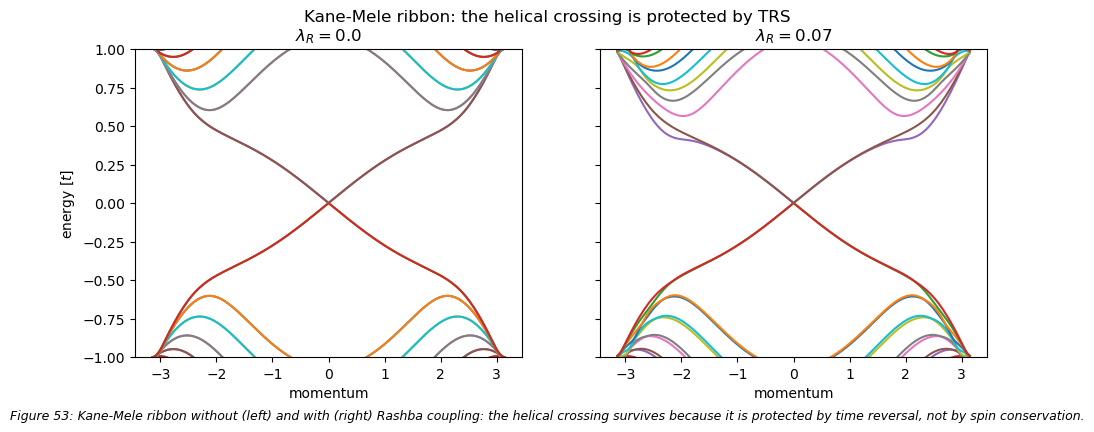

clean                 :  T = 2.00000


disorder U0=0.4       :  T = 1.99993


disorder + Rashba     :  T = 1.99994


M > Mc (trivial)      :  T = 0.00000


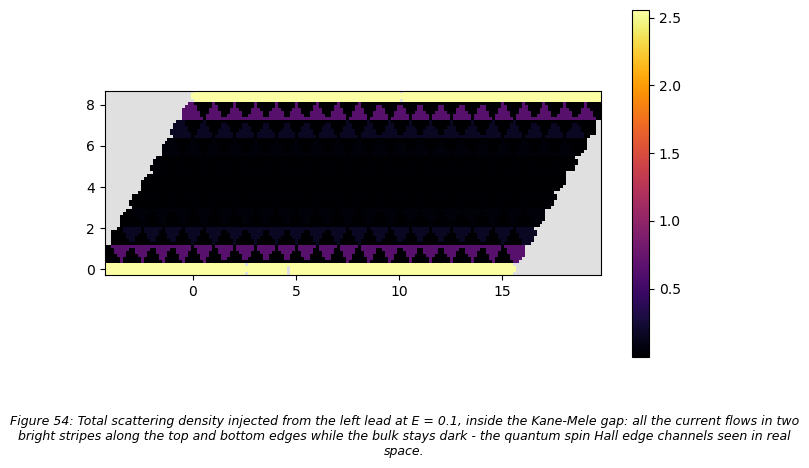

In [47]:
# --- Kane-Mele: spin Chern numbers, helical edges, quantized G ----------------
import kwant, kwant.wraparound, numpy as np
from matplotlib import pyplot

s0 = np.eye(2)
sx = np.array([[0, 1], [1, 0]])
sy = np.array([[0, -1j], [1j, 0]])
sz = np.array([[1, 0], [0, -1]])

t1_km, lam_so = 1.0, 0.1
lat = kwant.lattice.honeycomb(norbs=2)              # 2 orbitals = spin
a_sub, b_sub = lat.sublattices
nnn_a = [kwant.builder.HoppingKind(v, a_sub, a_sub)
         for v in [(1, 0), (-1, 1), (0, -1)]]
nnn_b = [kwant.builder.HoppingKind(v, b_sub, b_sub)
         for v in [(1, 0), (-1, 1), (0, -1)]]

def rashba_nn(lam_r):
    def val(s1, s2):
        d = s1.pos - s2.pos
        return t1_km * s0 + 1j * lam_r * (sx * d[1] - sy * d[0])
    return val

def km_system(sym=None, M=0.0, lam_r=0.0, U0=0.0, shape=None, salt="km"):
    syst = kwant.Builder(sym) if sym is not None else kwant.Builder()
    def onsite(s):
        m = M if s.family == a_sub else -M
        dis = U0 * (kwant.digest.uniform(repr(s.tag) + s.family.name, salt) - .5)
        return (m + dis) * s0
    if shape is None:                       # translationally invariant bulk
        syst[a_sub(0, 0)] = M * s0
        syst[b_sub(0, 0)] = -M * s0
    else:
        syst[lat.shape(shape, (0, 0))] = onsite
    syst[lat.neighbors()] = rashba_nn(lam_r)
    for kind in nnn_a:
        syst[kind] = 1j * lam_so * sz       # spin-up: one chirality...
    for kind in nnn_b:
        syst[kind] = -1j * lam_so * sz      # ...spin-down: the opposite one
    return syst

# spin-resolved Chern numbers (basis per cell: A-up, A-dn, B-up, B-dn)
h_full = bloch_hamiltonian(
    km_system(kwant.TranslationalSymmetry(*lat.prim_vecs)), lat.prim_vecs)
spin_idx = {'up': np.array([0, 2]), 'dn': np.array([1, 3])}
spin_block = lambda h, s: (
    lambda t1, t2: h(t1, t2)[np.ix_(spin_idx[s], spin_idx[s])])

C_up = chern_fhs(spin_block(h_full, 'up'), n_occ=1, n1=24, n2=24)
C_dn = chern_fhs(spin_block(h_full, 'dn'), n_occ=1, n1=24, n2=24)
C_tot = chern_fhs(h_full, n_occ=2, n1=24, n2=24)
print(f"C_up = {C_up:+d},  C_dn = {C_dn:+d},  C_total = {C_tot}"
      f"   =>   Z2 = {abs(C_up - C_dn) // 2 % 2}")
assert C_up == -C_dn and C_tot == 0

# helical edge states: the crossing survives a Rashba perturbation
ribbon_shape = lambda p: 0 <= p[1] < 12 * np.sqrt(3) / 2
fig, axes = pyplot.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, lam_r in zip(axes, (0.0, 0.07)):
    frib = km_system(kwant.TranslationalSymmetry(lat.vec((1, 0))),
                     lam_r=lam_r, shape=ribbon_shape).finalized()
    kwant.plotter.bands(frib, momenta=np.linspace(-np.pi, np.pi, 161), ax=ax)
    ax.set_ylim(-1, 1); ax.set_title(f"$\\lambda_R = {lam_r}$")
    ax.set_xlabel("momentum")
axes[0].set_ylabel("energy $[t]$")
fig.suptitle("Kane-Mele ribbon: the helical crossing is protected by TRS")
show_fig(r'Kane-Mele ribbon without (left) and with (right) Rashba coupling: the helical crossing survives because it is protected by time reversal, not by spin conservation.')

# transport: G = 2 e^2/h, robust to TRS-preserving disorder and Rashba
def km_bar(M=0.0, lam_r=0.0, U0=0.0, W=10, L=16):
    shape = lambda p: (0 <= p[0] < L) and (0 <= p[1] < W * np.sqrt(3) / 2)
    syst = km_system(M=M, lam_r=lam_r, U0=U0, shape=shape)
    syst.eradicate_dangling()
    lead = km_system(kwant.TranslationalSymmetry(lat.vec((1, 0))), M=M,
                     lam_r=lam_r, shape=lambda p: 0 <= p[1] < W * np.sqrt(3) / 2)
    syst.attach_lead(lead)
    syst.attach_lead(lead.reversed())
    return syst.finalized()

E = 0.1
for kwargs, label in [(dict(), "clean"),
                      (dict(U0=0.4), "disorder U0=0.4"),
                      (dict(U0=0.4, lam_r=0.05), "disorder + Rashba"),
                      (dict(M=1.5 * 3 * np.sqrt(3) * lam_so), "M > Mc (trivial)")]:
    T = kwant.smatrix(km_bar(**kwargs), E).transmission(1, 0)
    print(f"{label:22s}:  T = {T:.5f}")

# the helical edge channels in real space
fkm = km_bar()
psi_km = kwant.wave_function(fkm, E)(0)
rho_km = kwant.operator.Density(fkm)
d_km = sum(rho_km(p) for p in psi_km)
kwant.plotter.map(fkm, d_km, oversampling=4, cmap='inferno',
                  fig_size=(8, 4.5), show=False)
show_fig(r'Total scattering density injected from the left lead at E = 0.1, inside the Kane-Mele gap: all the current flows in two bright stripes along the top and bottom edges while the bulk stays dark - the quantum spin Hall edge channels seen in real space.')

---
## 23. The p+ip superconductor — chiral Majorana edges

Read & Green [PRB **61**, 10267 (2000)]: a 2D spinless superconductor with
$p_x + ip_y$ pairing,

$$H(\mathbf{k}) = \left[-2t(\cos k_x + \cos k_y) - \mu\right]\tau_z
 + \Delta\left(\sin k_x\, \tau_x + \sin k_y\, \tau_y\right),$$

is the 2D relative of the Kitaev chain: same symmetry class (D), but in 2D the
invariant is the **Chern number of the BdG bands**.  The weak-pairing phases
$-4t < \mu < 0$ and $0 < \mu < 4t$ carry $C = \pm 1$; strong pairing
($|\mu| > 4t$) is trivial.

Bulk–boundary correspondence here produces something strictly stranger than in
a Chern insulator: the edge carries a single **chiral Majorana mode** — "half"
a chiral fermion, $\gamma(-E)=\gamma^\dagger(E)$ — and a vortex in the order
parameter binds a Majorana zero mode, which is the original proposal for
topological quantum computation.  Below: the BdG Chern number through both
transitions, the chiral Majorana dispersion on a strip, and its localization
on the boundary of a finite sample.

**Physics in more depth.**  Beyond the chiral edge, the bulk of a p+ip
superconductor holds its most famous property: a vortex binds a single
Majorana zero mode, and vortices consequently obey **non-abelian
statistics** [Read & Green, PRB **61**, 10267 (2000); Ivanov, PRL **86**,
268 (2001)].  Intrinsic p-wave materials are scarce — the long-standing
Sr₂RuO₄ candidacy is now heavily qualified [Mackenzie *et al.*, npj Quantum
Mater. **2**, 40 (2017)] — so the modern route is *engineering*: the surface
of a 3D TI proximitised by an s-wave superconductor behaves exactly like
p+ip without breaking time reversal [Fu & Kane, PRL **100**, 096407
(2008)].  Review of topological superconductivity: Sato & Ando, Rep. Prog.
Phys. **80**, 076501 (2017).


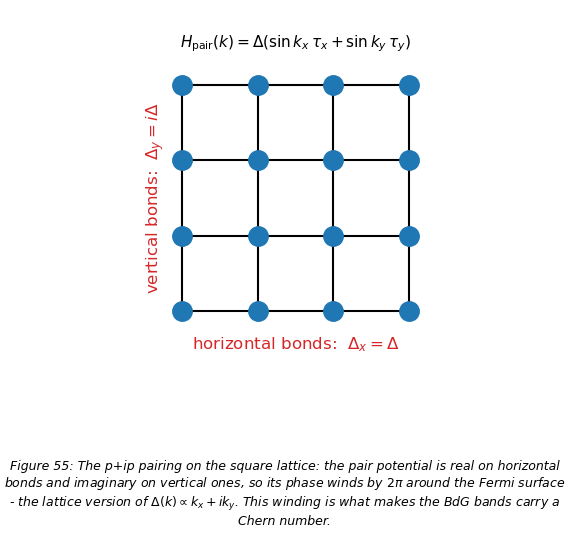

In [48]:
# --- geometry: the p+ip pairing pattern --------------------------------------
import numpy as np
from matplotlib import pyplot

fig, ax = pyplot.subplots(figsize=(5.5, 5))
for i in range(4):
    for j in range(4):
        if i < 3:
            ax.plot([i, i + 1], [j, j], 'k-', lw=1.5)
        if j < 3:
            ax.plot([i, i], [j, j + 1], 'k-', lw=1.5)
        ax.plot(i, j, 'o', color='C0', ms=14, zorder=3)
ax.text(1.5, -0.5, r'horizontal bonds:  $\Delta_x = \Delta$', ha='center',
        fontsize=12, color='C3')
ax.text(-0.5, 1.5, r'vertical bonds:  $\Delta_y = i\Delta$', va='center',
        rotation=90, fontsize=12, color='C3')
ax.text(1.5, 3.5,
        r'$H_{\rm pair}(k) = \Delta(\sin k_x\,\tau_x + \sin k_y\,\tau_y)$',
        ha='center', fontsize=11)
ax.set_xlim(-1.1, 4)
ax.set_ylim(-1.1, 4)
ax.set_aspect('equal')
ax.set_axis_off()
show_fig(r'The p+ip pairing on the square lattice: the pair potential is real on horizontal bonds and imaginary on vertical ones, so its phase winds by $2\pi$ around the Fermi surface - the lattice version of $\Delta(k)\propto k_x + i k_y$. This winding is what makes the BdG bands carry a Chern number.')

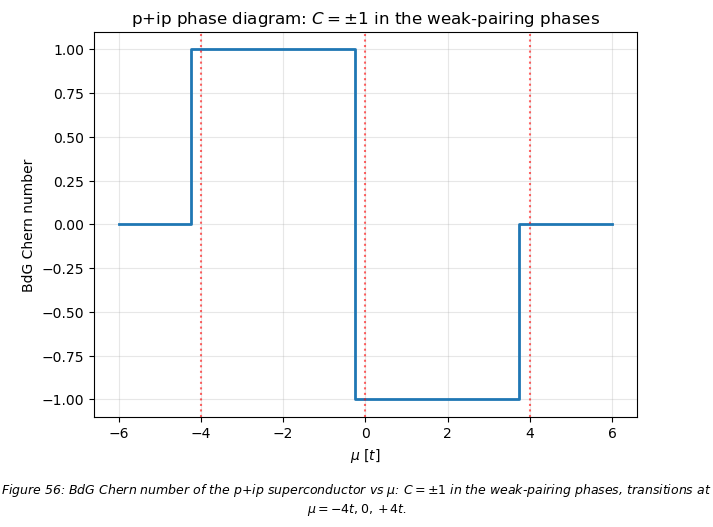

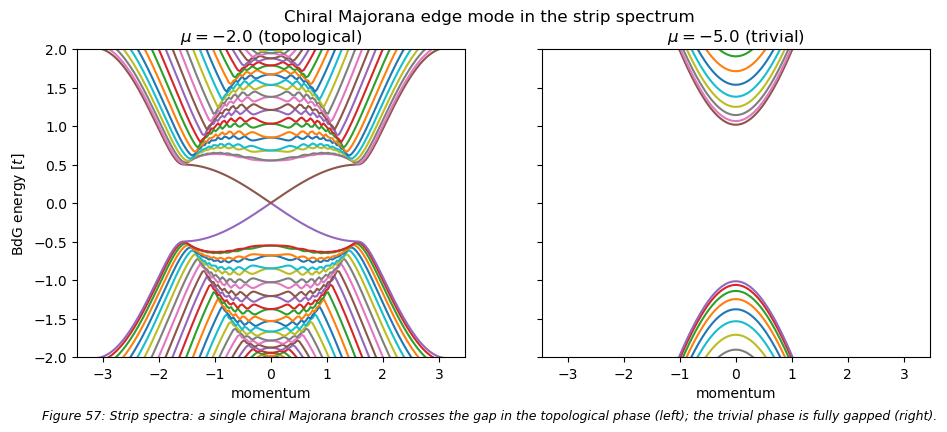

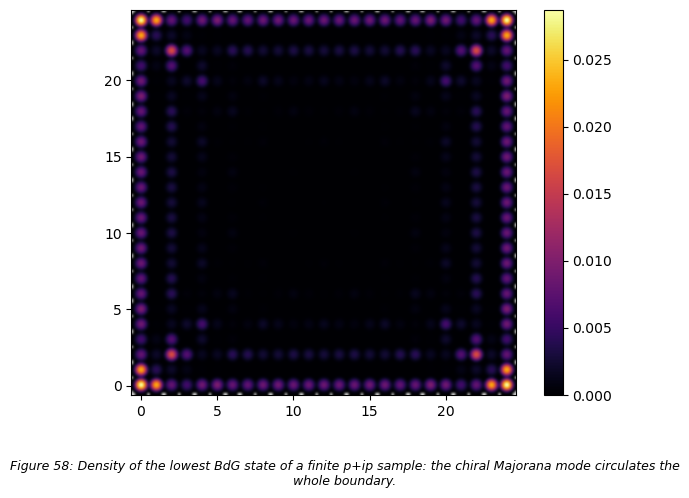

lowest BdG level |E| = 0.0138 (a +/-E particle-hole pair); the density map shows the chiral Majorana circulating the boundary


In [49]:
# --- p+ip: BdG Chern number, chiral Majorana edge mode ------------------------
import kwant, kwant.wraparound, numpy as np
import scipy.sparse.linalg as sla
from matplotlib import pyplot

tau_x = np.array([[0, 1], [1, 0]])
tau_y = np.array([[0, -1j], [1j, 0]])
tau_z = np.array([[1, 0], [0, -1]])
t, Delta = 1.0, 0.5
lat = kwant.lattice.square(norbs=2)             # Nambu (particle, hole)

hop_x = -t * tau_z - 0.5j * Delta * tau_x
hop_y = -t * tau_z - 0.5j * Delta * tau_y

def pip_bulk(mu):
    syst = kwant.Builder(kwant.TranslationalSymmetry(*lat.prim_vecs))
    syst[lat(0, 0)] = -mu * tau_z
    syst[kwant.builder.HoppingKind((1, 0), lat, lat)] = hop_x
    syst[kwant.builder.HoppingKind((0, 1), lat, lat)] = hop_y
    return syst

# BdG Chern number vs mu: transitions at mu = -4t, 0, +4t
mus = np.linspace(-6, 6, 25)
Cs = [chern_fhs(bloch_hamiltonian(pip_bulk(m), lat.prim_vecs),
                n_occ=1, n1=20, n2=20) for m in mus]
pyplot.step(mus, Cs, where='mid', lw=2)
for m in (-4, 0, 4):
    pyplot.axvline(m, color='r', ls=':', alpha=.6)
pyplot.xlabel(r"$\mu\ [t]$"); pyplot.ylabel("BdG Chern number")
pyplot.title(r"p+ip phase diagram: $C=\pm1$ in the weak-pairing phases")
pyplot.grid(alpha=.3); show_fig(r'BdG Chern number of the p+ip superconductor vs $\mu$: $C=\pm1$ in the weak-pairing phases, transitions at $\mu=-4t,0,+4t$.')

# strip: the chiral Majorana branch crosses E = 0
def pip_strip(mu, W=25):
    syst = kwant.Builder(kwant.TranslationalSymmetry((-1, 0)))
    syst[(lat(0, y) for y in range(W))] = -mu * tau_z
    syst[kwant.builder.HoppingKind((1, 0), lat, lat)] = hop_x
    syst[kwant.builder.HoppingKind((0, 1), lat, lat)] = hop_y
    return syst.finalized()

fig, axes = pyplot.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, mu, label in zip(axes, (-2.0, -5.0), ("topological", "trivial")):
    kwant.plotter.bands(pip_strip(mu), momenta=np.linspace(-np.pi, np.pi, 161),
                        ax=ax)
    ax.set_ylim(-2, 2); ax.set_title(f"$\\mu = {mu}$ ({label})")
    ax.set_xlabel("momentum")
axes[0].set_ylabel("BdG energy $[t]$")
fig.suptitle("Chiral Majorana edge mode in the strip spectrum")
show_fig(r'Strip spectra: a single chiral Majorana branch crosses the gap in the topological phase (left); the trivial phase is fully gapped (right).')

# the near-zero mode of a finite sample lives on the boundary
W = L = 25
syst = kwant.Builder()
syst[(lat(x, y) for x in range(L) for y in range(W))] = 2.0 * tau_z  # mu = -2
syst[kwant.builder.HoppingKind((1, 0), lat, lat)] = hop_x
syst[kwant.builder.HoppingKind((0, 1), lat, lat)] = hop_y
fsyst = syst.finalized()
ham = fsyst.hamiltonian_submatrix(sparse=True).tocsc()
ev, vec = sla.eigsh(ham, k=8, sigma=0)
i0 = np.argmin(np.abs(ev))
dens = (np.abs(vec[:, i0]) ** 2).reshape(-1, 2).sum(axis=1)
kwant.plotter.density(fsyst, dens, cmap='inferno', show=False)
show_fig(r'Density of the lowest BdG state of a finite p+ip sample: the chiral Majorana mode circulates the whole boundary.')
print(f"lowest BdG level |E| = {abs(ev[i0]):.4f} (a +/-E particle-hole pair); the density map shows the "
      "chiral Majorana circulating the boundary")

---
## 24. The BBH quadrupole — higher-order topology

Benalcazar, Bernevig & Hughes [Science **357**, 61 (2017)] found insulators
whose boundary is *also* gapped, yet still topological: the protected states
live two dimensions down, at the **corners**.  The model is a square lattice
with four sites per cell, $\pi$ flux per plaquette, intra-cell hopping
$\gamma$ and inter-cell hopping $\lambda$:

$$H(\mathbf{k}) = \begin{pmatrix} 0 & q(\mathbf{k}) \\ q^\dagger(\mathbf{k}) & 0
\end{pmatrix},\qquad
q = \begin{pmatrix} \gamma + \lambda e^{ik_x} & \gamma + \lambda e^{ik_y} \\
 -(\gamma + \lambda e^{-ik_y}) & \gamma + \lambda e^{-ik_x} \end{pmatrix}.$$

The dipole (Chern/polarization) invariants all vanish.  The right invariant is
*nested*: first a Wilson loop over $k_y$ at each $k_x$ gives the **Wannier
bands** $\nu_\pm(k_x)$ — themselves gapped, like an effective 1D spectrum —
then the polarization *of a Wannier band* gives the quadrupole moment

$$q_{xy} = \tfrac{1}{2}\ (\gamma < \lambda), \qquad 0\ (\gamma > \lambda).$$

Bulk–boundary correspondence, twice removed: $q_{xy}=1/2$ forces four
zero-energy corner states carrying charge $\pm e/2$ each.

*Experiments:* the BBH model was realised almost immediately in three
platforms in the same year — mechanical metamaterials [Serra-Garcia *et
al.*, Nature **555**, 342 (2018)], microwave circuits [Peterson *et al.*,
Nature **555**, 346 (2018)] and electrical circuit lattices [Imhof *et
al.*, Nat. Phys. **14**, 925 (2018)].  In electronic matter, bismuth again
leads: hinge states of a higher-order phase were reported in Schindler *et
al.*, Nat. Phys. **14**, 918 (2018).  Review: Xie *et al.*, Nat. Rev. Phys.
**3**, 520 (2021).


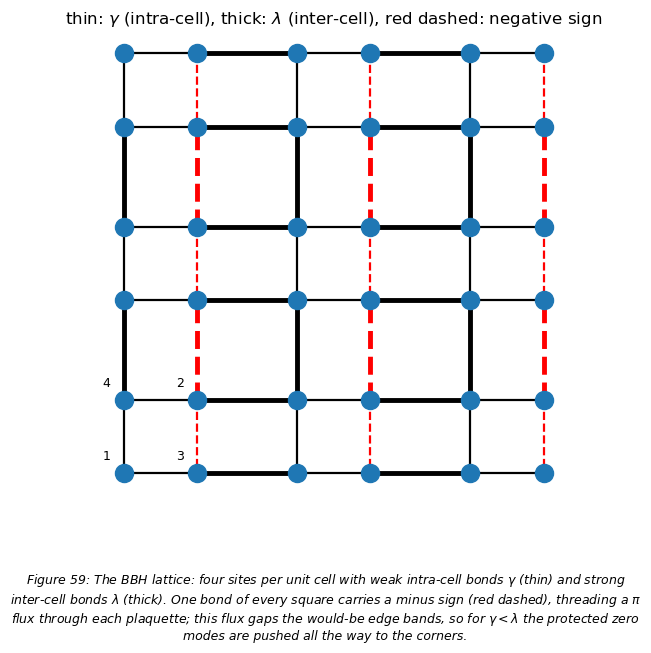

In [50]:
# --- geometry: the BBH unit cell and its pi fluxes ---------------------------
import numpy as np
from matplotlib import pyplot

fig, ax = pyplot.subplots(figsize=(6.5, 6))
pos = {0: (0, 0), 1: (1, 1), 2: (1, 0), 3: (0, 1)}   # = basis order of h_bbh

def draw_cell(ox, oy, first):
    P = {k: (ox + x * 0.55, oy + y * 0.55) for k, (x, y) in pos.items()}
    intra = [(0, 2, +1), (1, 3, +1),          # horizontals, both +gamma
             (0, 3, +1), (1, 2, -1)]          # verticals: right one -gamma
    for a, b, sgn in intra:
        ax.plot(*zip(P[a], P[b]), color='k' if sgn > 0 else 'r',
                ls='-' if sgn > 0 else '--', lw=1.6)
    for k, (x, y) in P.items():
        ax.plot(x, y, 'o', ms=13, color='C0', zorder=3)
        if first:
            ax.text(x - 0.16, y + 0.10, str(k + 1), fontsize=9)

for ox in (0, 1.3, 2.6):
    for oy in (0, 1.3, 2.6):
        draw_cell(ox, oy, ox == 0 and oy == 0)
for ox in (0, 1.3):                            # inter-cell (lambda) bonds
    for oy in (0, 1.3, 2.6):
        ax.plot([ox + 0.55, ox + 1.3], [oy, oy], 'k-', lw=3.5)
        ax.plot([ox + 0.55, ox + 1.3], [oy + 0.55, oy + 0.55], 'k-', lw=3.5)
for oy in (0, 1.3):
    for ox in (0, 1.3, 2.6):
        ax.plot([ox, ox], [oy + 0.55, oy + 1.3], 'k-', lw=3.5)
        ax.plot([ox + 0.55, ox + 0.55], [oy + 0.55, oy + 1.3], 'r--', lw=3.5)
ax.set_aspect('equal')
ax.set_axis_off()
ax.set_title(r'thin: $\gamma$ (intra-cell), thick: $\lambda$ (inter-cell), '
             r'red dashed: negative sign')
show_fig(r'The BBH lattice: four sites per unit cell with weak intra-cell bonds $\gamma$ (thin) and strong inter-cell bonds $\lambda$ (thick). One bond of every square carries a minus sign (red dashed), threading a $\pi$ flux through each plaquette; this flux gaps the would-be edge bands, so for $\gamma<\lambda$ the protected zero modes are pushed all the way to the corners.')

quadrupole q_xy:  topological = 0.5000  trivial = 0.0000


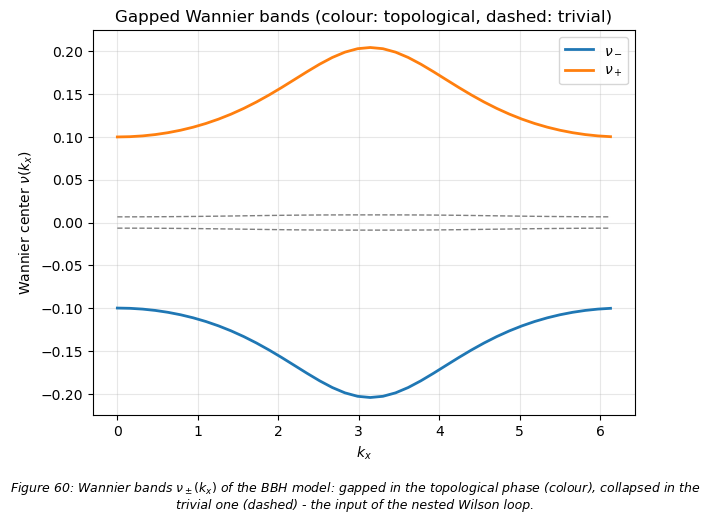

four in-gap corner modes at E = [ 1.e-05 -1.e-05  1.e-05 -1.e-05]


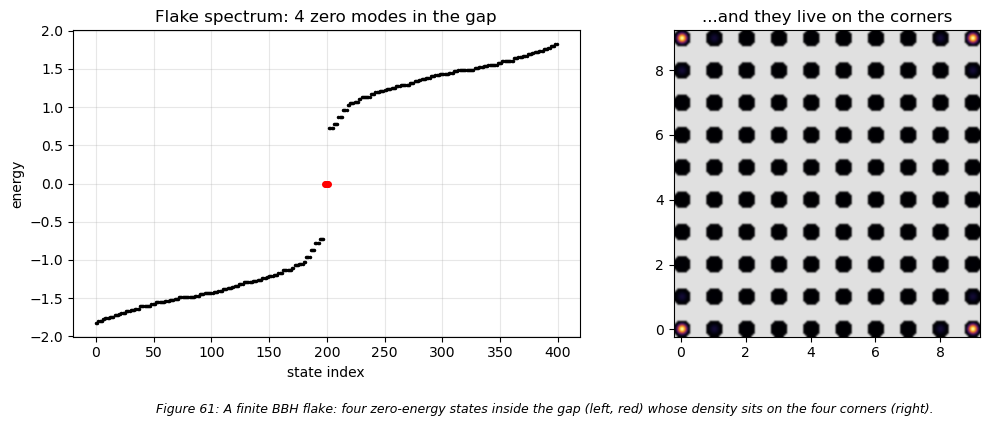

trivial flake: smallest |E| = 1.013  (no midgap states)


In [51]:
# --- BBH quadrupole: Wannier bands, nested Wilson loop, corner states ---------
import kwant, numpy as np
from matplotlib import pyplot

gam, lam = 0.3, 1.0                 # topological: gam < lam

def h_bbh(kx, ky, gam=gam, lam=lam):
    q = np.array([[gam + lam * np.exp(1j * kx), gam + lam * np.exp(1j * ky)],
                  [-(gam + lam * np.exp(-1j * ky)), gam + lam * np.exp(-1j * kx)]])
    z = np.zeros((2, 2))
    return np.block([[z, q], [q.conj().T, z]])

def wannier_bands(gam, lam, N=40):
    """Wilson loop over ky at each kx; eigenphases/2pi = Wannier centers."""
    ks = np.linspace(0, 2 * np.pi, N, endpoint=False)
    u = np.empty((N, N), dtype=object)
    for i, kx in enumerate(ks):
        for j, ky in enumerate(ks):
            u[i, j] = np.linalg.eigh(h_bbh(kx, ky, gam, lam))[1][:, :2]
    centers, states = [], []
    for i in range(N):
        W = np.eye(2, dtype=complex)
        for j in range(N):
            F = u[i, j].conj().T @ u[i, (j + 1) % N]
            uu, _, vv = np.linalg.svd(F)        # unitarize the link
            W = W @ (uu @ vv)
        ph, vec = np.linalg.eig(W)
        nu = np.angle(ph) / (2 * np.pi)
        order = np.argsort(nu)
        centers.append(nu[order])
        states.append(u[i, 0] @ vec[:, order])  # Wannier-band basis
    return ks, np.array(centers), states

def nested_polarization(states):
    """Polarization of the upper Wannier band along kx: the quadrupole q_xy."""
    N = len(states)
    prod = 1.0 + 0j
    for i in range(N):
        prod *= np.vdot(states[i][:, 1], states[(i + 1) % N][:, 1])
    return (-np.angle(prod) / (2 * np.pi)) % 1

ks, nu, wst = wannier_bands(gam, lam)
_, nu_t, wst_t = wannier_bands(1.0, 0.3)        # trivial: gam > lam
print(f"quadrupole q_xy:  topological = {nested_polarization(wst):.4f}  "
      f"trivial = {nested_polarization(wst_t):.4f}")

pyplot.plot(ks, nu[:, 0], 'C0', lw=2, label=r'$\nu_-$')
pyplot.plot(ks, nu[:, 1], 'C1', lw=2, label=r'$\nu_+$')
pyplot.plot(ks, nu_t, 'gray', lw=1, ls='--')
pyplot.xlabel(r"$k_x$"); pyplot.ylabel(r"Wannier center $\nu(k_x)$")
pyplot.title("Gapped Wannier bands (colour: topological, dashed: trivial)")
pyplot.legend(); pyplot.grid(alpha=.3); show_fig(r'Wannier bands $\nu_\pm(k_x)$ of the BBH model: gapped in the topological phase (colour), collapsed in the trivial one (dashed) - the input of the nested Wilson loop.')

# corner states of a finite flake
lat = kwant.lattice.square(norbs=4)

def bbh_flake(gam, lam, Nc=10):
    on = np.array([[0, 0, gam, gam],
                   [0, 0, -gam, gam],
                   [gam, -gam, 0, 0],
                   [gam, gam, 0, 0]], dtype=complex)
    hx = np.zeros((4, 4), dtype=complex); hx[0, 2] = lam; hx[3, 1] = lam
    hy = np.zeros((4, 4), dtype=complex); hy[0, 3] = lam; hy[2, 1] = -lam
    syst = kwant.Builder()
    syst[(lat(x, y) for x in range(Nc) for y in range(Nc))] = on
    syst[kwant.builder.HoppingKind((1, 0), lat, lat)] = hx
    syst[kwant.builder.HoppingKind((0, 1), lat, lat)] = hy
    return syst.finalized()

f_top = bbh_flake(gam, lam)
ev, vec = np.linalg.eigh(f_top.hamiltonian_submatrix())
izero = np.argsort(np.abs(ev))[:4]
print("four in-gap corner modes at E =", np.round(ev[izero], 5))

fig, (ax1, ax2) = pyplot.subplots(1, 2, figsize=(11, 4))
ax1.plot(np.arange(len(ev)), ev, 'k.', ms=3)
ax1.plot(izero, ev[izero], 'r.', ms=8)
ax1.set_xlabel("state index"); ax1.set_ylabel("energy")
ax1.set_title("Flake spectrum: 4 zero modes in the gap")
ax1.grid(alpha=.3)
dens = (np.abs(vec[:, izero]) ** 2).sum(axis=1).reshape(-1, 4).sum(axis=1)
kwant.plotter.density(f_top, dens, ax=ax2, cmap='inferno')
ax2.set_title("...and they live on the corners")
pyplot.tight_layout(); show_fig(r'A finite BBH flake: four zero-energy states inside the gap (left, red) whose density sits on the four corners (right).')

ev_tri = np.linalg.eigvalsh(bbh_flake(1.0, 0.3).hamiltonian_submatrix())
print(f"trivial flake: smallest |E| = {np.abs(ev_tri).min():.3f}  (no midgap states)")

---
## 25. Weyl semimetals — Fermi arcs from sliced Chern numbers

A Weyl semimetal needs no gap at all: its band structure holds isolated
touching points that act as **monopoles of Berry curvature** with chirality
$\pm 1$ [Wan *et al.*, PRB **83**, 205101 (2011); Armitage *et al.*, RMP
**90**, 015001 (2018)].  The minimal two-band lattice model

$$H(\mathbf{k}) = t\sin k_x\,\sigma_x + t\sin k_y\,\sigma_y +
\left[m_0 - t(\cos k_x + \cos k_y + \cos k_z)\right]\sigma_z$$

has two Weyl nodes at $(0,0,\pm k_0)$, $\cos k_0 = m_0/t - 2$.  The key
construction: freeze $k_z$ and regard $H(k_x, k_y; k_z)$ as a family of 2D
insulators.  The slice Chern number $C(k_z)$ **jumps by the chirality** when
$k_z$ sweeps through a node — nonzero exactly *between* the nodes.  Each
nontrivial slice contributes one chiral edge state at $E=0$; strung together
over $|k_z|<k_0$ they form the open **Fermi arc** connecting the projected
nodes on a surface — an object impossible in any isolated 2D system.
(A Kwant-based transport study of this model: the
[WEYLFET repository](https://github.com/GUANGZECHEN/WEYLFET).)

**Physics in more depth.**  A Weyl node cannot be gapped by any local
perturbation — the only way to destroy it is to annihilate it with a node
of opposite chirality, which is why Weyl semimetals need broken inversion
or time-reversal symmetry (Nielsen-Ninomiya theorem: chiralities must sum
to zero on a lattice [Phys. Lett. B **130**, 389 (1983)]).  The same
theorem underlies the **chiral anomaly**: parallel E and B fields pump
charge between the nodes, producing a negative longitudinal
magnetoresistance [Xiong *et al.*, Science **350**, 413 (2015)].

*Experiments:* Fermi arcs were imaged by ARPES in TaAs [Xu *et al.*,
Science **349**, 613 (2015); Lv *et al.*, PRX **5**, 031013 (2015)].
Reviews: Armitage, Mele & Vishwanath, RMP **90**, 015001 (2018); Yan &
Felser, Annu. Rev. Condens. Matter Phys. **8**, 337 (2017).


gap at (0,0,+-k0): 0.0e+00   (k0 = 1.0472)


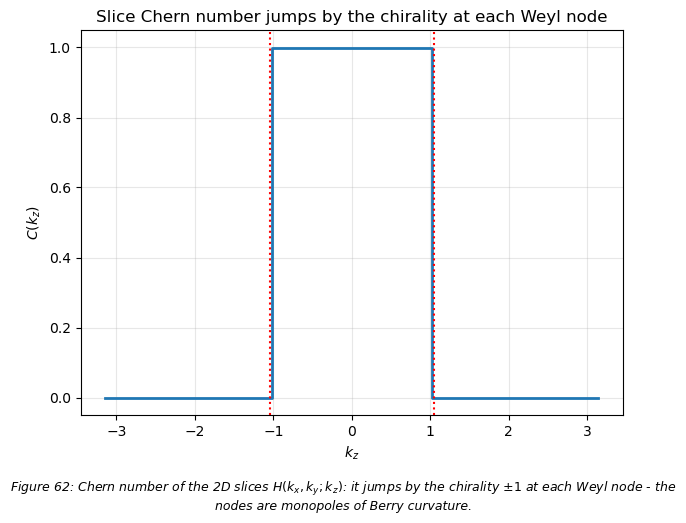

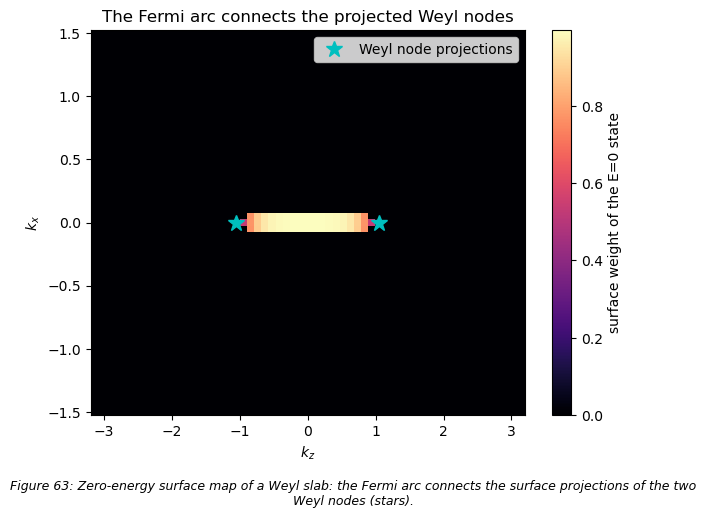

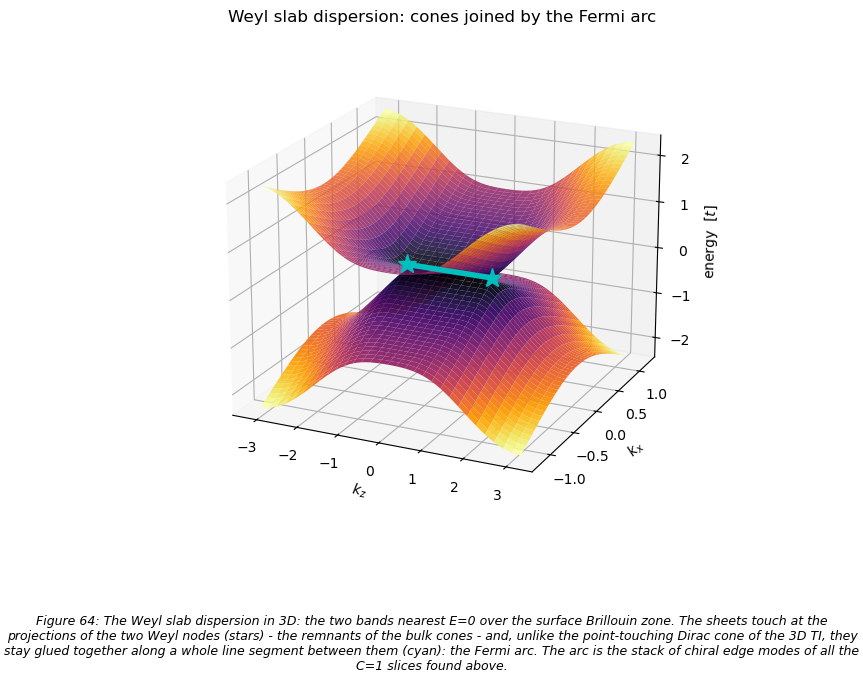

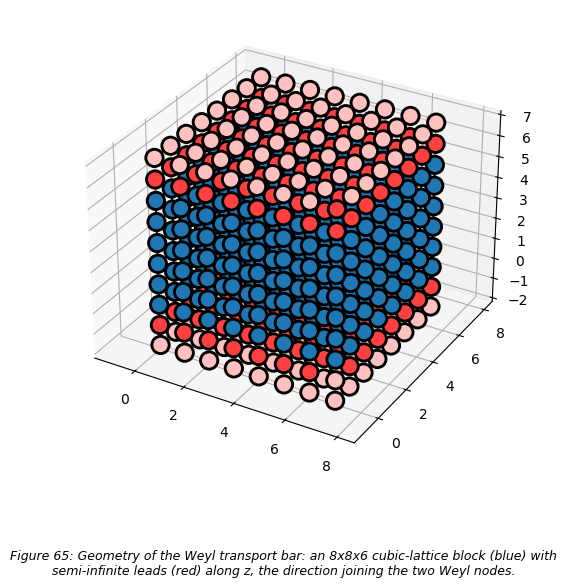

E=0.05:  G = 0.00 e^2/h


E=0.3:  G = 1.00 e^2/h


E=0.6:  G = 5.00 e^2/h


In [52]:
# --- Weyl semimetal: nodes, sliced Chern numbers, Fermi arcs, transport -------
import kwant, numpy as np
from matplotlib import pyplot

sx = np.array([[0, 1], [1, 0]])
sy = np.array([[0, -1j], [1j, 0]])
sz = np.array([[1, 0], [0, -1]])
t, m0 = 1.0, 2.5
k0 = np.arccos(m0 / t - 2)                  # nodes at (0, 0, +-pi/3)

def h_weyl(kx, ky, kz):
    M = m0 - t * (np.cos(kx) + np.cos(ky) + np.cos(kz))
    return t * np.sin(kx) * sx + t * np.sin(ky) * sy + M * sz

print(f"gap at (0,0,+-k0): {np.abs(np.linalg.eigvalsh(h_weyl(0, 0, k0))).min():.1e}"
      f"   (k0 = {k0:.4f})")

# Chern number of each kz slice: +-1 between the nodes, 0 outside
kzs = np.linspace(-np.pi, np.pi, 41)
Cs = [chern_fhs(lambda kx, ky, kz=kz: h_weyl(kx, ky, kz),
                n_occ=1, n1=18, n2=18) for kz in kzs]
pyplot.step(kzs, Cs, where='mid', lw=2)
pyplot.axvline(-k0, color='r', ls=':'); pyplot.axvline(k0, color='r', ls=':')
pyplot.xlabel(r"$k_z$"); pyplot.ylabel(r"$C(k_z)$")
pyplot.title("Slice Chern number jumps by the chirality at each Weyl node")
pyplot.grid(alpha=.3); show_fig(r'Chern number of the 2D slices $H(k_x,k_y;k_z)$: it jumps by the chirality $\pm1$ at each Weyl node - the nodes are monopoles of Berry curvature.')

# Fermi arc: slab finite in y; scan (kx, kz) for E~0 surface states
Ny = 30
hop_y = -t * (sz + 1j * sy) / 2             # from -t cos(ky) sz + t sin(ky) sy

def slab_h(kx, kz):
    on = t * np.sin(kx) * sx + (m0 - t * np.cos(kx) - t * np.cos(kz)) * sz
    H = np.zeros((2 * Ny, 2 * Ny), dtype=complex)
    for y in range(Ny):
        H[2*y:2*y+2, 2*y:2*y+2] = on
        if y + 1 < Ny:
            H[2*y:2*y+2, 2*y+2:2*y+4] = hop_y
            H[2*y+2:2*y+4, 2*y:2*y+2] = hop_y.conj().T
    return H

kxs = np.linspace(-1.5, 1.5, 61)
kzs = np.linspace(-np.pi, np.pi, 61)
arc = np.zeros((len(kxs), len(kzs)))
for i, kx in enumerate(kxs):
    for j, kz in enumerate(kzs):
        ev, vec = np.linalg.eigh(slab_h(kx, kz))
        i0 = np.argmin(np.abs(ev))
        if abs(ev[i0]) < 0.05:                       # a state at the Fermi level
            d = (np.abs(vec[:, i0]) ** 2).reshape(Ny, 2).sum(axis=1)
            arc[i, j] = d[:4].sum() + d[-4:].sum()   # ...on the surface?

pyplot.pcolormesh(kzs, kxs, arc, shading='auto', cmap='magma')
pyplot.colorbar(label="surface weight of the E=0 state")
pyplot.plot([-k0, k0], [0, 0], 'c*', ms=12, label="Weyl node projections")
pyplot.xlabel(r"$k_z$"); pyplot.ylabel(r"$k_x$")
pyplot.title("The Fermi arc connects the projected Weyl nodes")
pyplot.legend(); show_fig(r'Zero-energy surface map of a Weyl slab: the Fermi arc connects the surface projections of the two Weyl nodes (stars).')

# the same physics in 3D: the two slab bands nearest E=0 over the surface BZ.
# Where the TI cone of section 26 touches at a POINT, these sheets touch along
# a LINE - the Fermi arc - terminating in the two bulk Weyl cones.
kxs3 = np.linspace(-1.2, 1.2, 45)
kzs3 = np.linspace(-np.pi, np.pi, 61)
KX3, KZ3 = np.meshgrid(kxs3, kzs3)
E_up = np.zeros_like(KX3)
E_dn = np.zeros_like(KX3)
for i in range(KX3.shape[0]):
    for j in range(KX3.shape[1]):
        ev_k = np.linalg.eigvalsh(slab_h(KX3[i, j], KZ3[i, j]))
        E_up[i, j] = ev_k[ev_k > 0].min()
        E_dn[i, j] = ev_k[ev_k < 0].max()

fig = pyplot.figure(figsize=(8.5, 6.5))
ax = fig.add_subplot(projection='3d')
ax.plot_surface(KZ3, KX3, E_up, cmap='inferno', linewidth=0,
                antialiased=True, alpha=0.85)
ax.plot_surface(KZ3, KX3, E_dn, cmap='inferno_r', linewidth=0,
                antialiased=True, alpha=0.95)
# draw the arc slightly above E=0 so matplotlib's painter keeps it visible
ax.plot([-k0, k0], [0, 0], [0.05, 0.05], 'c-', lw=4, zorder=10)
ax.plot([-k0, k0], [0, 0], [0.05, 0.05], 'c*', ms=14, zorder=11)
ax.set_xlabel(r'$k_z$')
ax.set_ylabel(r'$k_x$')
ax.set_zlabel('energy  $[t]$')
ax.set_title('Weyl slab dispersion: cones joined by the Fermi arc')
ax.view_init(elev=20, azim=-65)
show_fig(r'The Weyl slab dispersion in 3D: the two bands nearest E=0 over the surface Brillouin zone. The sheets touch at the projections of the two Weyl nodes (stars) - the remnants of the bulk cones - and, unlike the point-touching Dirac cone of the 3D TI, they stay glued together along a whole line segment between them (cyan): the Fermi arc. The arc is the stack of chiral edge modes of all the C=1 slices found above.')

# ballistic transport through a Weyl wire: little at the nodes, much away
lat3 = kwant.lattice.cubic(norbs=2)
hops = {(1, 0, 0): -t * (sz + 1j * sx) / 2,
        (0, 1, 0): -t * (sz + 1j * sy) / 2,
        (0, 0, 1): -t * sz / 2}

def weyl_wire(W=8, L=6):
    def fill(syst, rng):
        syst[(lat3(x, y, z) for x in range(W) for y in range(W) for z in rng)] \
            = m0 * sz
        for d, v in hops.items():
            syst[kwant.builder.HoppingKind(d, lat3, lat3)] = v
    syst = kwant.Builder()
    fill(syst, range(L))
    lead = kwant.Builder(kwant.TranslationalSymmetry((0, 0, -1)))
    fill(lead, [0])
    syst.attach_lead(lead)
    syst.attach_lead(lead.reversed())
    return syst.finalized()

fw = weyl_wire()
kwant.plot(fw, site_size=0.3, hop_lw=0.06, fig_size=(6, 6), show=False)
show_fig(r'Geometry of the Weyl transport bar: an 8x8x6 cubic-lattice block (blue) with semi-infinite leads (red) along z, the direction joining the two Weyl nodes.')
for e in (0.05, 0.3, 0.6):
    print(f"E={e}:  G = {kwant.smatrix(fw, e).transmission(1, 0):.2f} e^2/h")

---
## 26. The 3D topological insulator — a Dirac cone on every surface

The 3D strong TI [Fu, Kane & Mele, PRL **98**, 106803 (2007); realized in
Bi₂Se₃, Zhang *et al.*, Nat. Phys. **5**, 438 (2009)] is described near the
band inversion by the lattice-regularized Dirac model

$$H(\mathbf{k}) = m(\mathbf{k})\,\tau_z\!\otimes\!\sigma_0
 + \lambda\sum_{i=x,y,z}\sin k_i\ \tau_x\!\otimes\!\sigma_i,
 \qquad m(\mathbf{k}) = m_0 - t\!\sum_i \cos k_i .$$

With inversion symmetry ($P = \tau_z$) the strong $\mathbb{Z}_2$ index
follows from the **Fu–Kane parity criterion**: the product of the occupied
parity eigenvalues over the 8 time-reversal-invariant momenta,

$$(-1)^{\nu_0} = \prod_{\Lambda}\ \prod_{n \in \text{occ}} \xi_n(\Lambda).$$

For $1 < m_0/t < 3$ the band inversion happens at $\Gamma$ alone and
$\nu_0 = 1$.  The surface then *must* carry an odd number of Dirac cones —
a "half" graphene that cannot be gapped by any TRS-preserving perturbation.
Below: the parity count, the surface Dirac cone of a slab (with its
wavefunctions glued to the surfaces), and ballistic surface conduction
through the bulk gap of a 3D bar — absent in the trivial phase.

**Physics in more depth.**  The surface of a strong TI is a *single* Dirac
cone — half of graphene's — something impossible in any standalone 2D
lattice (fermion doubling).  Spin-momentum locking forbids 180°
backscattering, and a magnetic gap on the surface produces a half-integer
Hall response, the boundary face of bulk **axion electrodynamics**
[Qi, Hughes & Zhang, PRB **78**, 195424 (2008)].

*Experiments:* the parity criterion used below guided the first discovery
in Bi₁₋ₓSbₓ [Fu & Kane, PRB **76**, 045302 (2007); Hsieh *et al.*, Nature
**452**, 970 (2008)]; the "hydrogen-atom" TIs Bi₂Se₃/Bi₂Te₃ followed [Xia
*et al.*, Nat. Phys. **5**, 398 (2009); Zhang *et al.*, Nat. Phys. **5**,
438 (2009); Chen *et al.*, Science **325**, 178 (2009)].  Review: Ando,
J. Phys. Soc. Jpn. **82**, 102001 (2013).


m0 = 2.0:  Fu-Kane nu0 = 1   (strong TI)
m0 = 4.0:  Fu-Kane nu0 = 0   (trivial)


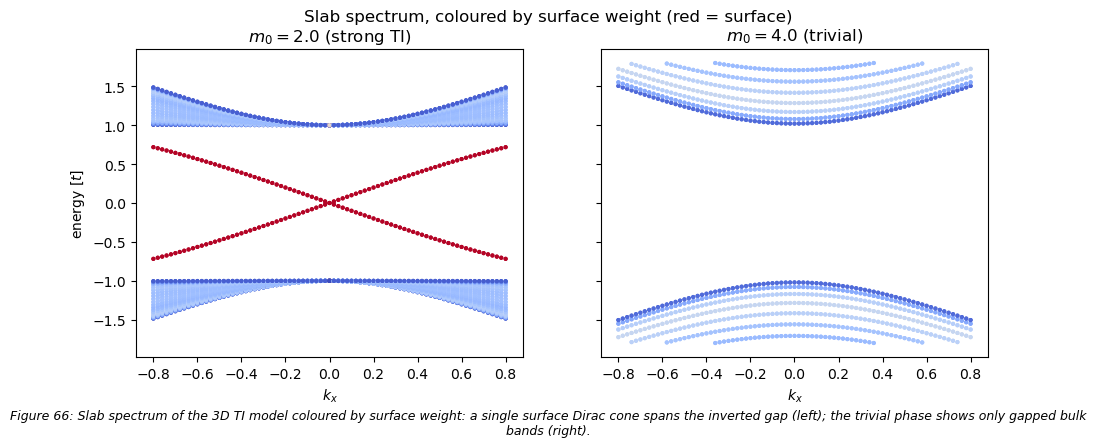

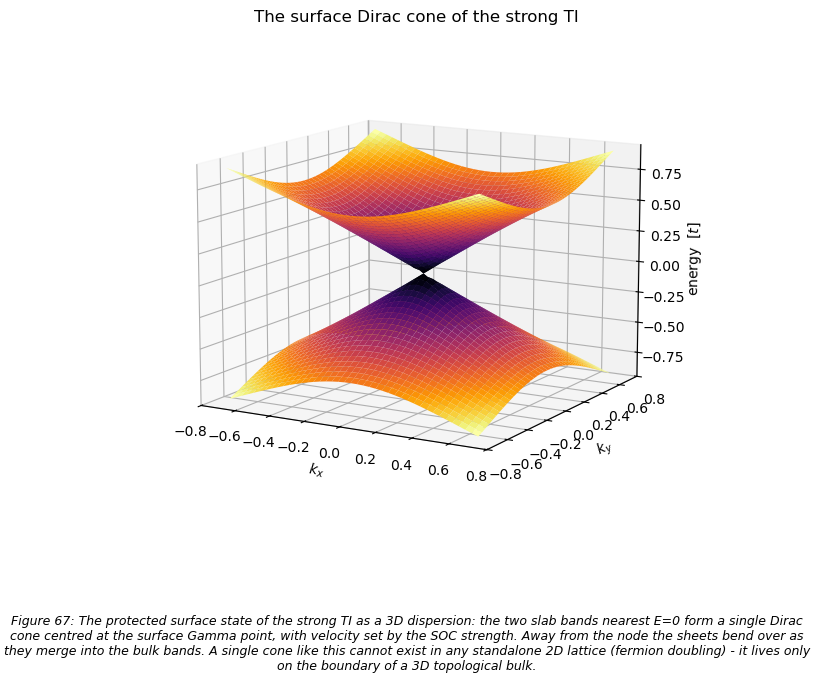

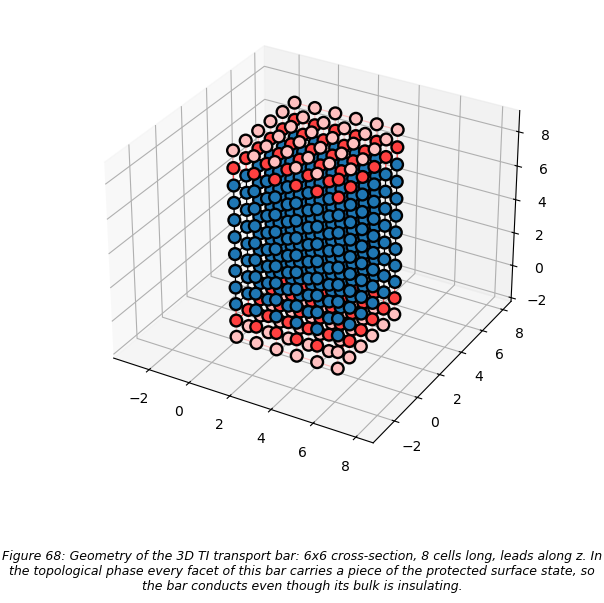

G(E=0.2) through a 3D bar:  TI = 2.000 e^2/h  (surface states);  trivial = 0.00e+00


In [53]:
# --- 3D TI: Fu-Kane parities, surface Dirac cone, surface transport -----------
import kwant, numpy as np
from itertools import product
from matplotlib import pyplot

s0 = np.eye(2)
sx = np.array([[0, 1], [1, 0]])
sy = np.array([[0, -1j], [1j, 0]])
sz = np.array([[1, 0], [0, -1]])
k4 = np.kron

t, lam = 1.0, 1.0
G0, Gx, Gy, Gz = k4(sz, s0), k4(sx, sx), k4(sx, sy), k4(sx, sz)

def h_ti(kx, ky, kz, m0):
    m = m0 - t * (np.cos(kx) + np.cos(ky) + np.cos(kz))
    return m * G0 + lam * (np.sin(kx) * Gx + np.sin(ky) * Gy + np.sin(kz) * Gz)

def fu_kane_nu0(m0):
    prod_par = 1.0
    for trim in product((0.0, np.pi), repeat=3):
        h = h_ti(*trim, m0)
        occ = np.linalg.eigh(h)[1][:, :2]
        par = np.linalg.eigvalsh(occ.conj().T @ G0 @ occ)   # inversion op = G0
        prod_par *= par[0]              # one representative per Kramers pair
    return 0 if prod_par > 0 else 1

for m0 in (2.0, 4.0):
    print(f"m0 = {m0}:  Fu-Kane nu0 = {fu_kane_nu0(m0)}"
          + ("   (strong TI)" if fu_kane_nu0(m0) else "   (trivial)"))

# slab: the surface Dirac cone, coloured by where the state lives
Nz = 20
hop_z = -t * G0 / 2 + lam * Gz / (2j)

def slab_h(kx, ky, m0):
    on = ((m0 - t * np.cos(kx) - t * np.cos(ky)) * G0
          + lam * (np.sin(kx) * Gx + np.sin(ky) * Gy))
    H = np.zeros((4 * Nz, 4 * Nz), dtype=complex)
    for z in range(Nz):
        H[4*z:4*z+4, 4*z:4*z+4] = on
        if z + 1 < Nz:
            H[4*z:4*z+4, 4*z+4:4*z+8] = hop_z
            H[4*z+4:4*z+8, 4*z:4*z+4] = hop_z.conj().T
    return H

kxs = np.linspace(-0.8, 0.8, 81)
fig, axes = pyplot.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, m0, label in zip(axes, (2.0, 4.0), ("strong TI", "trivial")):
    for kx in kxs:
        ev, vec = np.linalg.eigh(slab_h(kx, 0, m0))
        sel = np.abs(ev) < 1.8            # wide enough to show bulk bands
        surf = (np.abs(vec[:, sel]) ** 2).reshape(Nz, 4, -1).sum(axis=1)
        w = surf[:3].sum(axis=0) + surf[-3:].sum(axis=0)
        ax.scatter([kx] * sel.sum(), ev[sel], c=w, s=4, cmap='coolwarm',
                   vmin=0, vmax=1)
    ax.set_title(f"$m_0 = {m0}$ ({label})"); ax.set_xlabel(r"$k_x$")
axes[0].set_ylabel("energy $[t]$")
fig.suptitle("Slab spectrum, coloured by surface weight (red = surface)")
show_fig(r'Slab spectrum of the 3D TI model coloured by surface weight: a single surface Dirac cone spans the inverted gap (left); the trivial phase shows only gapped bulk bands (right).')

# the surface Dirac cone itself, rendered in 3D: for each (kx, ky) take the
# two slab states closest to E = 0 (the upper and lower halves of the cone)
kr = np.linspace(-0.7, 0.7, 41)
KX, KY = np.meshgrid(kr, kr)
E_up = np.zeros_like(KX)
E_dn = np.zeros_like(KX)
for i in range(len(kr)):
    for j in range(len(kr)):
        ev_k = np.linalg.eigvalsh(slab_h(KX[i, j], KY[i, j], 2.0))
        E_up[i, j] = ev_k[ev_k > 0].min()
        E_dn[i, j] = ev_k[ev_k < 0].max()

fig = pyplot.figure(figsize=(8, 6.5))
ax = fig.add_subplot(projection='3d')
ax.plot_surface(KX, KY, E_up, cmap='inferno', linewidth=0, antialiased=True)
ax.plot_surface(KX, KY, E_dn, cmap='inferno_r', linewidth=0, antialiased=True)
ax.set_xlabel(r'$k_x$')
ax.set_ylabel(r'$k_y$')
ax.set_zlabel('energy  $[t]$')
ax.set_title('The surface Dirac cone of the strong TI')
ax.view_init(elev=12, azim=-60)
show_fig(r'The protected surface state of the strong TI as a 3D dispersion: the two slab bands nearest E=0 form a single Dirac cone centred at the surface Gamma point, with velocity set by the SOC strength. Away from the node the sheets bend over as they merge into the bulk bands. A single cone like this cannot exist in any standalone 2D lattice (fermion doubling) - it lives only on the boundary of a 3D topological bulk.')

# transport: in-gap conductance carried by the surface, zero when trivial
lat3 = kwant.lattice.cubic(norbs=4)
hops = {(1, 0, 0): -t * G0 / 2 + lam * Gx / (2j),
        (0, 1, 0): -t * G0 / 2 + lam * Gy / (2j),
        (0, 0, 1): hop_z}

def ti_bar(m0, W=6, L=8):
    def fill(syst, rng):
        syst[(lat3(x, y, z) for x in range(W) for y in range(W) for z in rng)] \
            = m0 * G0
        for d, v in hops.items():
            syst[kwant.builder.HoppingKind(d, lat3, lat3)] = v
    syst = kwant.Builder()
    fill(syst, range(L))
    lead = kwant.Builder(kwant.TranslationalSymmetry((0, 0, -1)))
    fill(lead, [0])
    syst.attach_lead(lead)
    syst.attach_lead(lead.reversed())
    return syst.finalized()

E = 0.2                                      # inside the bulk gap
fbar = ti_bar(2.0)
kwant.plot(fbar, site_size=0.25, hop_lw=0.05, fig_size=(6, 6), show=False)
show_fig(r'Geometry of the 3D TI transport bar: 6x6 cross-section, 8 cells long, leads along z. In the topological phase every facet of this bar carries a piece of the protected surface state, so the bar conducts even though its bulk is insulating.')
G_top = kwant.smatrix(fbar, E).transmission(1, 0)
G_tri = kwant.smatrix(ti_bar(4.0), E).transmission(1, 0)
print(f"G(E={E}) through a 3D bar:  TI = {G_top:.3f} e^2/h  "
      f"(surface states);  trivial = {G_tri:.2e}")
assert G_top > 1.0 and G_tri < 1e-6

---
## Exercises for Part II

Solutions in **`Kwant_Exercises_Solutions.ipynb`**.

**E2.1** ◦ *(after Asbóth, Oroszlány & Pályi, ch. 1)* — An SSH chain with an
*odd* number of sites hosts exactly one zero mode for any $t_1, t_2$.
Verify numerically, and determine on which sublattice it lives depending on
$t_1 \lessgtr t_2$.

**E2.2** • *(after Jackiw-Rebbi; Asbóth ch. 1)* — Build an SSH chain with a
domain wall in the middle ($t_1<t_2$ on the left, $t_1>t_2$ on the right).
Show a zero mode binds to the wall, plot it, and check its sublattice
polarisation.

**E2.3** ★ *(inspired by topocondmat.org, week 1)* — Add a next-nearest-
neighbour hopping $t'\,\tau_z$ to the Kitaev chain.  For large enough $t'$
the invariant (class BDI winding number) reaches $W=2$: two Majorana modes
per end.  Find such a parameter point numerically and show the doubled zero
modes survive chemical-potential disorder but not... which perturbation?

**E2.4** ◦ *(after topocondmat.org, week 2)* — Plot the height of the
nanowire zero-bias peak at fixed $B > B_c$ as a function of wire length and
show it approaches $2e^2/h$ exponentially (Majorana splitting).

**E2.5** ◦ *(original)* — Reverse the direction of the Rice-Mele pump cycle
and recompute the Chern number over $(k,\varphi)$; then deform the cycle so
it no longer encircles the origin and watch $C$ drop to zero.

**E2.6** ◦ *(original)* — Recompute the Haldane phase diagram at
$t_2 = 0.05$ and verify the lobe boundary rescales exactly as
$3\sqrt{3}\,t_2\sin\phi$.

**E2.7** • *(after topocondmat.org, week 4)* — Build a Haldane ribbon with
*armchair* edges and show the chiral edge mode still crosses the gap:
bulk-boundary correspondence does not care about the termination.

**E2.8** • *(after Kane & Mele, PRL 95, 226801 (2005))* — Sweep the
staggered mass $M$ in the Kane-Mele bar and locate the value where the
edge conductance $G=2e^2/h$ collapses; compare with the spin-Chern
transition at $M = 3\sqrt{3}\lambda_{SO}$.

**E2.9** ★ *(after Read & Green, PRB 61, 10267 (2000))* — Put a vortex in
the p+ip order parameter: $\Delta(\mathbf r) = \Delta\,e^{i\theta(\mathbf
r)}$ on a disc (implement the phase on the bond pairing terms).  Find the
near-zero mode bound to the core and check the core-state/edge-state energy
splitting shrinks with disc radius.

**E2.10** ◦ *(after Benalcazar-Bernevig-Hughes, Science 357, 61 (2017))* —
Add a small onsite perturbation $+\epsilon$ on sublattices 1,2 and
$-\epsilon$ on 3,4 of the BBH flake, breaking the protecting mirror
symmetries; show the four corner modes split away from zero linearly.

**E2.11** • *(original)* — Sweep $m_0$ in the Weyl model and track the two
nodes: show they migrate to the BZ boundary $k_z=\pi$ as $m_0 \to 3t$,
annihilate there, and that beyond this the slice Chern number vanishes for
all $k_z$ (a trivial insulator; for $1<m_0/t<3$... what happens at the
other end?).

**E2.12** ★ *(after Fu & Kane, PRB 76, 045302 (2007))* — For $m_0 = 0.5$
(band inversions at more than one TRIM) compute all four $\mathbb{Z}_2$
indices $(\nu_0; \nu_1\nu_2\nu_3)$ from the parities and identify the weak
topological phase; verify with slab spectra in two different orientations.

**E2.13** • *(original; cf. thin-film Bi₂Se₃, Zhang et al., Nat. Phys. 6,
584 (2010))* — Plot the surface-state gap of the 3D TI slab at
$\bar\Gamma$ vs thickness $N_z$ and extract the surface-state penetration
depth from the exponential decay.

**E2.14** ◦ *(pencil, original)* — From particle-hole symmetry alone, show
that any BdG eigenstate at $+E$ has a partner at $-E$, and that a
*single* level pinned at $E=0$ cannot be moved without breaking the
symmetry — the algebraic heart of Majorana protection.

---
## 27. Where to go next

### The rest of the API

| Module | Purpose |
|---|---|
| `kwant.physics` | `Bands`, `modes`, `PropagatingModes`, `StabilizedModes`, `magnetic_gauge`, `two_terminal_shotnoise` |
| `kwant.rmt` | random-matrix ensembles for all ten symmetry classes |
| `kwant.digest` | reproducible pseudo-random on-site disorder keyed by site — the right way to do disorder averaging |
| `kwant.wraparound` | fold a translationally symmetric `Builder` into a Brillouin-zone-parameterised one; how you get bulk band structures |
| `kwant.qsymm` | find and impose symmetries of a model (interface to the `qsymm` package) |
| `kwant.linalg.lll` | lattice reduction, used internally for lead construction |

### Ecosystem

- **TKwant** — time-dependent quantum transport; the natural extension for pulses, AC drive
  and quenches (released 2020).
- **Adaptive** — adaptive sampling of expensive functions. Pairs extremely well with
  parameter sweeps: it puts points where the curve is interesting rather than on a grid.
- **Qsymm** — symmetry finding and $k\cdot p$ model generation.
- **semicon**, **kwantspectrum**, and other community extensions listed on the project site.

### Suggested exercises

1. Add Anderson disorder to the § 3 wire (`kwant.digest.uniform` keyed on `site.tag`) and
   watch the plateaus wash out. Average over disorder realisations; extract the localisation
   length from $\ln T$ vs $L$.
2. Make a four-terminal Hall bar; compute $R_{xx}$ and $R_{xy}$ versus field and find the
   quantum Hall plateaus.
3. Build the Kitaev chain / Rashba-nanowire-with-superconductivity model and locate the
   zero-bias conductance peak as a function of Zeeman field.
4. Take the § 13 BHZ ribbon, add a magnetic field, and follow the edge states through the
   topological transition.
5. Use KPM to compute the DOS of a $10^6$-site disordered graphene sheet — infeasible by
   diagonalisation, routine by KPM.

### Citing Kwant

> C. W. Groth, M. Wimmer, A. R. Akhmerov, X. Waintal,
> *Kwant: a software package for quantum transport*,
> **New Journal of Physics 16, 063065 (2014)**.
> [doi:10.1088/1367-2630/16/6/063065](https://doi.org/10.1088/1367-2630/16/6/063065) —
> open access, [arXiv:1309.2926](https://arxiv.org/abs/1309.2926).

Kwant is free software (BSD-2-Clause), developed at CEA Grenoble, TU Delft and elsewhere.

---

*Sources: this notebook was written against the Kwant 1.5 documentation mirrored in
`mirror/doc/` alongside it — tutorial sections 2.1–2.12, the `kwant.builder`,
`kwant.solvers`, `kwant.kpm`, `kwant.qsymm`, `kwant.system` and `kwant.physics` reference
pages, and the 1.5 release notes.*

### A topological-matter reference shelf

* **Foundations:** TKNN, PRL **49**, 405 (1982); Berry, Proc. R. Soc. A
  **392**, 45 (1984); Xiao, Chang & Niu, RMP **82**, 1959 (2010).
* **Reviews:** Hasan & Kane, RMP **82**, 3045 (2010); Qi & Zhang, RMP
  **83**, 1057 (2011); Chiu *et al.*, RMP **88**, 035005 (2016)
  (classification); Armitage *et al.*, RMP **90**, 015001 (2018)
  (semimetals); Sato & Ando, Rep. Prog. Phys. **80**, 076501 (2017)
  (superconductors); Xie *et al.*, Nat. Rev. Phys. **3**, 520 (2021)
  (higher-order).
* **Books:** Bernevig & Hughes, *Topological Insulators and Topological
  Superconductors* (Princeton, 2013); Asbóth, Oroszlány & Pályi, *A Short
  Course on Topological Insulators* (Springer, 2016); Vanderbilt, *Berry
  Phases in Electronic Structure Theory* (Cambridge, 2018).
* **Courses with code:** [topocondmat.org](https://topocondmat.org) (Kwant
  based, like this notebook); the
  [PythTB examples](https://www.physics.rutgers.edu/pythtb/examples.html).


---
## Sources, attribution and licence

This notebook and its companion `Kwant_Exercises_Solutions.ipynb` are released
under the **Apache License 2.0** (see `LICENSE` in the repository). The code, text,
figures and exercises are original unless an item says otherwise. Three
sources were used as models and are credited where they are used:

| Source | What was taken | Licence of the source |
|---|---|---|
| **Kwant documentation and tutorial**, C. W. Groth *et al.*, kwant-project.org/doc/1 | API conventions; exercises E1.1, E1.2, E1.4 are re-posed tutorial problems (marked *from the Kwant tutorial*) | BSD 2-clause (`LICENSE.rst` of the Kwant distribution) |
| **topocondmat.org** — *Topology in Condensed Matter: Tying Quantum Knots*, TU Delft (A. R. Akhmerov *et al.*) | the pedagogical route through Part II; exercises E2.3, E2.4, E2.7 are paraphrased (marked *after / inspired by topocondmat.org*); no text or code is reproduced verbatim | course text CC BY-SA 4.0, code BSD 3-clause |
| **A Short Course on Topological Insulators**, J. K. Asbóth, L. Oroszlány, A. Pályi (Springer 2016; arXiv:1509.02295) | the SSH/Kitaev presentation; exercises E2.1, E2.2 are paraphrased (marked *after Asbóth*) | book, © Springer; arXiv version CC BY 4.0 |

**How to cite this notebook.** See `CITATION.cff` in the repository.

`SPDX-License-Identifier: Apache-2.0` — Copyright 2026 Fabio Campolim.
